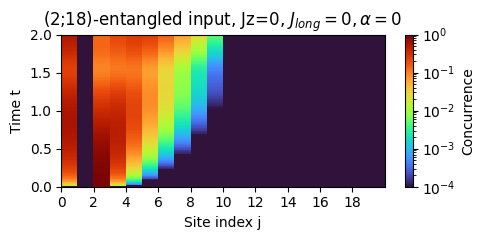

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def row_to_rho(row):
    # row layout: t, p, j, trace, [Re00, Im00, ..., Re33, Im33]
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    C = evals[0] - evals[1] - evals[2] - evals[3]
    return max(0, C)

# --------------------------------------------------
# Load the file
# --------------------------------------------------
configsArray=np.array([2])

for config in configsArray:
    base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"
    fname = f"{base}{config}Concurrence.txt"
    # Load numerically, not as strings
    data = np.loadtxt(fname)

    # --------------------------------------------------
    # Build concurrence matrix (time × site)
    # --------------------------------------------------
    p_target = 1
    ns = 20

    uniq_times = np.unique(data[:,0])
    Cmat = np.zeros((len(uniq_times), ns))
    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    # --------------------------------------------------
    # Restrict to times t <= 1
    # --------------------------------------------------
    t_max_plot = 1.0

    time_mask = uniq_times <= t_max_plot
    plot_times = uniq_times[time_mask]


    for row in data:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue

        rho = row_to_rho(row)
        C = concurrence(rho)
        Cmat[time_to_row[t], j] = C

    Cmat = Cmat[time_mask, :]
    Nmat = Nmat[time_mask, :]
    MImat = MImat[time_mask, :]

    corr_mask = times_corr <= t_max_plot
    CorrMat = CorrMat[corr_mask, :]

    # --------------------------------------------------
    # Plot heatmap
    # --------------------------------------------------
    # t_min, t_max = uniq_times.min(), uniq_times.max()
    t_min, t_max = plot_times.min(), plot_times.max()

    plt.figure(figsize=(5, 2.5))

    im = plt.imshow(
        np.clip(Cmat, 1e-12, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-4, vmax=np.nanmax(Cmat + 1e-12)),
        interpolation="nearest",
        extent=[0, ns, t_min, t_max],
        rasterized=True
    )


    plt.xticks([x for x in range(0,19,2)], [x for x in range(0,19,2)])
    plt.colorbar(im, label="Concurrence")
    plt.xlabel("Site index j")
    plt.ylabel("Time t")
    if config == 1:
        plt.title(fr"(2,18)-product input, Jz=0, $J_{{long}}=0, \alpha=0$ ")
    if config == 2:
        plt.title(fr"(2;18)-entangled input, Jz=0, $J_{{long}}=0, \alpha=0$ ")
    if config == 3:
        plt.title(fr"(2,18)-product input, Jz=1, $J_{{long}}=2, \alpha=0.5$ ")
    if config == 4:
        plt.title(fr"(2,18)-entangled input, Jz=1, $J_{{long}}=2, \alpha=0.5$ ")
    plt.tight_layout()

plt.show()


C:\Users\shrey\AppData\Local\Temp\ipykernel_10452\1377615113.py:372: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend(loc="upper left")
C:\Users\shrey\AppData\Local\Temp\ipykernel_10452\1377615113.py:373: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(loc="upper left")


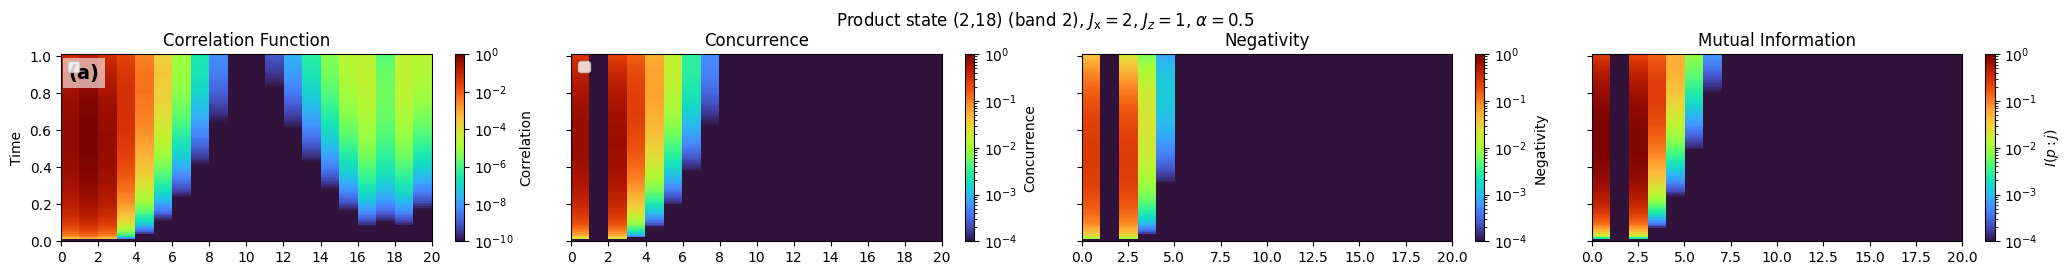

C:\Users\shrey\AppData\Local\Temp\ipykernel_10452\1377615113.py:372: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend(loc="upper left")
C:\Users\shrey\AppData\Local\Temp\ipykernel_10452\1377615113.py:373: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(loc="upper left")


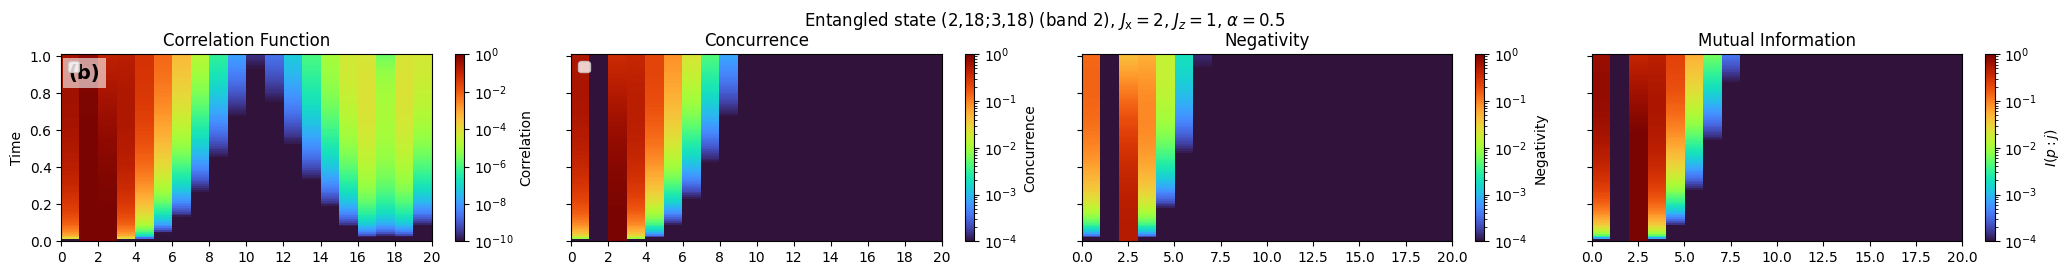

C:\Users\shrey\AppData\Local\Temp\ipykernel_10452\1377615113.py:372: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend(loc="upper left")
C:\Users\shrey\AppData\Local\Temp\ipykernel_10452\1377615113.py:373: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(loc="upper left")


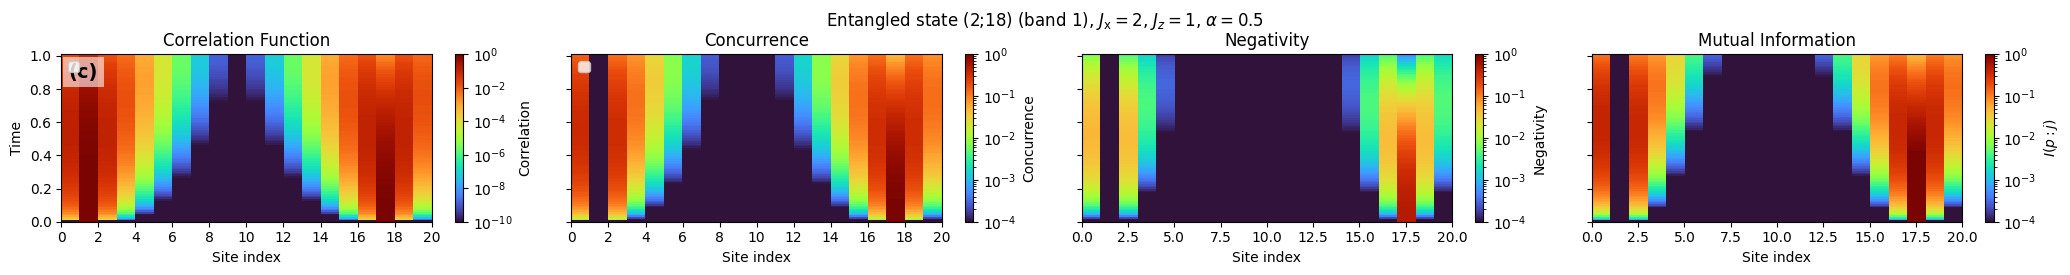

C:\Users\shrey\AppData\Local\Temp\ipykernel_10452\1377615113.py:372: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend(loc="upper left")
C:\Users\shrey\AppData\Local\Temp\ipykernel_10452\1377615113.py:373: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(loc="upper left")


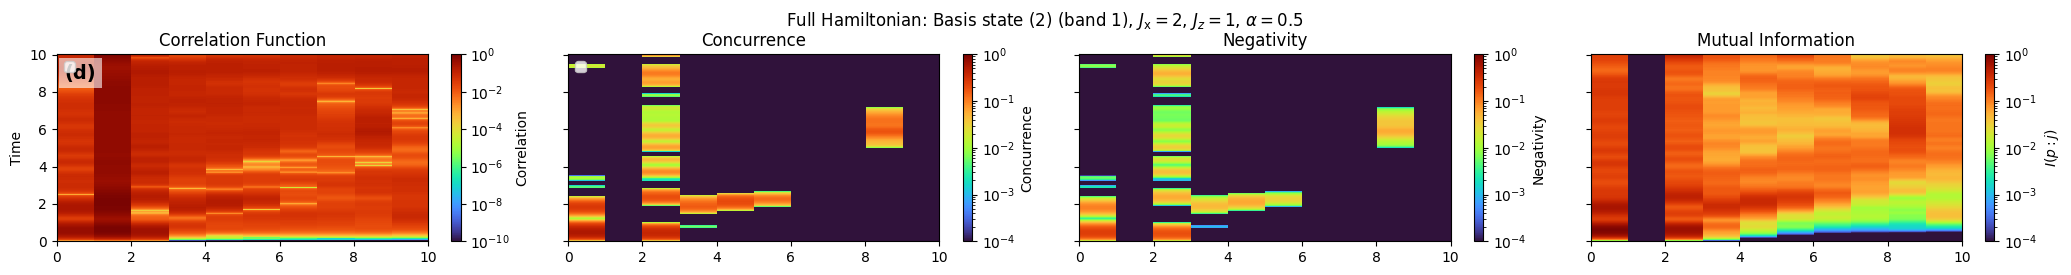

C:\Users\shrey\AppData\Local\Temp\ipykernel_10452\1377615113.py:372: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend(loc="upper left")
C:\Users\shrey\AppData\Local\Temp\ipykernel_10452\1377615113.py:373: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(loc="upper left")


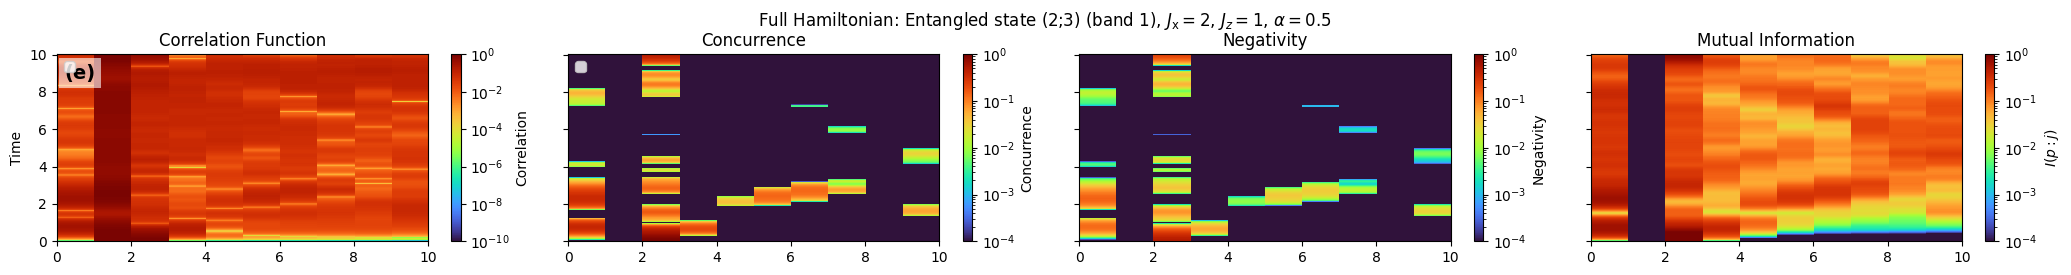

C:\Users\shrey\AppData\Local\Temp\ipykernel_10452\1377615113.py:372: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend(loc="upper left")
C:\Users\shrey\AppData\Local\Temp\ipykernel_10452\1377615113.py:373: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(loc="upper left")


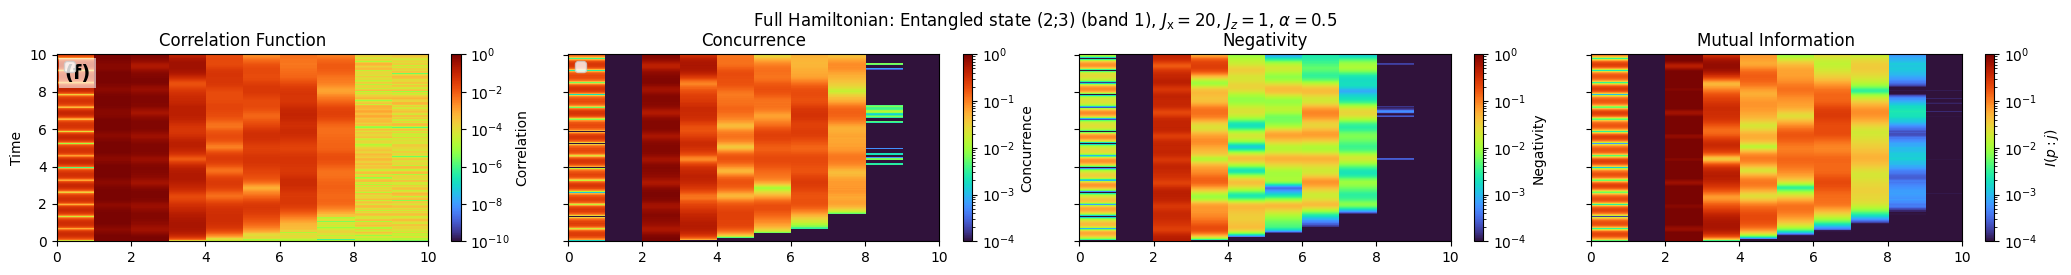

C:\Users\shrey\AppData\Local\Temp\ipykernel_10452\1377615113.py:372: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend(loc="upper left")
C:\Users\shrey\AppData\Local\Temp\ipykernel_10452\1377615113.py:373: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(loc="upper left")


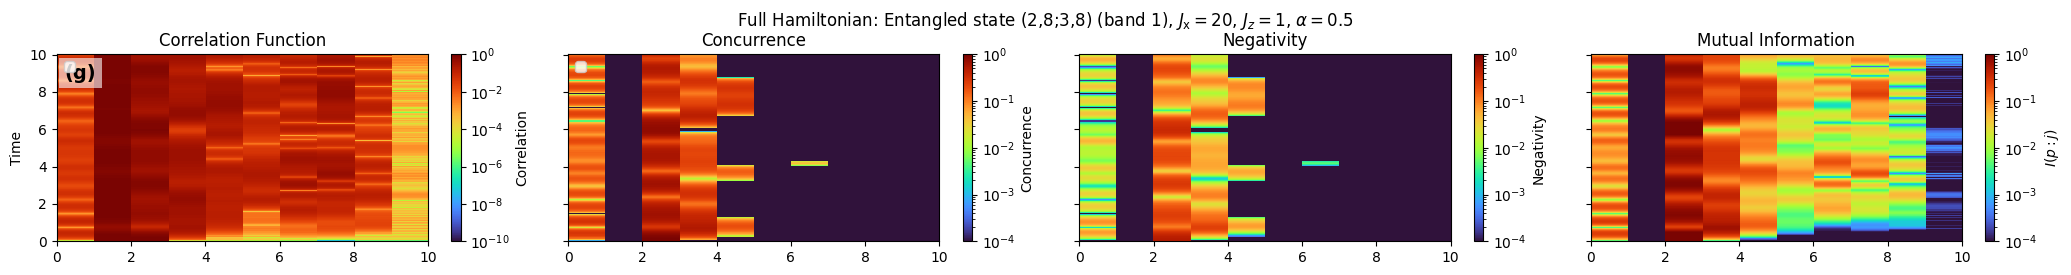

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1] #sorted in decreasing order
    C = evals[0] - evals[1] - evals[2] - evals[3]
    return max(0, C)#evals[1], evals[2], evals[3]

# --------------------------------------------------
# Negativity computation (two qubits)
# --------------------------------------------------
def negativity(rho):
    """
    Negativity = sum of absolute values of negative eigenvalues
    of the partial transpose
    """
    # partial transpose w.r.t. second qubit
    rho_pt = rho.reshape(2,2,2,2).transpose(0,3,2,1).reshape(4,4)
    evals = np.linalg.eigvals(rho_pt)
    return np.sum(np.abs(evals[evals < 0]))

# --------------------------------------------------
# Von Neumann entropy
# --------------------------------------------------
def von_neumann_entropy(rho, eps=1e-12):
    evals = np.linalg.eigvalsh(rho)
    evals = np.clip(evals, eps, None)
    return -np.sum(evals * np.log2(evals))


# --------------------------------------------------
# Mutual information I(A:B)
# --------------------------------------------------
def mutual_information(rho):
    """
    rho : 4x4 density matrix of two qubits
    """
    rho = rho / np.trace(rho)

    # reduced density matrices
    rhoA = np.trace(rho.reshape(2,2,2,2), axis1=1, axis2=3)
    rhoB = np.trace(rho.reshape(2,2,2,2), axis1=0, axis2=2)

    return (
        von_neumann_entropy(rhoA)
        + von_neumann_entropy(rhoB)
        - von_neumann_entropy(rho)
    )


# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
configsArray = [3,4,5,10,11,12,13] #0,6,1,2,
ns = 20
p_target = 1

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"
for config in configsArray:
    fnameC = f"{base}{config}Concurrence.txt"
    fnameCorr = f"{base}{config}CorrelationFunction.txt"
    if config>=10: #full hamiltonian cases
        ns=10

    # --------------------------------------------------
    # LOAD FILES
    # --------------------------------------------------
    dataC = np.loadtxt(fnameC)
    dataCorr = np.loadtxt(fnameCorr)

    # correlation file: (N_times × (ns+1))
    times_corr = dataCorr[:,0]
    CorrMat = np.abs(dataCorr[:,1:ns+1])   # shape = (time, sites)

    # --------------------------------------------------
    # Build concurrence matrix
    # --------------------------------------------------
    uniq_times = np.unique(dataC[:,0])
    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    Cmat = np.zeros((len(uniq_times), ns))

    for row in dataC:
        t = row[0]
        j = int(row[2])
        p = int(row[1])
        if p != p_target:
            continue

        rho = row_to_rho(row)
        Cmat[time_to_row[t], j] = concurrence(rho)

    # --------------------------------------------------
    # Build negativity matrix
    # --------------------------------------------------
    Nmat = np.zeros((len(uniq_times), ns))

    for row in dataC:
        t = row[0]
        j = int(row[2])
        p = int(row[1])
        if p != p_target:
            continue

        rho = row_to_rho(row)
        Nmat[time_to_row[t], j] = negativity(rho)

    # --------------------------------------------------
    # Build mutual information matrix
    # --------------------------------------------------
    MImat = np.zeros((len(uniq_times), ns))

    for row in dataC:
        t = row[0]
        j = int(row[2])
        p = int(row[1])
        if p != p_target:
            continue

        rho = row_to_rho(row)
        MImat[time_to_row[t], j] = mutual_information(rho)

    # --------------------------------------------------
    # PLOT SIDE BY SIDE
    # --------------------------------------------------
    t_min, t_max = uniq_times.min(), uniq_times.max()

    label_dict = {j: f"({chr(96 + i)})" for i, j in enumerate(configsArray, start=1)}
    label = label_dict.get(config, "(?)")

    

    fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)


    # -------- Left: correlation --------
    

    im1 = ax[0].imshow(
        np.clip(CorrMat, 1e-10, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=1e-10, vmax=1),#np.nanmax(CorrMat+1e-12)),
        extent=[0, ns, t_min, t_max]
    )

    

    ax[0].set_title("Correlation Function")
    if config==5:
        ax[0].set_xlabel("Site index")
    ax[0].set_ylabel("Time")
    tick_positions = list(range(0, ns+1, 2))
    tick_labels    = tick_positions

    ax[0].set_xticks(tick_positions)
    ax[0].set_xticklabels(tick_labels)

    ax[1].set_xticks(tick_positions)
    ax[1].set_xticklabels(tick_labels)

    plt.colorbar(im1, ax=ax[0], label="Correlation")

    # -------- Right: concurrence --------
    im2 = ax[1].imshow(
        np.clip(Cmat, 1e-10, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=1e-4, vmax=1),
        extent=[0, ns, t_min, t_max]
    )
    ax[1].set_title("Concurrence")
    if config==5:
        ax[1].set_xlabel("Site index")
    plt.colorbar(im2, ax=ax[1], label="Concurrence")
    
        # -------- Third: negativity --------
    im3 = ax[2].imshow(
        np.clip(Nmat, 1e-10, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=1e-4, vmax=1),
        extent=[0, ns, t_min, t_max]
    )

    # -------- Fourth: mutual information --------
    im4 = ax[3].imshow(
        np.clip(MImat, 1e-10, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=1e-4, vmax=1),
        extent=[0, ns, t_min, t_max]
    )

    ax[3].set_title("Mutual Information")
    if config == 5:
        ax[3].set_xlabel("Site index")

    plt.colorbar(im4, ax=ax[3], label=r"$I(p:j)$")

    ax[2].set_title("Negativity")
    if config == 5:
        ax[2].set_xlabel("Site index")

    plt.colorbar(im3, ax=ax[2], label="Negativity")

    # --------------------------------------------------
    # SUPTITLES FOR EACH CONFIG (0–6)
    # --------------------------------------------------


    if config == 0:
        plt.suptitle(
            r"Product state (2,18) (band 2), $J_{\text{x}}=0$, $J_z=0$, $\alpha=0$",
            y=0.90
        )
    if config == 6:
        plt.suptitle(
            r"Entangled state (2;18) (band 1), $J_{\text{x}}=0$, $J_z=0$, $\alpha=0$",
            y=0.90
        )
    if config == 1:
        plt.suptitle(
            r"Entangled state (2,18;3,18) (band 2, site 18 is separable), $J_{\text{x}}=0$, $J_z=0$, $\alpha=0$",
            y=0.90
        )
    if config == 7:
        plt.suptitle(
            r"Entangled state (2,18;3,18) (band 2, site 18 is separable), $J_{\text{x}}=0$, $J_z=0$, $\alpha=0.5$",
            y=0.90
        )
    if config == 2:
        plt.suptitle(
            r"Product state (2,18) (band 2), $J_{\text{x}}=2$, $J_z=1$, $\alpha=0$",
            y=0.90
        )
    if config == 3:
        plt.suptitle(
            r"Product state (2,18) (band 2), $J_{\text{x}}=2$, $J_z=1$, $\alpha=0.5$",
            y=0.90
        )
    if config == 4:
        plt.suptitle(
            r"Entangled state (2,18;3,18) (band 2), $J_{\text{x}}=2$, $J_z=1$, $\alpha=0.5$",
            y=0.90
        )
    if config == 5:
        plt.suptitle(
            r"Entangled state (2;18) (band 1), $J_{\text{x}}=2$, $J_z=1$, $\alpha=0.5$",
            y=0.90
        )
    if config == 10:
        plt.suptitle(
            r"Full Hamiltonian: Basis state (2) (band 1), $J_{\text{x}}=2$, $J_z=1$, $\alpha=0.5$",
            y=0.90
        )
    if config == 11:
        plt.suptitle(
            r"Full Hamiltonian: Entangled state (2;3) (band 1), $J_{\text{x}}=2$, $J_z=1$, $\alpha=0.5$",
            y=0.90
        )
    if config == 12:
        plt.suptitle(
            r"Full Hamiltonian: Entangled state (2;3) (band 1), $J_{\text{x}}=20$, $J_z=1$, $\alpha=0.5$",
            y=0.90
        )
    if config == 13:
        plt.suptitle(
            r"Full Hamiltonian: Entangled state (2,8;3,8) (band 1), $J_{\text{x}}=20$, $J_z=1$, $\alpha=0.5$",
            y=0.90
        )

    ax[0].text(
    0.02, 0.95, label,
    transform=ax[0].transAxes,
    fontsize=14, fontweight="bold",
    va="top", ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )
    # --------------------------------------------------
    # VELOCITY EXTRACTION WITH CUSTOM FIT RANGE
    # --------------------------------------------------
    threshold = 0.01

    # -------- FIT RANGE (CHANGE THESE) --------
    fit_start = 2          # starting site index for fit (exclude site 0–1 noise)
    fit_end   = ns // 2    # stop at halfway to avoid right-cone
    # -------------------------------------------

    def extract_velocity(M, times, start_site, end_site, axis, color='w'):
        """
        Extract first-arrival velocity from matrix M over a custom site range.
        M : matrix (time × site)
        times : uniq_times
        start_site, end_site : inclusive site window for fitting
        axis : matplotlib axis to draw on
        color : plotting color
        """

        arrival_sites = []
        arrival_times = []

        for site in range(start_site, end_site):
            signal = M[:, site]

            above = np.where(signal >= threshold)[0]
            if len(above) == 0:
                continue

            t_first = times[above[0]]
            arrival_sites.append(site)
            arrival_times.append(t_first)

        if len(arrival_sites) < 2:
            print(f"Not enough arrivals in range [{start_site},{end_site}) for fit.")
            return None

        arrival_sites = np.array(arrival_sites)
        arrival_times = np.array(arrival_times)

        # Linear fit t = slope x + intercept → v = 1/slope
        slope, intercept = np.polyfit(arrival_sites, arrival_times, 1)
        velocity = 1.0 / slope

        # # Plot arrival points
        # axis.plot(arrival_sites, arrival_times, f'{color}o',
        #         markersize=4, label=f"First arrivals [{start_site},{end_site})")

        # # Plot fit line
        # x_fit = np.linspace(start_site, 4, 200)
        # t_fit = slope * x_fit + intercept
        # axis.plot(x_fit, t_fit, f'k--', linewidth=2,
        #         label=f"v = {velocity:.2f}")

        return velocity


    # ---- Extract velocities for both panels ----
    v_corr = extract_velocity(CorrMat, uniq_times, fit_start, fit_end, ax[0], color='w')
    v_conc = extract_velocity(Cmat, uniq_times, fit_start, fit_end, ax[1], color='w')

    # print("\n=== VELOCITY RESULTS ===")
    # # print(f"Correlation velocity (sites {fit_start}–{fit_end}) : {v_corr}")
    # print(f"Concurrence velocity (sites {fit_start}–{fit_end})  : {v_conc}")
    # print("==========================================\n")

    ax[0].legend(loc="upper left")
    ax[1].legend(loc="upper left")



    plt.tight_layout()
    plt.savefig(f"plt/Concurrence_Corr_Config{config}.svg", dpi=600)
    plt.show()


In [2]:
# --------------------------------------------------
# Save ρ_{2,j} at t = 0.5 to a TXT file (first config)
# --------------------------------------------------

target_time = 0
p_target = 1
tol = 1e-8

config = configsArray[0]  # first row / first config
fnameC = f"{base}{config}Concurrence.txt"

dataC = np.loadtxt(fnameC)

output_file = f"rho_2j_t{target_time}_config{config}.txt"

with open(output_file, "w") as f:
    f.write(f"# Density matrices rho_(2,j) at t = {target_time}\n")
    f.write(f"# Config = {config}\n")
    f.write("# Format: real + i*imag (row-wise)\n\n")

    for row in dataC:
        t = row[0]
        p = int(row[1])
        j = int(row[2])

        if p != p_target:
            continue
        if abs(t - target_time) > tol:
            continue

        rho = row_to_rho(row)

        f.write(f"j = {j+1}\n")
        for a in range(4):
            for b in range(4):
                val = rho[a, b]
                f.write(f"{val.real:.12e} {val.imag:.12e}  ")
            f.write("\n")
        f.write("\n")

print(f"Saved density matrices to: {output_file}")


NameError: name 'configsArray' is not defined

In [3]:
import numpy as np

target_time = 0.5
p_target = 1
tol = 1e-8

config = configsArray[0]
fnameC = f"{base}{config}Concurrence.txt"

dataC = np.loadtxt(fnameC)

# store (j, concurrence)
vals = []

for row in dataC:
    t = row[0]
    p = int(row[1])
    j = int(row[2])

    if p != p_target:
        continue
    if abs(t - target_time) > tol:
        continue

    rho = row_to_rho(row)
    C = concurrence(rho)
    vals.append((j, C))

# sort by site index
vals.sort(key=lambda x: x[0])

# save + print
outC = f"concurrence_2j_t{target_time}_config{config}.txt"
np.savetxt(outC, np.array(vals), fmt=["%d", "%.12e"], header="j  concurrence", comments="")

print(f"Saved concurrence to: {outC}")
print("First few (j, C):")
print(vals[:])


Saved concurrence to: concurrence_2j_t0.5_config3.txt
First few (j, C):
[(0, np.float64(0.6994257649558131)), (2, np.float64(0.6715120129631181)), (3, np.float64(0.1752169649451451)), (4, np.float64(0.029822324602957733)), (5, np.float64(0.003775082216297886)), (6, np.float64(0.0003807291213867749)), (7, np.float64(3.1923514842802036e-05)), (8, np.float64(2.2858843101373456e-06)), (9, np.float64(5.094028992559239e-08)), (10, 0), (11, 0), (12, 0), (13, 0), (14, 0), (15, 0), (16, 0), (17, 0), (18, 0), (19, 0)]


unique p in file: [1]
Requested t=0.2, using t=0.2000000000000592
Requested t=0.4, using t=0.4000000000002593
Requested t=0.5, using t=0.5000000000003593
Requested t=0.6, using t=0.5999999999999042
Requested t=0.8, using t=0.799999999998994


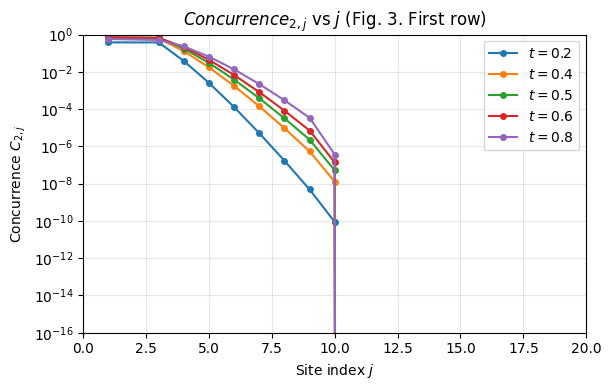

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# helpers
# -----------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    w = np.real(np.linalg.eigvals(R))
    w = np.clip(w, 0, None)
    lam = np.sort(np.sqrt(w))[::-1]
    return max(0.0, lam[0] - lam[1] - lam[2] - lam[3])

# -----------------------------
# SETTINGS
# -----------------------------
config = 3
p_target = 1                # reference site (C_{2,j})
times_to_plot = [0.2, 0.4, 0.5, 0.6, 0.8]   # multiple times
tol = 1e-16

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"
fnameC = f"{base}{config}Concurrence.txt"

# -----------------------------
# LOAD DATA
# -----------------------------
dataC = np.loadtxt(fnameC)

# sanity check
print("unique p in file:", np.unique(dataC[:,1].astype(int)))

rows_p = dataC[dataC[:,1].astype(int) == p_target]
if rows_p.size == 0:
    raise RuntimeError("No rows with p_target =", p_target)

# available times
all_times = np.unique(rows_p[:,0])

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(6,4))

for t_query in times_to_plot:
    # pick nearest available time
    t_used = all_times[np.argmin(np.abs(all_times - t_query))]
    print(f"Requested t={t_query}, using t={t_used}")

    # print(f"\nConcurrence values for t = {t_used}")
    # print(" j   C_{2,j}")
    # print("------------------------")
    # for (j, C) in vals:
    #     print(f"{j+1:2d}  {C:.3e}")

    vals = []
    for row in rows_p:
        if abs(row[0] - t_used) > tol:
            continue
        j = int(row[2])
        rho = row_to_rho(row)
        C = concurrence(rho)
        C_plot = max(C, 0)   # numerical floor for log scale
        vals.append((j, C_plot))


    if len(vals) == 0:
        continue

    vals.sort(key=lambda x: x[0])
    vals = np.array(vals)

    plt.semilogy(
        vals[:,0] + 1, vals[:,1],   # <-- shift j → j+1
        "o-", lw=1.5, ms=4,
        label=rf"$t = {t_used:.1f}$"
    )


plt.xlabel("Site index $j$")
plt.ylabel(r"Concurrence $C_{2,j}$")
plt.title(rf"$Concurrence_{{2,j}}$ vs $j$ (Fig. 3. First row)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.xlim(0, 20)
plt.ylim(1e-16, 1)
plt.show()


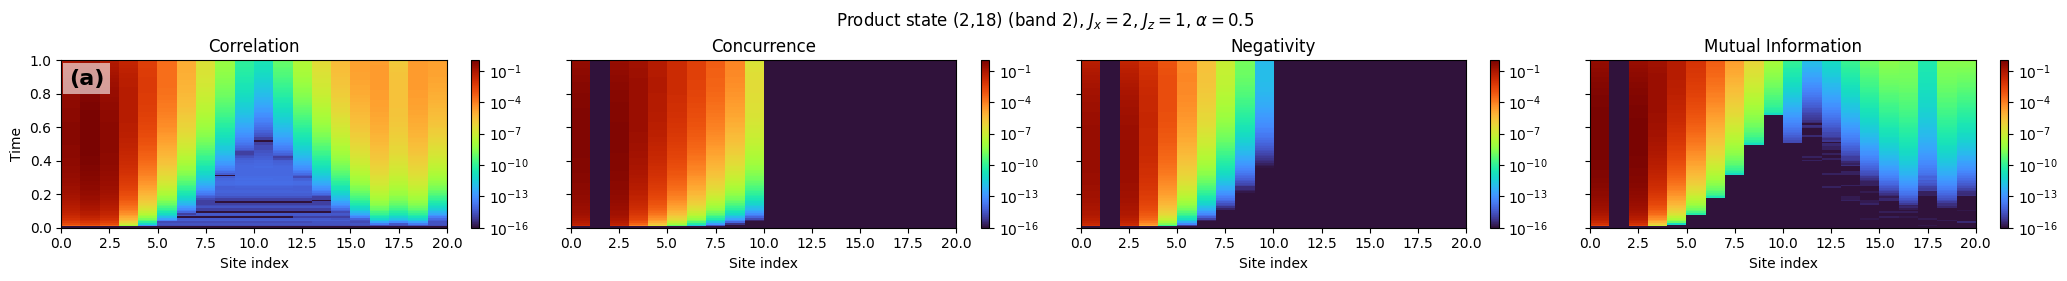

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    return max(0, evals[0] - evals[1] - evals[2] - evals[3])

# --------------------------------------------------
# Negativity computation
# --------------------------------------------------
def negativity(rho):
    # original indices: (iA, iB, jA, jB)
    #(0,1,2,3)
    rho_pt = rho.reshape(2,2,2,2).transpose(0,3,2,1).reshape(4,4)
    # indices: (iA, jB, jA, iB)
    #(0,3,2,1)
    # evals = np.linalg.eigvals(rho_pt)
    # return np.sum(np.abs(evals[evals < 0]))
    evals = np.linalg.eigvalsh(rho_pt)  # Hermitian solver
    return -np.sum(evals[evals < 0])


# --------------------------------------------------
# Von Neumann entropy
# --------------------------------------------------
def von_neumann_entropy(rho, eps=1e-12):
    evals = np.linalg.eigvalsh(rho)
    evals = np.clip(evals, eps, None)
    return -np.sum(evals * np.log2(evals))

# --------------------------------------------------
# Mutual information
# --------------------------------------------------
def mutual_information(rho):
    rho = rho / np.trace(rho)
    rhoA = np.trace(rho.reshape(2,2,2,2), axis1=1, axis2=3)
    rhoB = np.trace(rho.reshape(2,2,2,2), axis1=0, axis2=2)
    return (
        von_neumann_entropy(rhoA)
        + von_neumann_entropy(rhoB)
        - von_neumann_entropy(rho)
    )

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
configsArray = [3]
p_target = 1
t_max_plot = 1.0

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"

# panel letters: (a), (b), (c), ...
panel_letters = [f"({chr(97+i)})" for i in range(len(configsArray))]

for idx, config in enumerate(configsArray):

    ns = 10 if config >= 10 else 20

    fnameC    = f"{base}{config}Concurrence.txt"
    fnameCorr = f"{base}{config}CorrelationFunction.txt"

    dataC    = np.loadtxt(fnameC)
    dataCorr = np.loadtxt(fnameCorr)

    # --------------------------------------------------
    # Correlation data
    # --------------------------------------------------
    times_corr = dataCorr[:,0]
    CorrMat = np.abs(dataCorr[:,1:ns+1])

    # --------------------------------------------------
    # Time axis (MASTER)
    # --------------------------------------------------
    uniq_times = np.unique(dataC[:,0])
    time_mask  = uniq_times <= t_max_plot
    plot_times = uniq_times[time_mask]
    t_min, t_max = plot_times.min(), plot_times.max()

    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    # --------------------------------------------------
    # Allocate matrices
    # --------------------------------------------------
    Cmat  = np.zeros((len(uniq_times), ns))
    Nmat  = np.zeros((len(uniq_times), ns))
    MImat = np.zeros((len(uniq_times), ns))

    # --------------------------------------------------
    # Fill matrices
    # --------------------------------------------------
    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)

        Cmat[k, j]  = concurrence(rho)
        Nmat[k, j]  = negativity(rho)
        MImat[k, j] = mutual_information(rho)

    # --------------------------------------------------
    # Apply SAME time cut to ALL matrices
    # --------------------------------------------------
    Cmat  = Cmat[time_mask, :]
    Nmat  = Nmat[time_mask, :]
    MImat = MImat[time_mask, :]

    corr_mask = times_corr <= t_max_plot
    CorrMat   = CorrMat[corr_mask, :]

    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------
    fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)
    extent = [0, ns, t_min, t_max]

    im1 = ax[0].imshow(np.clip(CorrMat,1e-16,None), origin="lower",
                       aspect="auto", cmap="turbo", interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-16, vmax=1),
                       extent=extent)

    im2 = ax[1].imshow(np.clip(Cmat,1e-16,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-16, vmax=1),
                       extent=extent)

    im3 = ax[2].imshow(np.clip(Nmat,1e-16,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-16, vmax=1),
                       extent=extent)

    im4 = ax[3].imshow(np.clip(MImat,1e-16,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-16, vmax=1),
                       extent=extent)

    ax[0].set_title("Correlation")
    ax[1].set_title("Concurrence")
    ax[2].set_title("Negativity")
    ax[3].set_title("Mutual Information")

    ax[0].set_ylabel("Time")
    for a in ax:
        a.set_xlabel("Site index")

    # --------------------------------------------------
    # SINGLE panel letter for the entire row
    # --------------------------------------------------
    ax[0].text(
        0.02, 0.95, panel_letters[idx],   # 👈 INSIDE the plot
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )


    for im, a in zip([im1, im2, im3, im4], ax):
        plt.colorbar(im, ax=a)

    # --------------------------------------------------
    # Suptitles (unchanged)
    # --------------------------------------------------
    if config == 3:
        plt.suptitle(r"Product state (2,18) (band 2), $J_x=2$, $J_z=1$, $\alpha=0.5$", y=0.92)

    plt.tight_layout()
    plt.savefig(f"plt/Concurrence_Corr_Config{config}.svg", dpi=600)
    plt.show()


In [16]:
print(Cmat[int(time/tInterval)])

[6.99425765e-01 0.00000000e+00 6.71512013e-01 1.75216965e-01
 2.98223246e-02 3.77508222e-03 3.80729121e-04 3.19235148e-05
 2.28588431e-06 5.09402899e-08 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]


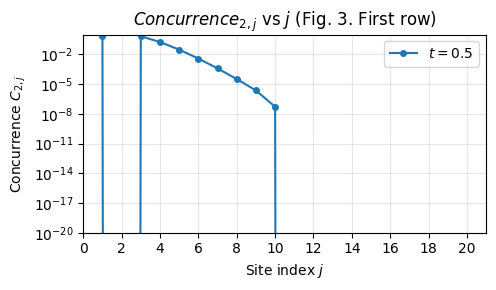

In [7]:
import matplotlib.pyplot as plt
import numpy as np
#Cmat is the concurrence matrix from above
# print(Cmat[10])

#times to plot
times_to_plot = [0.5]   # multiple times 0.2, 0.4, 0.5, 0.6, 0.8
tInterval = 0.01
plt.figure(figsize=(5,3))

for time in times_to_plot:
    # print(time)
    # print(Cmat[int(time*10)])
    plt.semilogy(Cmat[int(time/tInterval)],  "o-", lw=1.5, ms=4,
        label=rf"$t = {time:.1f}$")  # Example plotting, adjust indexing as needed
plt.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
xticks = list(range(0, 21, 2))
plt.xticks([x-1 for x in xticks], xticks)  # Shift x-ticks by 1 to match site indexing

plt.xlabel("Site index $j$")
plt.ylabel(r"Concurrence $C_{2,j}$")
plt.title(rf"$Concurrence_{{2,j}}$ vs $j$ (Fig. 3. First row)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.xlim(-1, 20)
plt.ylim(1e-20, 1)

plt.show()

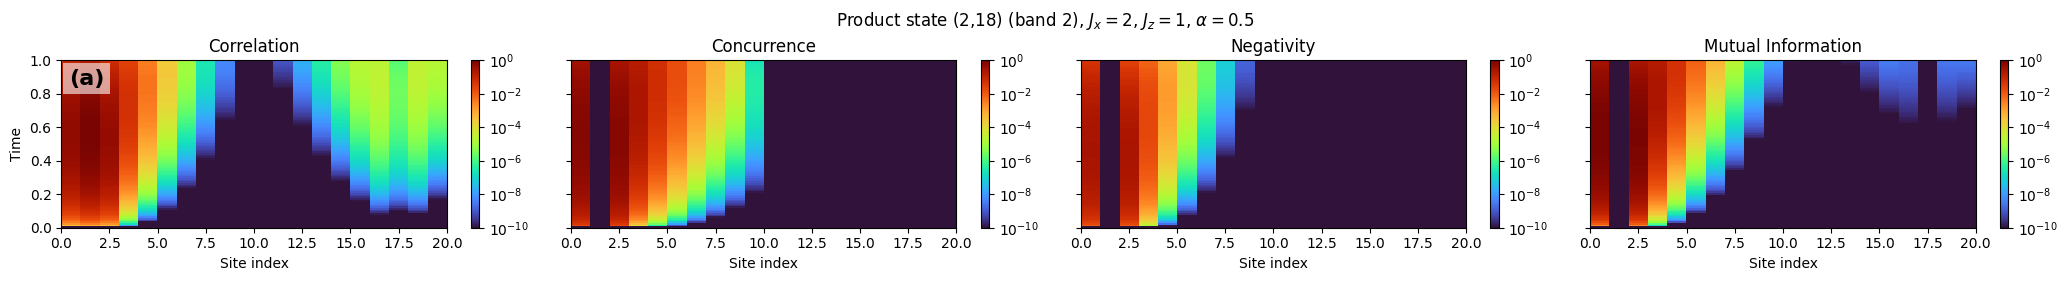

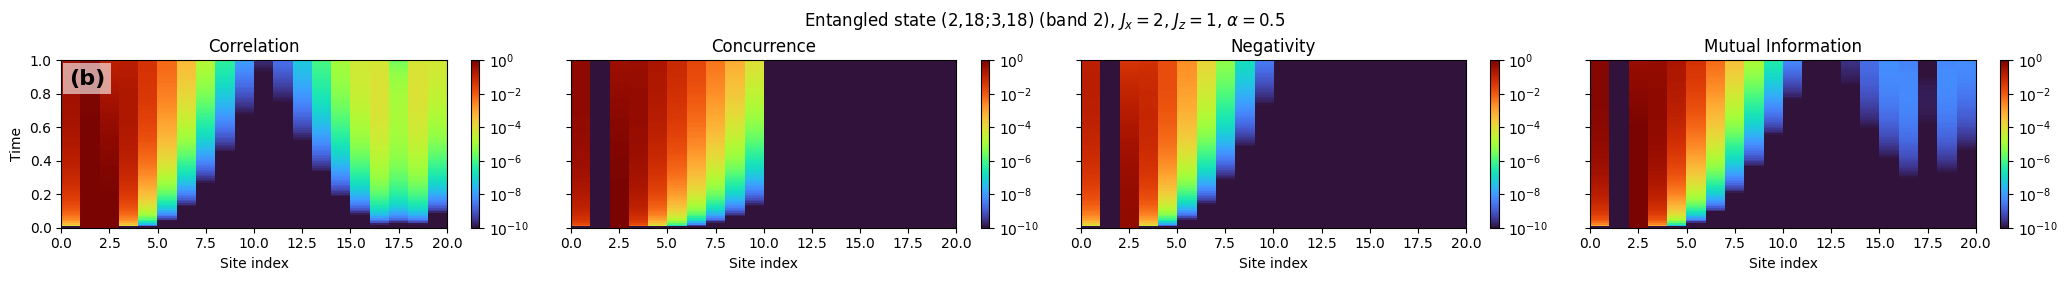

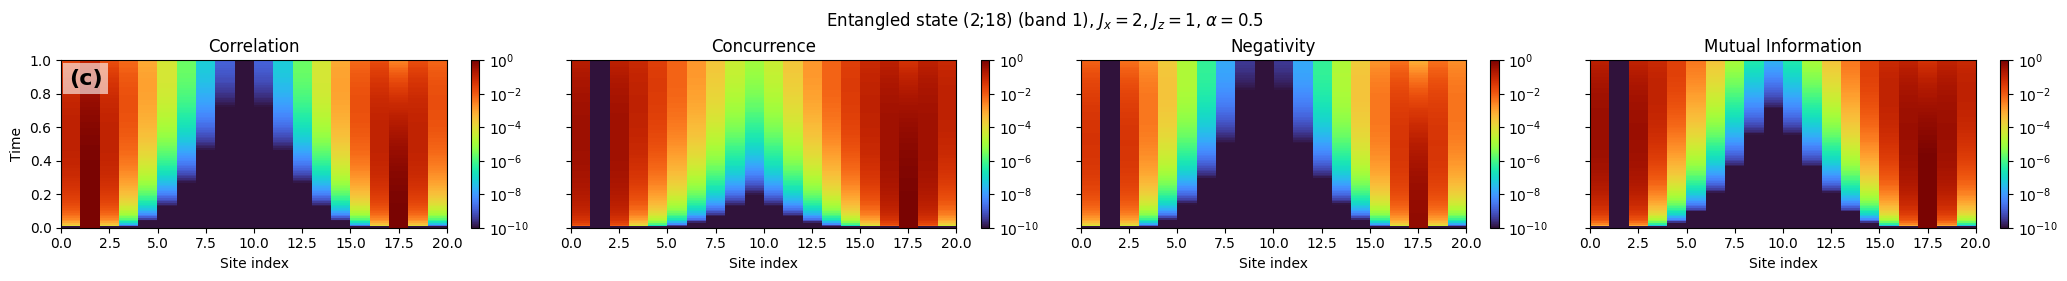

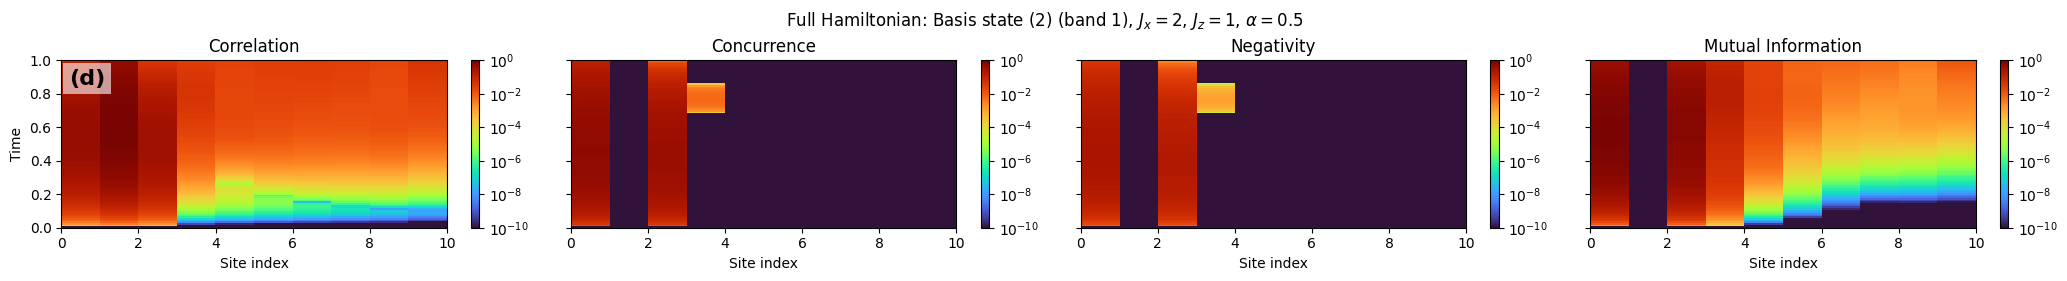

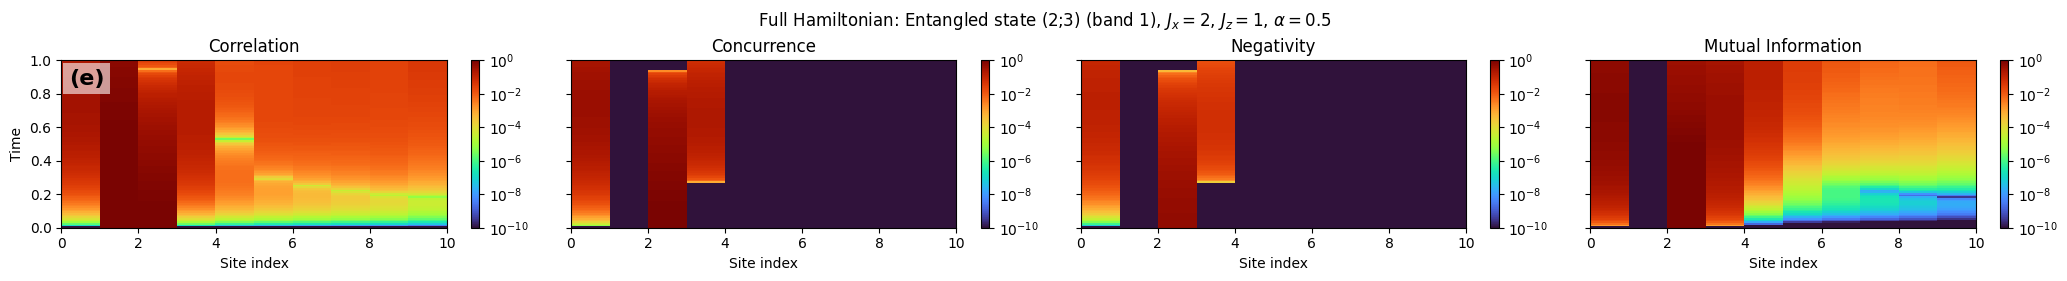

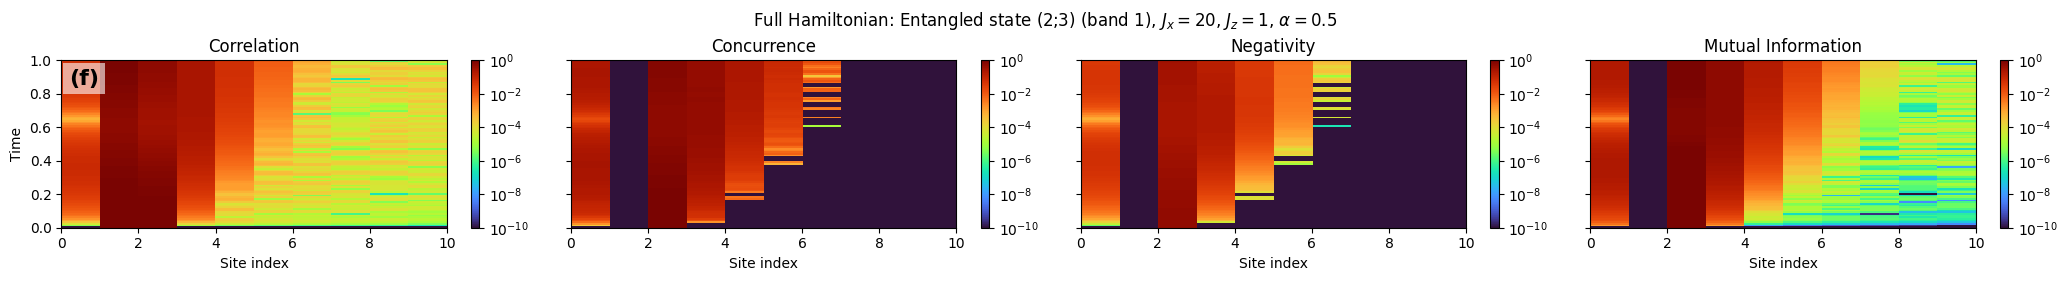

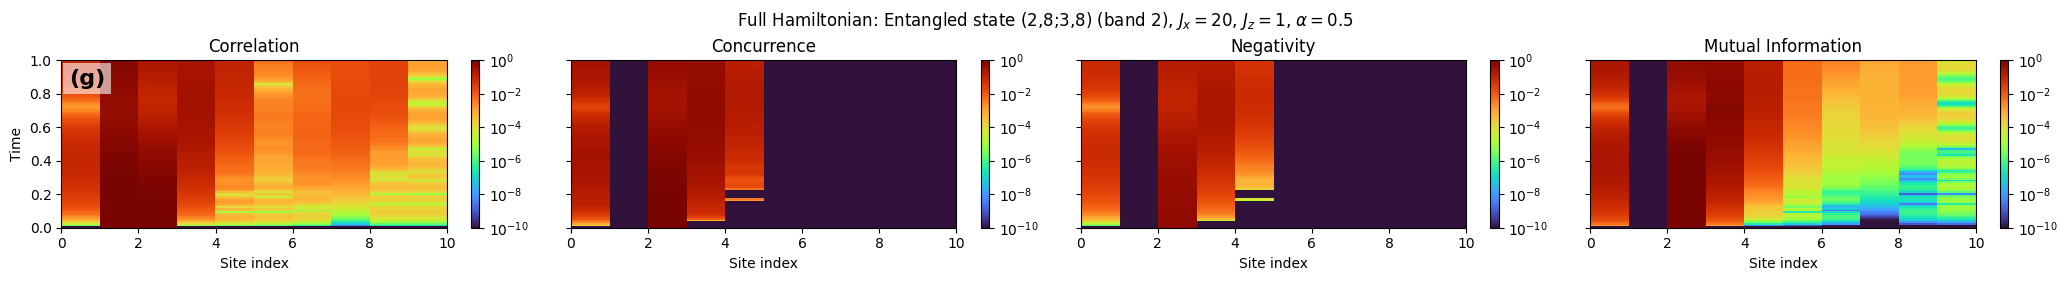

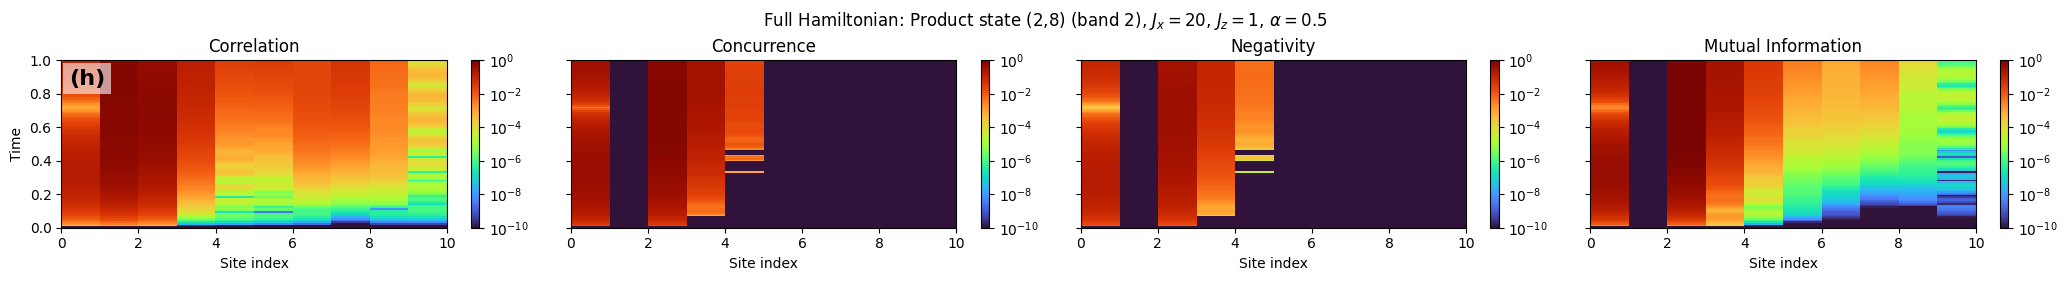

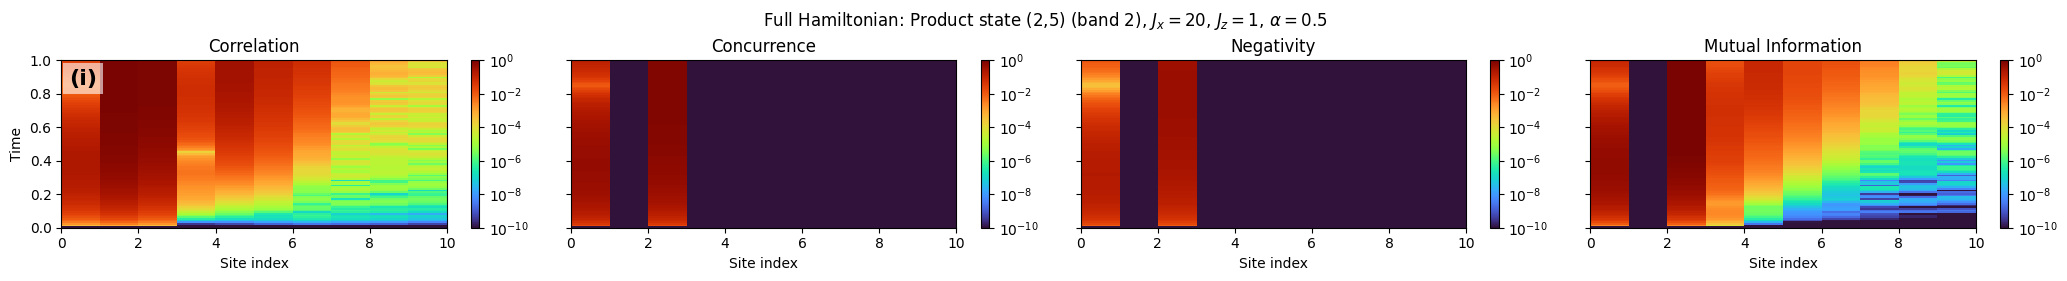

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    return max(0, evals[0] - evals[1] - evals[2] - evals[3])

# --------------------------------------------------
# Negativity computation
# --------------------------------------------------
def negativity(rho):
    # original indices: (iA, iB, jA, jB)
    #(0,1,2,3)
    rho_pt = rho.reshape(2,2,2,2).transpose(0,3,2,1).reshape(4,4)
    # indices: (iA, jB, jA, iB)
    #(0,3,2,1)
    # evals = np.linalg.eigvals(rho_pt)
    # return np.sum(np.abs(evals[evals < 0]))
    evals = np.linalg.eigvalsh(rho_pt)  # Hermitian solver
    return -np.sum(evals[evals < 0])


# --------------------------------------------------
# Von Neumann entropy
# --------------------------------------------------
def von_neumann_entropy(rho, eps=1e-12):
    evals = np.linalg.eigvalsh(rho)
    evals = np.clip(evals, eps, None)
    return -np.sum(evals * np.log2(evals))

# --------------------------------------------------
# Mutual information
# --------------------------------------------------
def mutual_information(rho):
    rho = rho / np.trace(rho)
    rhoA = np.trace(rho.reshape(2,2,2,2), axis1=1, axis2=3)
    rhoB = np.trace(rho.reshape(2,2,2,2), axis1=0, axis2=2)
    return (
        von_neumann_entropy(rhoA)
        + von_neumann_entropy(rhoB)
        - von_neumann_entropy(rho)
    )

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
configsArray = [3,4,5,10,11,12,13,14,15]
p_target = 1
t_max_plot = 1.0

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"

# panel letters: (a), (b), (c), ...
panel_letters = [f"({chr(97+i)})" for i in range(len(configsArray))]

for idx, config in enumerate(configsArray):

    ns = 10 if config >= 10 else 20

    fnameC    = f"{base}{config}Concurrence.txt"
    fnameCorr = f"{base}{config}CorrelationFunction.txt"

    dataC    = np.loadtxt(fnameC)
    dataCorr = np.loadtxt(fnameCorr)

    # --------------------------------------------------
    # Correlation data
    # --------------------------------------------------
    times_corr = dataCorr[:,0]
    CorrMat = np.abs(dataCorr[:,1:ns+1])

    # --------------------------------------------------
    # Time axis (MASTER)
    # --------------------------------------------------
    uniq_times = np.unique(dataC[:,0])
    time_mask  = uniq_times <= t_max_plot
    plot_times = uniq_times[time_mask]
    t_min, t_max = plot_times.min(), plot_times.max()

    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    # --------------------------------------------------
    # Allocate matrices
    # --------------------------------------------------
    Cmat  = np.zeros((len(uniq_times), ns))
    Nmat  = np.zeros((len(uniq_times), ns))
    MImat = np.zeros((len(uniq_times), ns))

    # --------------------------------------------------
    # Fill matrices
    # --------------------------------------------------
    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)

        Cmat[k, j]  = concurrence(rho)
        Nmat[k, j]  = negativity(rho)
        MImat[k, j] = mutual_information(rho)

    # --------------------------------------------------
    # Apply SAME time cut to ALL matrices
    # --------------------------------------------------
    Cmat  = Cmat[time_mask, :]
    Nmat  = Nmat[time_mask, :]
    MImat = MImat[time_mask, :]

    corr_mask = times_corr <= t_max_plot
    CorrMat   = CorrMat[corr_mask, :]

    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------
    fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)
    extent = [0, ns, t_min, t_max]

    im1 = ax[0].imshow(np.clip(CorrMat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo", interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im2 = ax[1].imshow(np.clip(Cmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im3 = ax[2].imshow(np.clip(Nmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im4 = ax[3].imshow(np.clip(MImat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    ax[0].set_title("Correlation")
    ax[1].set_title("Concurrence")
    ax[2].set_title("Negativity")
    ax[3].set_title("Mutual Information")

    ax[0].set_ylabel("Time")
    for a in ax:
        a.set_xlabel("Site index")

    # --------------------------------------------------
    # SINGLE panel letter for the entire row
    # --------------------------------------------------
    ax[0].text(
        0.02, 0.95, panel_letters[idx],   # 👈 INSIDE the plot
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )


    for im, a in zip([im1, im2, im3, im4], ax):
        plt.colorbar(im, ax=a)

    # --------------------------------------------------
    # Suptitles (unchanged)
    # --------------------------------------------------
    if config == 3:
        plt.suptitle(r"Product state (2,18) (band 2), $J_x=2$, $J_z=1$, $\alpha=0.5$", y=0.92)
    if config == 4:
        plt.suptitle(r"Entangled state (2,18;3,18) (band 2), $J_x=2$, $J_z=1$, $\alpha=0.5$", y=0.92)
    if config == 5:
        plt.suptitle(r"Entangled state (2;18) (band 1), $J_x=2$, $J_z=1$, $\alpha=0.5$", y=0.92)
    if config == 10:
        plt.suptitle(r"Full Hamiltonian: Basis state (2) (band 1), $J_x=2$, $J_z=1$, $\alpha=0.5$", y=0.92)
    if config == 11:
        plt.suptitle(r"Full Hamiltonian: Entangled state (2;3) (band 1), $J_x=2$, $J_z=1$, $\alpha=0.5$", y=0.92)
    if config == 12:
        plt.suptitle(r"Full Hamiltonian: Entangled state (2;3) (band 1), $J_x=20$, $J_z=1$, $\alpha=0.5$", y=0.92)
    if config == 13:
        plt.suptitle(r"Full Hamiltonian: Entangled state (2,8;3,8) (band 2), $J_x=20$, $J_z=1$, $\alpha=0.5$", y=0.92)
    if config == 14:
        plt.suptitle(r"Full Hamiltonian: Product state (2,8) (band 2), $J_x=20$, $J_z=1$, $\alpha=0.5$", y=0.92)
    if config == 15:
        plt.suptitle(r"Full Hamiltonian: Product state (2,5) (band 2), $J_x=20$, $J_z=1$, $\alpha=0.5$", y=0.92)

    plt.tight_layout()
    plt.savefig(f"plt/Concurrence_Corr_Config{config}.svg", dpi=600)
    plt.show()


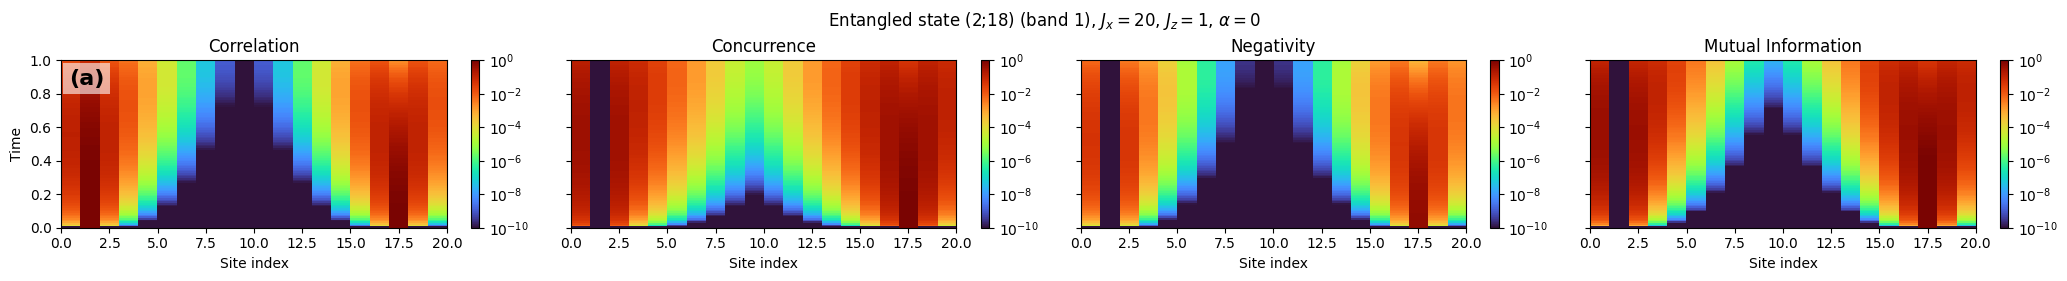

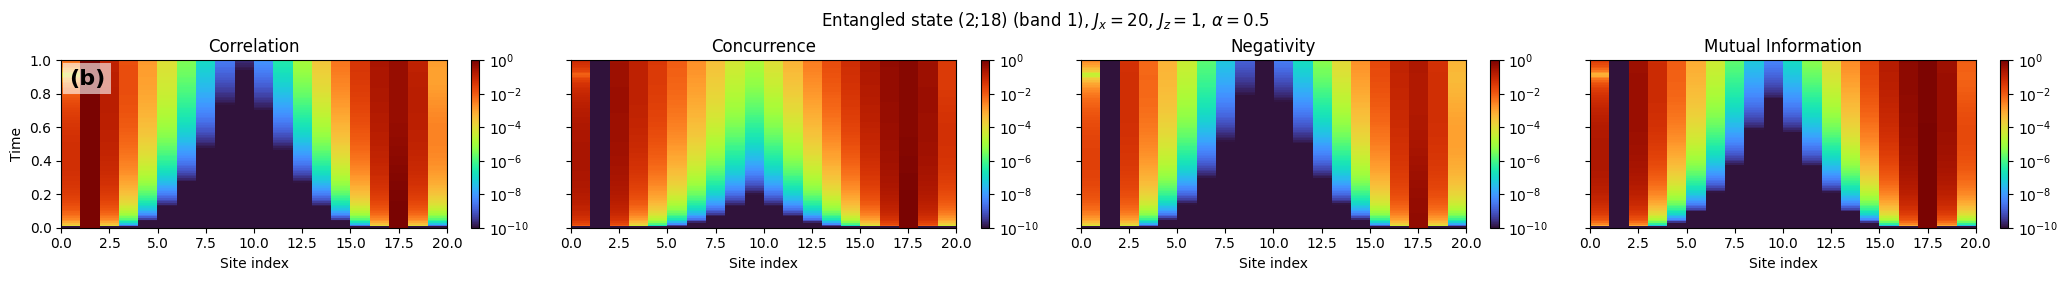

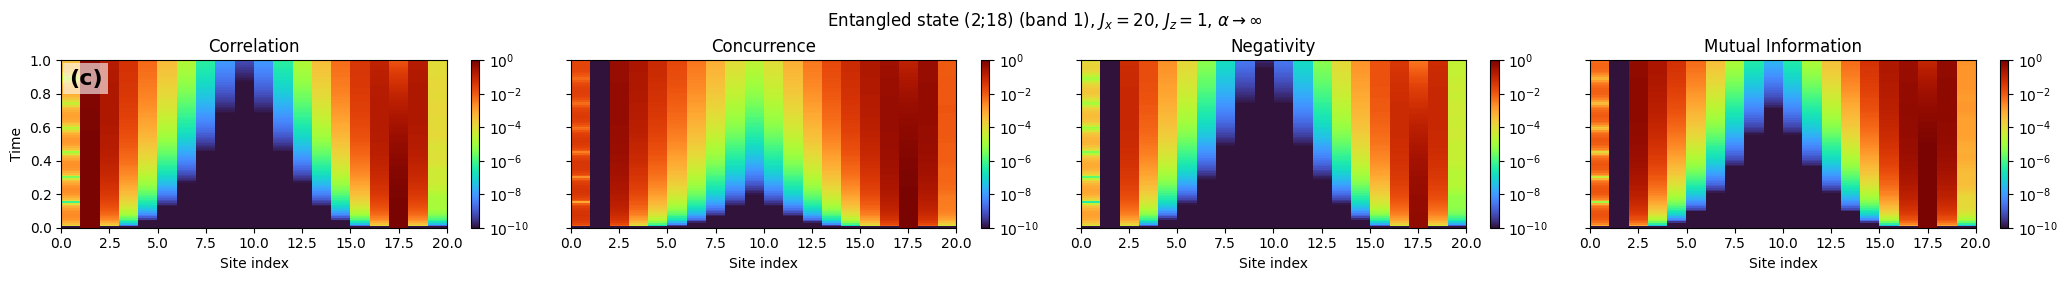

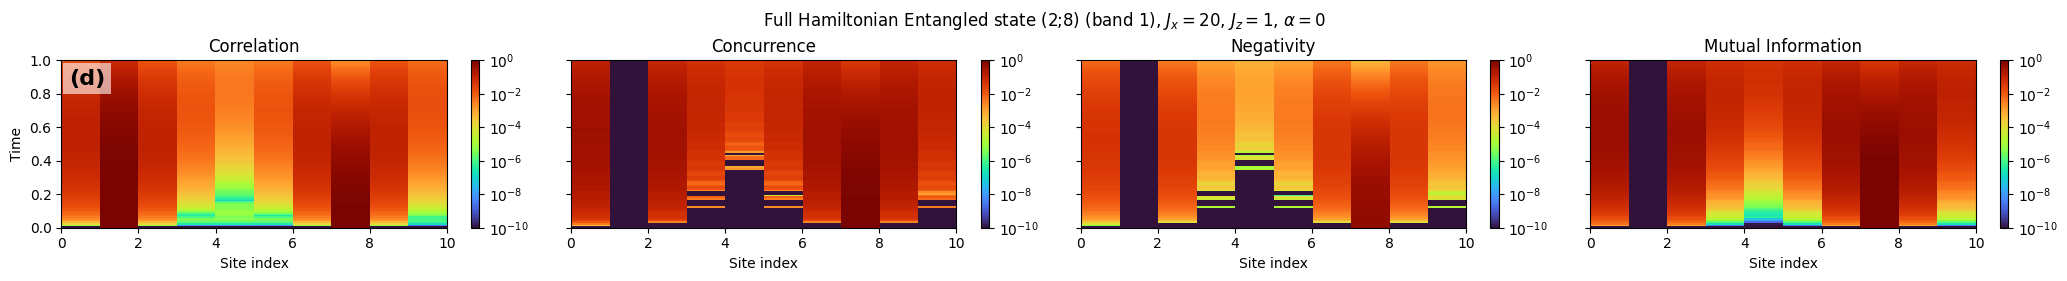

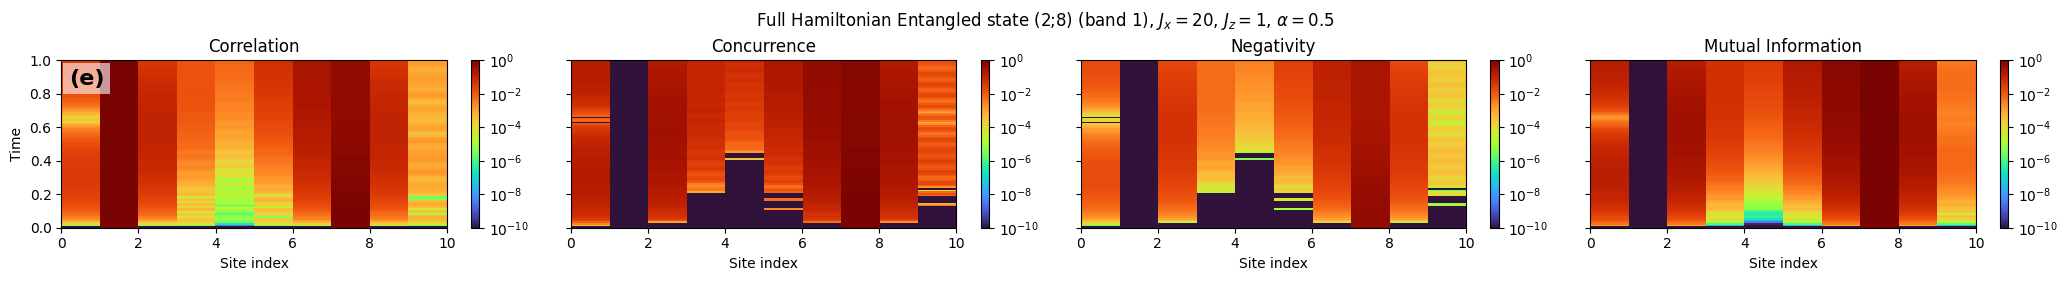

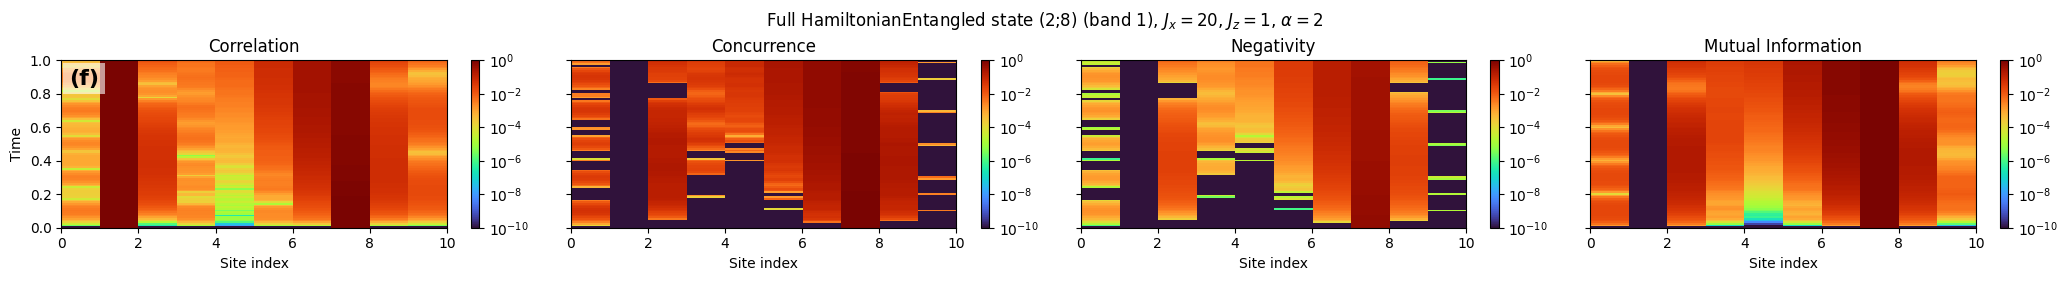

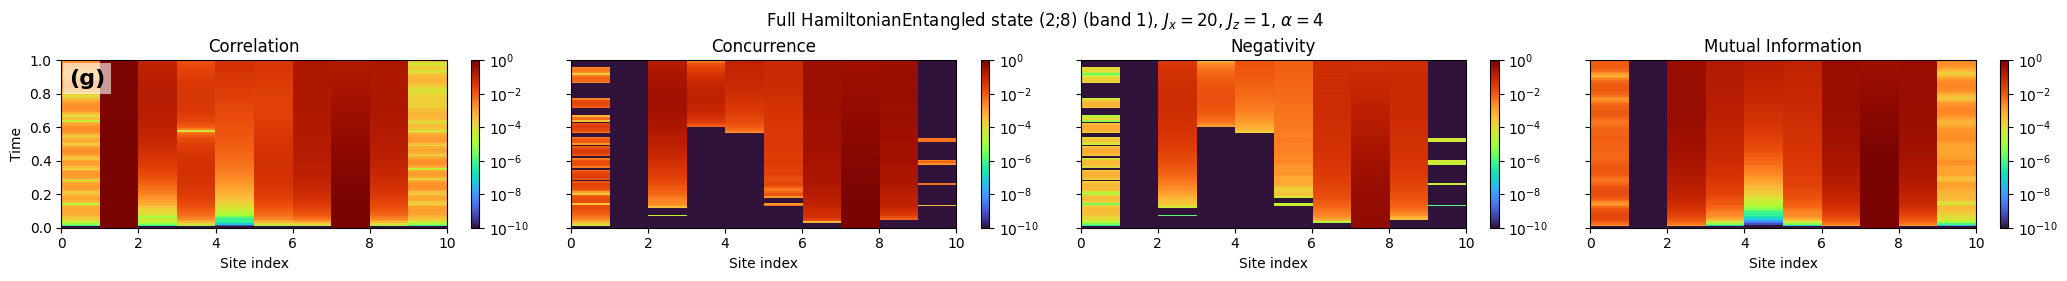

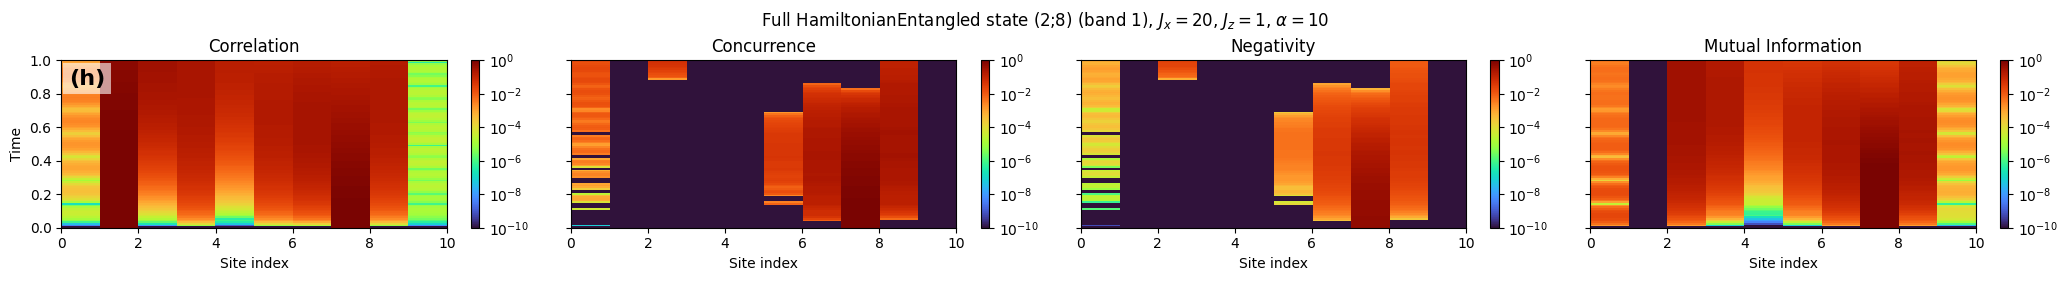

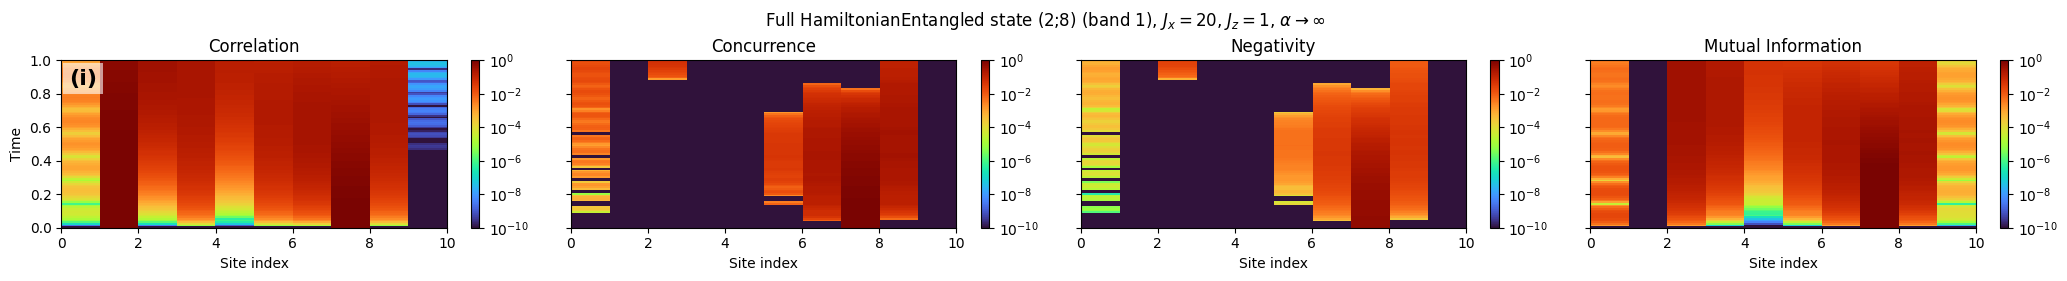

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    return max(0, evals[0] - evals[1] - evals[2] - evals[3])

# --------------------------------------------------
# Negativity computation
# --------------------------------------------------
def negativity(rho):
    # original indices: (iA, iB, jA, jB)
    #(0,1,2,3)
    rho_pt = rho.reshape(2,2,2,2).transpose(0,3,2,1).reshape(4,4)
    # indices: (iA, jB, jA, iB)
    #(0,3,2,1)
    # evals = np.linalg.eigvals(rho_pt)
    # return np.sum(np.abs(evals[evals < 0]))
    evals = np.linalg.eigvalsh(rho_pt)  # Hermitian solver
    return -np.sum(evals[evals < 0])


# --------------------------------------------------
# Von Neumann entropy
# --------------------------------------------------
def von_neumann_entropy(rho, eps=1e-12):
    evals = np.linalg.eigvalsh(rho)
    evals = np.clip(evals, eps, None)
    return -np.sum(evals * np.log2(evals))

# --------------------------------------------------
# Mutual information
# --------------------------------------------------
def mutual_information(rho):
    rho = rho / np.trace(rho)
    rhoA = np.trace(rho.reshape(2,2,2,2), axis1=1, axis2=3)
    rhoB = np.trace(rho.reshape(2,2,2,2), axis1=0, axis2=2)
    return (
        von_neumann_entropy(rhoA)
        + von_neumann_entropy(rhoB)
        - von_neumann_entropy(rho)
    )

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
configsArray = [20,21,22,23,24,26,27,28,25]
p_target = 1
t_max_plot = 1.0

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"

# panel letters: (a), (b), (c), ...
panel_letters = [f"({chr(97+i)})" for i in range(len(configsArray))]

for idx, config in enumerate(configsArray):

    ns = 10 if config >= 23 else 20

    fnameC    = f"{base}{config}Concurrence.txt"
    fnameCorr = f"{base}{config}CorrelationFunction.txt"

    dataC    = np.loadtxt(fnameC)
    dataCorr = np.loadtxt(fnameCorr)

    # --------------------------------------------------
    # Correlation data
    # --------------------------------------------------
    times_corr = dataCorr[:,0]
    CorrMat = np.abs(dataCorr[:,1:ns+1])

    # --------------------------------------------------
    # Time axis (MASTER)
    # --------------------------------------------------
    uniq_times = np.unique(dataC[:,0])
    time_mask  = uniq_times <= t_max_plot
    plot_times = uniq_times[time_mask]
    t_min, t_max = plot_times.min(), plot_times.max()

    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    # --------------------------------------------------
    # Allocate matrices
    # --------------------------------------------------
    Cmat  = np.zeros((len(uniq_times), ns))
    Nmat  = np.zeros((len(uniq_times), ns))
    MImat = np.zeros((len(uniq_times), ns))

    # --------------------------------------------------
    # Fill matrices
    # --------------------------------------------------
    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)

        Cmat[k, j]  = concurrence(rho)
        Nmat[k, j]  = negativity(rho)
        MImat[k, j] = mutual_information(rho)

    # --------------------------------------------------
    # Apply SAME time cut to ALL matrices
    # --------------------------------------------------
    Cmat  = Cmat[time_mask, :]
    Nmat  = Nmat[time_mask, :]
    MImat = MImat[time_mask, :]

    corr_mask = times_corr <= t_max_plot
    CorrMat   = CorrMat[corr_mask, :]

    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------
    fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)
    extent = [0, ns, t_min, t_max]

    im1 = ax[0].imshow(np.clip(CorrMat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo", interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im2 = ax[1].imshow(np.clip(Cmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im3 = ax[2].imshow(np.clip(Nmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im4 = ax[3].imshow(np.clip(MImat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    ax[0].set_title("Correlation")
    ax[1].set_title("Concurrence")
    ax[2].set_title("Negativity")
    ax[3].set_title("Mutual Information")

    ax[0].set_ylabel("Time")
    for a in ax:
        a.set_xlabel("Site index")

    # --------------------------------------------------
    # SINGLE panel letter for the entire row
    # --------------------------------------------------
    ax[0].text(
        0.02, 0.95, panel_letters[idx],   # 👈 INSIDE the plot
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )


    for im, a in zip([im1, im2, im3, im4], ax):
        plt.colorbar(im, ax=a)

    # --------------------------------------------------
    # Suptitles (unchanged)
    # --------------------------------------------------
    if config == 20:
        plt.suptitle(r"Entangled state (2;18) (band 1), $J_x=20$, $J_z=1$, $\alpha=0$", y=0.92)
    if config == 21:
        plt.suptitle(r"Entangled state (2;18) (band 1), $J_x=20$, $J_z=1$, $\alpha=0.5$", y=0.92)
    if config == 22:
        plt.suptitle(r"Entangled state (2;18) (band 1), $J_x=20$, $J_z=1$, $\alpha \to \infty$", y=0.92)
    if config == 23:
        plt.suptitle(r"Full Hamiltonian Entangled state (2;8) (band 1), $J_x=20$, $J_z=1$, $\alpha=0$", y=0.92)
    if config == 24:
        plt.suptitle(r"Full Hamiltonian Entangled state (2;8) (band 1), $J_x=20$, $J_z=1$, $\alpha=0.5$", y=0.92)
    if config == 25:
        plt.suptitle(r"Full HamiltonianEntangled state (2;8) (band 1), $J_x=20$, $J_z=1$, $\alpha \to \infty$", y=0.92)
    if config == 26:
        plt.suptitle(r"Full HamiltonianEntangled state (2;8) (band 1), $J_x=20$, $J_z=1$, $\alpha=2$", y=0.92)
    if config == 27:
        plt.suptitle(r"Full HamiltonianEntangled state (2;8) (band 1), $J_x=20$, $J_z=1$, $\alpha=4$", y=0.92)
    if config == 28:
        plt.suptitle(r"Full HamiltonianEntangled state (2;8) (band 1), $J_x=20$, $J_z=1$, $\alpha=10$", y=0.92)
    plt.tight_layout()
    plt.savefig(f"plt/Concurrence_Corr_Config{config}.svg", dpi=600)
    plt.show()


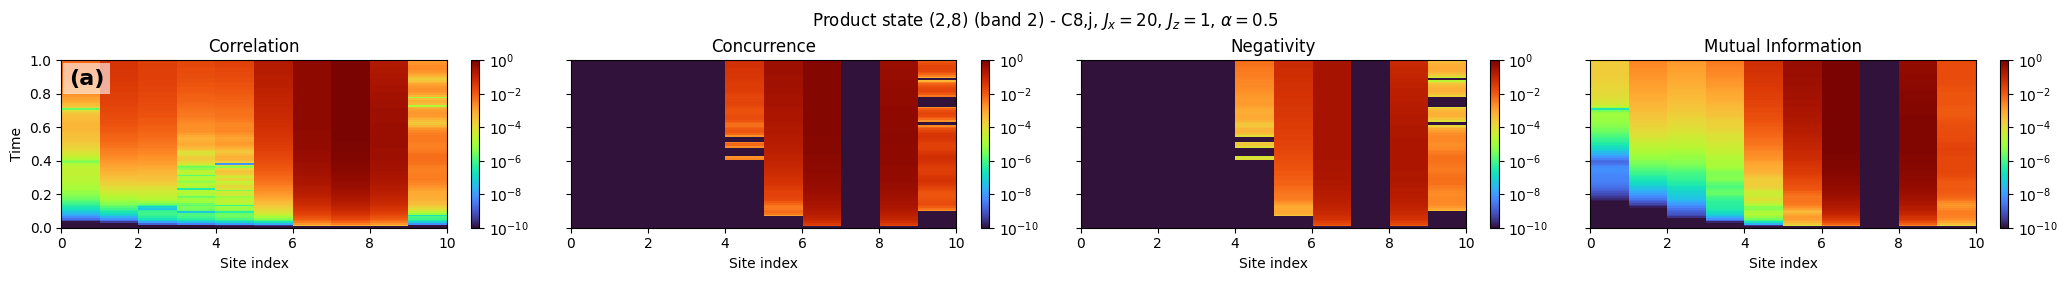

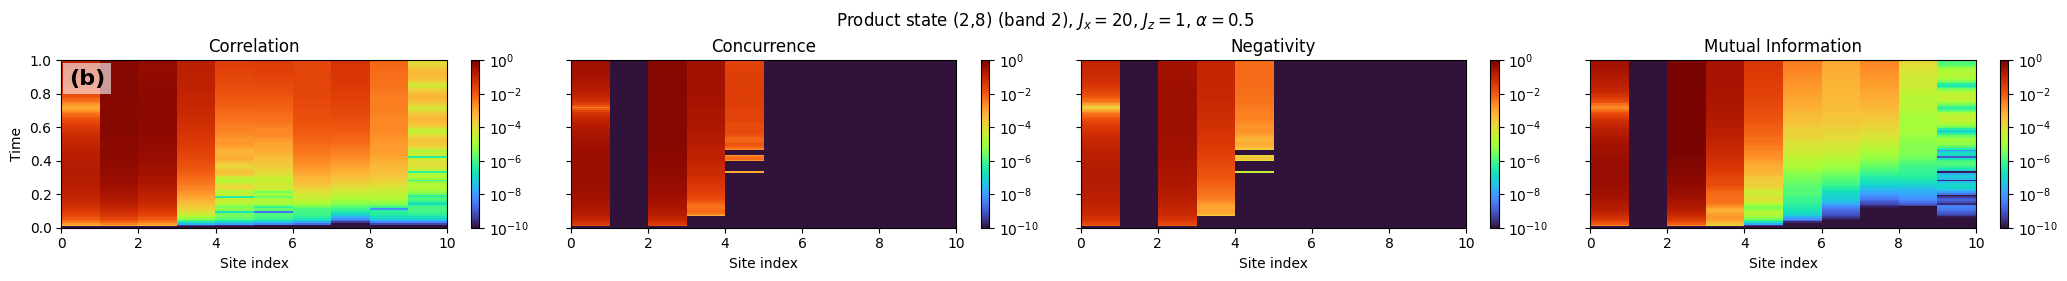

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    return max(0, evals[0] - evals[1] - evals[2] - evals[3])

# --------------------------------------------------
# Negativity computation
# --------------------------------------------------
def negativity(rho):
    # original indices: (iA, iB, jA, jB)
    #(0,1,2,3)
    rho_pt = rho.reshape(2,2,2,2).transpose(0,3,2,1).reshape(4,4)
    # indices: (iA, jB, jA, iB)
    #(0,3,2,1)
    # evals = np.linalg.eigvals(rho_pt)
    # return np.sum(np.abs(evals[evals < 0]))
    evals = np.linalg.eigvalsh(rho_pt)  # Hermitian solver
    return -np.sum(evals[evals < 0])


# --------------------------------------------------
# Von Neumann entropy
# --------------------------------------------------
def von_neumann_entropy(rho, eps=1e-12):
    evals = np.linalg.eigvalsh(rho)
    evals = np.clip(evals, eps, None)
    return -np.sum(evals * np.log2(evals))

# --------------------------------------------------
# Mutual information
# --------------------------------------------------
def mutual_information(rho):
    rho = rho / np.trace(rho)
    rhoA = np.trace(rho.reshape(2,2,2,2), axis1=1, axis2=3)
    rhoB = np.trace(rho.reshape(2,2,2,2), axis1=0, axis2=2)
    return (
        von_neumann_entropy(rhoA)
        + von_neumann_entropy(rhoB)
        - von_neumann_entropy(rho)
    )

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
configsArray = [30,31]#,31

t_max_plot = 1.0

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"

# panel letters: (a), (b), (c), ...
panel_letters = [f"({chr(97+i)})" for i in range(len(configsArray))]

for idx, config in enumerate(configsArray):

    ns = 10 if config >= 23 else 20
    if config == 30:
        p_target = 7
    else:
        p_target = 1
    fnameC    = f"{base}{config}Concurrence.txt"
    fnameCorr = f"{base}{config}CorrelationFunction.txt"

    dataC    = np.loadtxt(fnameC)
    dataCorr = np.loadtxt(fnameCorr)

    # --------------------------------------------------
    # Correlation data
    # --------------------------------------------------
    times_corr = dataCorr[:,0]
    CorrMat = np.abs(dataCorr[:,1:ns+1])

    # --------------------------------------------------
    # Time axis (MASTER)
    # --------------------------------------------------
    uniq_times = np.unique(dataC[:,0])
    time_mask  = uniq_times <= t_max_plot
    plot_times = uniq_times[time_mask]
    t_min, t_max = plot_times.min(), plot_times.max()

    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    # --------------------------------------------------
    # Allocate matrices
    # --------------------------------------------------
    Cmat  = np.zeros((len(uniq_times), ns))
    Nmat  = np.zeros((len(uniq_times), ns))
    MImat = np.zeros((len(uniq_times), ns))

    # --------------------------------------------------
    # Fill matrices
    # --------------------------------------------------
    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)

        Cmat[k, j]  = concurrence(rho)
        Nmat[k, j]  = negativity(rho)
        MImat[k, j] = mutual_information(rho)

    # --------------------------------------------------
    # Apply SAME time cut to ALL matrices
    # --------------------------------------------------
    Cmat  = Cmat[time_mask, :]
    Nmat  = Nmat[time_mask, :]
    MImat = MImat[time_mask, :]

    corr_mask = times_corr <= t_max_plot
    CorrMat   = CorrMat[corr_mask, :]

    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------
    fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)
    extent = [0, ns, t_min, t_max]

    im1 = ax[0].imshow(np.clip(CorrMat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo", interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im2 = ax[1].imshow(np.clip(Cmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im3 = ax[2].imshow(np.clip(Nmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im4 = ax[3].imshow(np.clip(MImat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    ax[0].set_title("Correlation")
    ax[1].set_title("Concurrence")
    ax[2].set_title("Negativity")
    ax[3].set_title("Mutual Information")

    ax[0].set_ylabel("Time")
    for a in ax:
        a.set_xlabel("Site index")

    # --------------------------------------------------
    # SINGLE panel letter for the entire row
    # --------------------------------------------------
    ax[0].text(
        0.02, 0.95, panel_letters[idx],   # 👈 INSIDE the plot
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )


    for im, a in zip([im1, im2, im3, im4], ax):
        plt.colorbar(im, ax=a)

    # --------------------------------------------------
    # Suptitles (unchanged)
    # --------------------------------------------------
    if config == 30:
        plt.suptitle(r"Product state (2,8) (band 2) - C8,j, $J_x=20$, $J_z=1$, $\alpha=0.5$", y=0.92)
    if config == 31:
        plt.suptitle(r"Product state (2,8) (band 2), $J_x=20$, $J_z=1$, $\alpha=0.5$", y=0.92)

    plt.tight_layout()
    plt.savefig(f"plt/Concurrence_Corr_Config{config}.svg", dpi=600)
    plt.show()


## 3 excitations

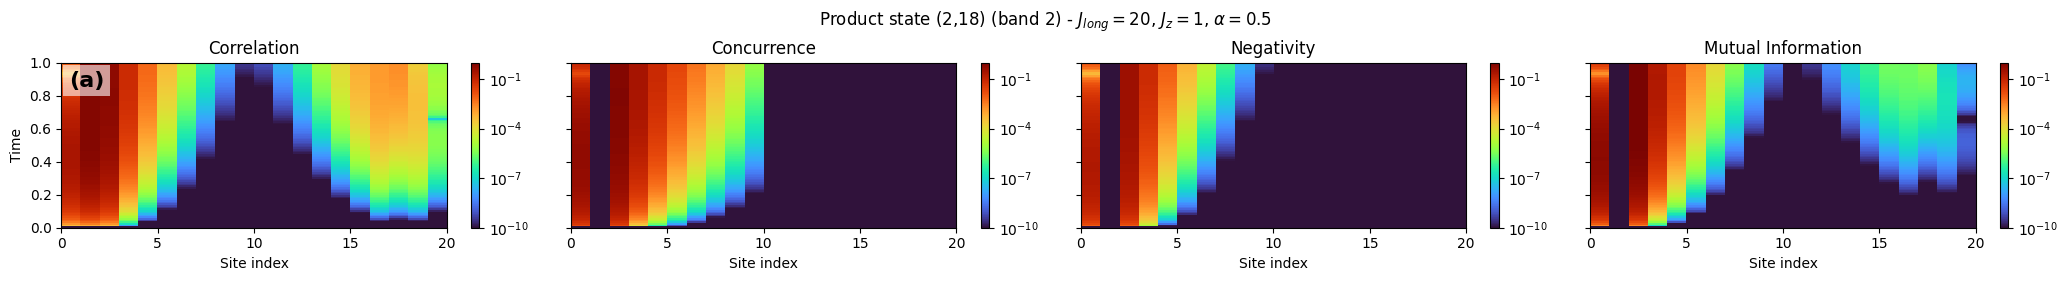

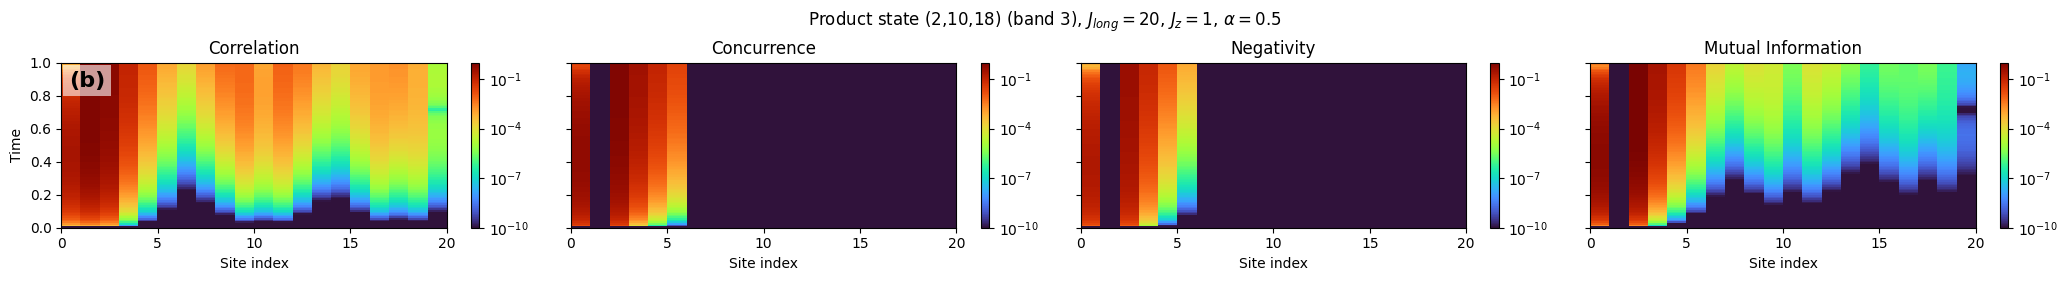

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    return max(0, evals[0] - evals[1] - evals[2] - evals[3])

# --------------------------------------------------
# Negativity computation
# --------------------------------------------------
def negativity(rho):
    # original indices: (iA, iB, jA, jB)
    #(0,1,2,3)
    rho_pt = rho.reshape(2,2,2,2).transpose(0,3,2,1).reshape(4,4)
    # indices: (iA, jB, jA, iB)
    #(0,3,2,1)
    # evals = np.linalg.eigvals(rho_pt)
    # return np.sum(np.abs(evals[evals < 0]))
    evals = np.linalg.eigvalsh(rho_pt)  # Hermitian solver
    return -np.sum(evals[evals < 0])


# --------------------------------------------------
# Von Neumann entropy
# --------------------------------------------------
def von_neumann_entropy(rho, eps=1e-12):
    evals = np.linalg.eigvalsh(rho)
    evals = np.clip(evals, eps, None)
    return -np.sum(evals * np.log2(evals))

# --------------------------------------------------
# Mutual information
# --------------------------------------------------
def mutual_information(rho):
    rho = rho / np.trace(rho)
    rhoA = np.trace(rho.reshape(2,2,2,2), axis1=1, axis2=3)
    rhoB = np.trace(rho.reshape(2,2,2,2), axis1=0, axis2=2)
    return (
        von_neumann_entropy(rhoA)
        + von_neumann_entropy(rhoB)
        - von_neumann_entropy(rho)
    )

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
configsArray = [40,41]#,31

t_max_plot = 1.0

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"

# panel letters: (a), (b), (c), ...
panel_letters = [f"({chr(97+i)})" for i in range(len(configsArray))]

for idx, config in enumerate(configsArray):

    ns = 20
    p_target = 1
    # if config == 30:
    #     p_target = 7
    # else:
    #     p_target = 1
    fnameC    = f"{base}{config}Concurrence.txt"
    fnameCorr = f"{base}{config}CorrelationFunction.txt"

    dataC    = np.loadtxt(fnameC)
    dataCorr = np.loadtxt(fnameCorr)

    # --------------------------------------------------
    # Correlation data
    # --------------------------------------------------
    times_corr = dataCorr[:,0]
    CorrMat = np.abs(dataCorr[:,1:ns+1])

    # --------------------------------------------------
    # Time axis (MASTER)
    # --------------------------------------------------
    uniq_times = np.unique(dataC[:,0])
    time_mask  = uniq_times <= t_max_plot
    plot_times = uniq_times[time_mask]
    t_min, t_max = plot_times.min(), plot_times.max()

    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    # --------------------------------------------------
    # Allocate matrices
    # --------------------------------------------------
    Cmat  = np.zeros((len(uniq_times), ns))
    Nmat  = np.zeros((len(uniq_times), ns))
    MImat = np.zeros((len(uniq_times), ns))

    # --------------------------------------------------
    # Fill matrices
    # --------------------------------------------------
    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)

        Cmat[k, j]  = concurrence(rho)
        Nmat[k, j]  = negativity(rho)
        MImat[k, j] = mutual_information(rho)

    # --------------------------------------------------
    # Apply SAME time cut to ALL matrices
    # --------------------------------------------------
    Cmat  = Cmat[time_mask, :]
    Nmat  = Nmat[time_mask, :]
    MImat = MImat[time_mask, :]

    corr_mask = times_corr <= t_max_plot
    CorrMat   = CorrMat[corr_mask, :]

    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------
    fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)
    extent = [0, ns, t_min, t_max]

    im1 = ax[0].imshow(np.clip(CorrMat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo", interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im2 = ax[1].imshow(np.clip(Cmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im3 = ax[2].imshow(np.clip(Nmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im4 = ax[3].imshow(np.clip(MImat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    x_ticks = np.arange(0, ns + 1, 5)

    for a in ax:
        a.set_xticks(x_ticks)
        a.set_xticklabels([f"{int(x)}" for x in x_ticks])

    ax[0].set_title("Correlation")
    ax[1].set_title("Concurrence")
    ax[2].set_title("Negativity")
    ax[3].set_title("Mutual Information")

    ax[0].set_ylabel("Time")
    for a in ax:
        a.set_xlabel("Site index")

    # --------------------------------------------------
    # SINGLE panel letter for the entire row
    # --------------------------------------------------
    ax[0].text(
        0.02, 0.95, panel_letters[idx],   # 👈 INSIDE the plot
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )


    for im, a in zip([im1, im2, im3, im4], ax):
        plt.colorbar(im, ax=a)

    # --------------------------------------------------
    # Suptitles (unchanged)
    # --------------------------------------------------
    if config == 40:
        plt.suptitle(r"Product state (2,18) (band 2) - $J_{long}=20$, $J_z=1$, $\alpha=0.5$", y=0.92)
    if config == 41:
        plt.suptitle(r"Product state (2,10,18) (band 3), $J_{long}=20$, $J_z=1$, $\alpha=0.5$", y=0.92)

    plt.tight_layout()
    plt.savefig(f"plt/Concurrence_Corr_Config{config}.svg", dpi=600)
    plt.show()


# Concurrence Matrix
alpha=0.5 band 1$

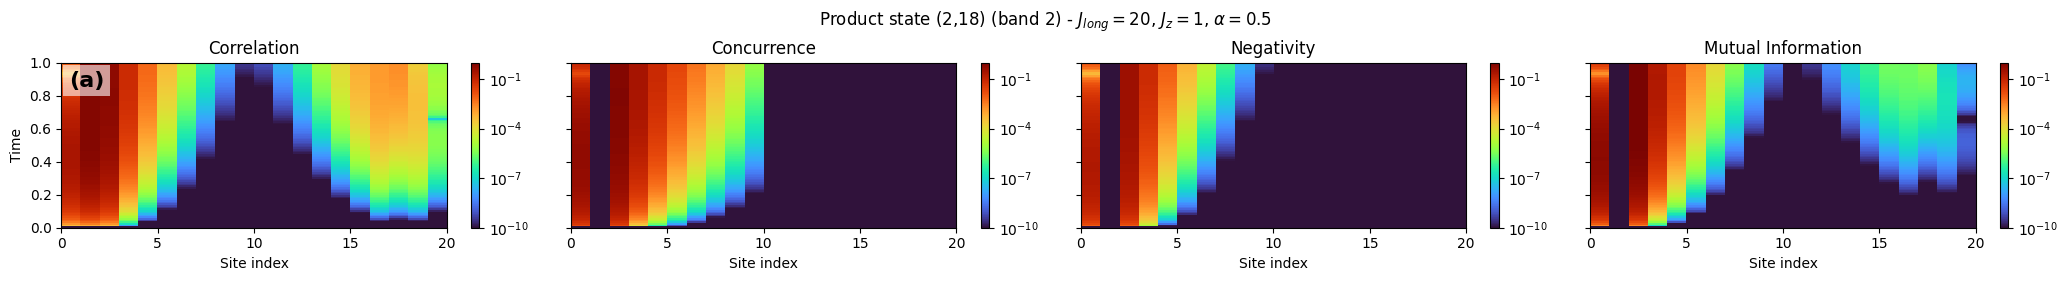

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    return max(0, evals[0] - evals[1] - evals[2] - evals[3])

# --------------------------------------------------
# Negativity computation
# --------------------------------------------------
def negativity(rho):
    # original indices: (iA, iB, jA, jB)
    #(0,1,2,3)
    rho_pt = rho.reshape(2,2,2,2).transpose(0,3,2,1).reshape(4,4)
    # indices: (iA, jB, jA, iB)
    #(0,3,2,1)
    # evals = np.linalg.eigvals(rho_pt)
    # return np.sum(np.abs(evals[evals < 0]))
    evals = np.linalg.eigvalsh(rho_pt)  # Hermitian solver
    return -np.sum(evals[evals < 0])


# --------------------------------------------------
# Von Neumann entropy
# --------------------------------------------------
def von_neumann_entropy(rho, eps=1e-12):
    evals = np.linalg.eigvalsh(rho)
    evals = np.clip(evals, eps, None)
    return -np.sum(evals * np.log2(evals))

# --------------------------------------------------
# Mutual information
# --------------------------------------------------
def mutual_information(rho):
    rho = rho / np.trace(rho)
    rhoA = np.trace(rho.reshape(2,2,2,2), axis1=1, axis2=3)
    rhoB = np.trace(rho.reshape(2,2,2,2), axis1=0, axis2=2)
    return (
        von_neumann_entropy(rhoA)
        + von_neumann_entropy(rhoB)
        - von_neumann_entropy(rho)
    )

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
configsArray = [50]#,31

t_max_plot = 1.0

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"

# panel letters: (a), (b), (c), ...
panel_letters = [f"({chr(97+i)})" for i in range(len(configsArray))]

for idx, config in enumerate(configsArray):

    ns = 20
    p_target = 1
    # if config == 30:
    #     p_target = 7
    # else:
    #     p_target = 1
    fnameC    = f"{base}{config}Concurrence.txt"
    fnameCorr = f"{base}{config}CorrelationFunction.txt"

    dataC    = np.loadtxt(fnameC)
    dataCorr = np.loadtxt(fnameCorr)

    # --------------------------------------------------
    # Correlation data
    # --------------------------------------------------
    times_corr = dataCorr[:,0]
    CorrMat = np.abs(dataCorr[:,1:ns+1])

    # --------------------------------------------------
    # Time axis (MASTER)
    # --------------------------------------------------
    uniq_times = np.unique(dataC[:,0])
    time_mask  = uniq_times <= t_max_plot
    plot_times = uniq_times[time_mask]
    t_min, t_max = plot_times.min(), plot_times.max()

    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    # --------------------------------------------------
    # Allocate matrices
    # --------------------------------------------------
    Cmat  = np.zeros((len(uniq_times), ns))
    Nmat  = np.zeros((len(uniq_times), ns))
    MImat = np.zeros((len(uniq_times), ns))

    # --------------------------------------------------
    # Fill matrices
    # --------------------------------------------------
    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)

        Cmat[k, j]  = concurrence(rho)
        Nmat[k, j]  = negativity(rho)
        MImat[k, j] = mutual_information(rho)

    # --------------------------------------------------
    # Apply SAME time cut to ALL matrices
    # --------------------------------------------------
    Cmat  = Cmat[time_mask, :]
    Nmat  = Nmat[time_mask, :]
    MImat = MImat[time_mask, :]

    corr_mask = times_corr <= t_max_plot
    CorrMat   = CorrMat[corr_mask, :]

    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------
    fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)
    extent = [0, ns, t_min, t_max]

    im1 = ax[0].imshow(np.clip(CorrMat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo", interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im2 = ax[1].imshow(np.clip(Cmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im3 = ax[2].imshow(np.clip(Nmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im4 = ax[3].imshow(np.clip(MImat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    x_ticks = np.arange(0, ns + 1, 5)

    for a in ax:
        a.set_xticks(x_ticks)
        a.set_xticklabels([f"{int(x)}" for x in x_ticks])

    ax[0].set_title("Correlation")
    ax[1].set_title("Concurrence")
    ax[2].set_title("Negativity")
    ax[3].set_title("Mutual Information")

    ax[0].set_ylabel("Time")
    for a in ax:
        a.set_xlabel("Site index")

    # --------------------------------------------------
    # SINGLE panel letter for the entire row
    # --------------------------------------------------
    ax[0].text(
        0.02, 0.95, panel_letters[idx],   # 👈 INSIDE the plot
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )


    for im, a in zip([im1, im2, im3, im4], ax):
        plt.colorbar(im, ax=a)

    # --------------------------------------------------
    # Suptitles (unchanged)
    # --------------------------------------------------
    if config == 50:
        plt.suptitle(r"Product state (2,18) (band 2) - $J_{long}=20$, $J_z=1$, $\alpha=0.5$", y=0.92)

    plt.tight_layout()
    plt.savefig(f"plt/Concurrence_Corr_Config{config}.pdf", dpi=600)
    plt.show()


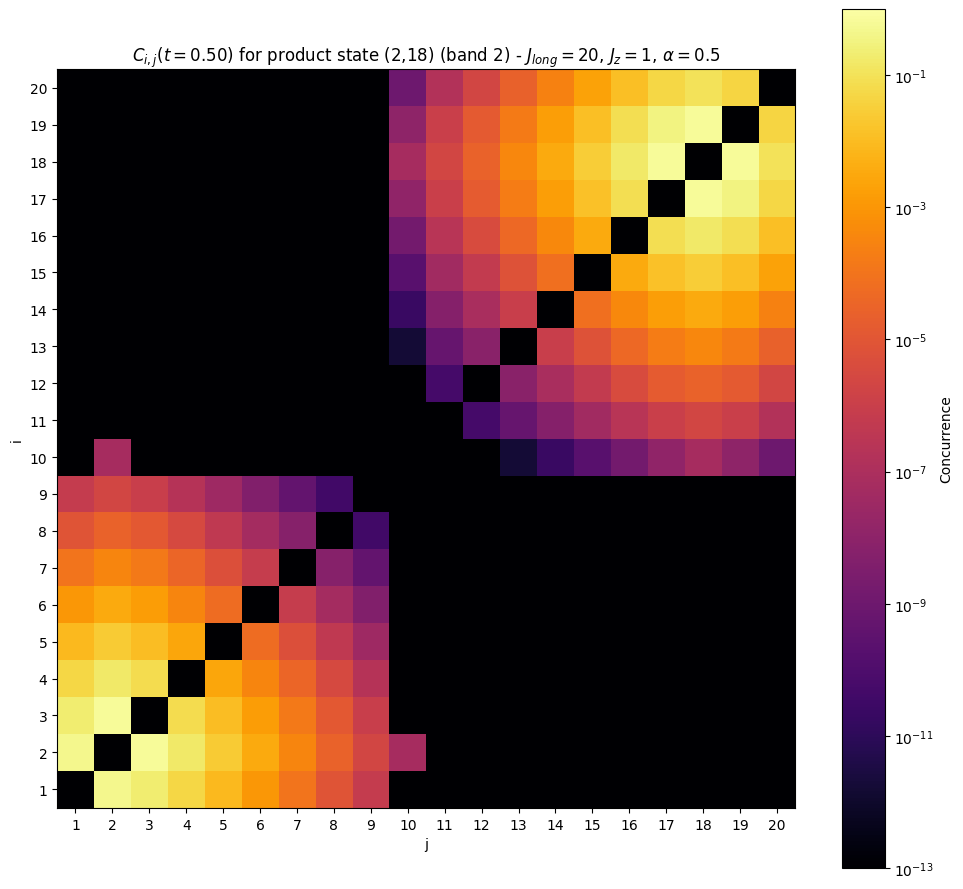

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def load_concurrence_file(fname):
    data = np.loadtxt(fname)

    out = []
    for row in data:
        t = row[0]
        p = int(row[1])
        j = int(row[2])

        rho_vals = row[4:]
        rho = rho_vals.reshape(4,4,2)
        rho = rho[:,:,0] + 1j*rho[:,:,1]

        out.append((t, p, j, rho))

    return out

def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    Y = np.kron(sy, sy)

    R = rho @ (Y @ rho.conj() @ Y)
    evals = np.real(np.linalg.eigvals(R))
    evals = np.maximum(evals, 0.0)
    evals = np.sort(np.sqrt(evals))[::-1]

    return max(0.0, evals[0] - evals[1] - evals[2] - evals[3])

def concurrence_matrix(data, t_target, ns, tol=1e-12):
    C = np.zeros((ns, ns))

    for t, p, j, rho in data:
        if abs(t - t_target) > tol:
            continue

        c = concurrence(rho)
        C[p, j] = c
        # C[j, p] = c   # symmetry

    return C

ns = 20
t0 = 0.5
base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"
fname = f"{base}50Concurrence.txt"
data = load_concurrence_file(fname)

C = concurrence_matrix(data, t0, ns)

# --------------------------------------------------
# PLOT
# --------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# --- threshold ---
vmin = 1e-13

# Copy & mask
C_plot = C.copy()
C_plot[C_plot < vmin] = vmin  # everything below threshold → underflow

# Colormap
cmap = plt.cm.inferno.copy()
cmap.set_under("black")          # 👈 hard black below vmin

plt.figure(figsize=(10,9))

im = plt.imshow(
    C_plot,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=1),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

plt.colorbar(im, label="Concurrence")

# Ticks at lattice sites
ticks = np.arange(1, ns+1, 1)
plt.xticks(ticks)
plt.yticks(ticks)

plt.xlabel("j")
plt.ylabel("i")
plt.title(rf"$C_{{i,j}}(t={t0:.2f})$ for product state (2,18) (band 2) - $J_{{long}}=20$, $J_z=1$, $\alpha=0.5$")

plt.tight_layout()
plt.savefig(f"plt/ConcurrenceMatrix_Config{config}.pdf", dpi=600)
plt.show()



In [39]:
C_plot[1]

array([4.88416133e-01, 1.00000000e-13, 6.75318013e-01, 1.59527579e-01,
       2.61408125e-02, 3.28337682e-03, 3.34018699e-04, 2.85168948e-05,
       2.09074595e-06, 6.23494710e-08, 1.00000000e-13, 1.00000000e-13,
       1.00000000e-13, 1.00000000e-13, 1.00000000e-13, 1.00000000e-13,
       1.00000000e-13, 1.00000000e-13, 1.00000000e-13, 1.00000000e-13])

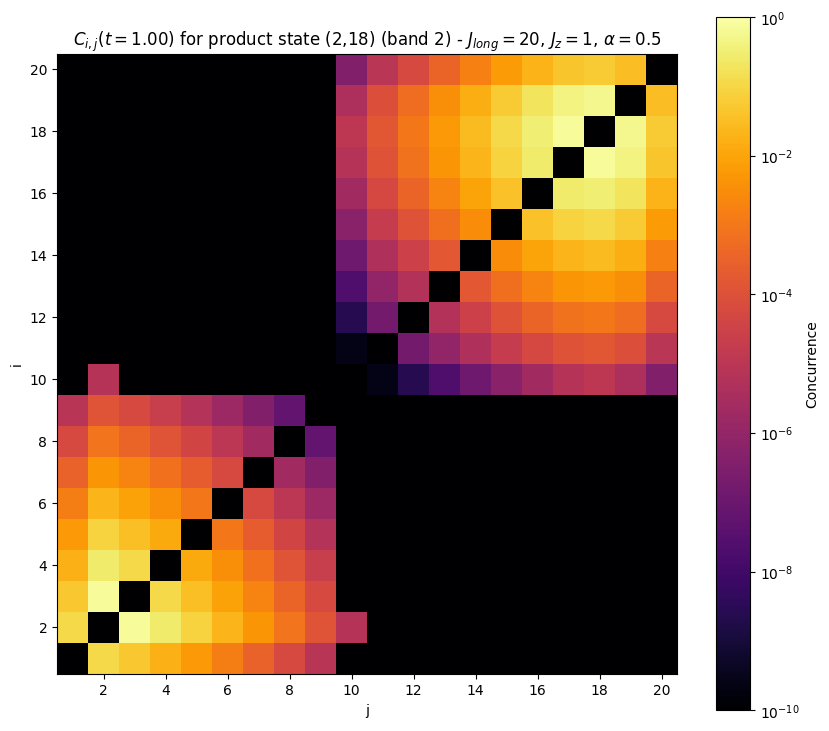

In [6]:
from collections import defaultdict

def group_by_time(data, tol=1e-12):
    times = sorted(set(t for t, _, _, _ in data))
    grouped = defaultdict(list)
    for t, p, j, rho in data:
        grouped[t].append((p, j, rho))
    return times, grouped

times, data_by_time = group_by_time(data)

times = [t for t in times if 0.0 <= t <= 1.0]

import matplotlib.animation as animation

vmin = 1e-10
vmax = 1.0   # keep fixed for ALL frames

fig, ax = plt.subplots(figsize=(10,9))

# initialize empty matrix
C0 = np.full((ns, ns), np.nan)

cmap = plt.cm.inferno.copy()
cmap.set_under("black")

im = ax.imshow(
    C0,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Concurrence")

ticks = np.arange(2, ns+1, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel("j")
ax.set_ylabel("i")

title = ax.set_title("")

# --------------------------------------------------
# Frame update function
# --------------------------------------------------
def update(frame):
    t = times[frame]
    C = np.zeros((ns, ns))

    for p, j, rho in data_by_time[t]:
        C[p, j] = concurrence(rho)

    C[C < vmin] = vmin   # force underflow → black
    im.set_data(C)
    title.set_text(rf"$C_{{i,j}}(t={t:.2f})$ for product state (2,18) (band 2) - $J_{{long}}=20$, $J_z=1$, $\alpha=0.5$")
    return im,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=60,   # ms between frames
    blit=True
)

from matplotlib.animation import PillowWriter
ani.save("concurrence_matrix.gif", writer=PillowWriter(fps=15))



alpha=0.5 band 1

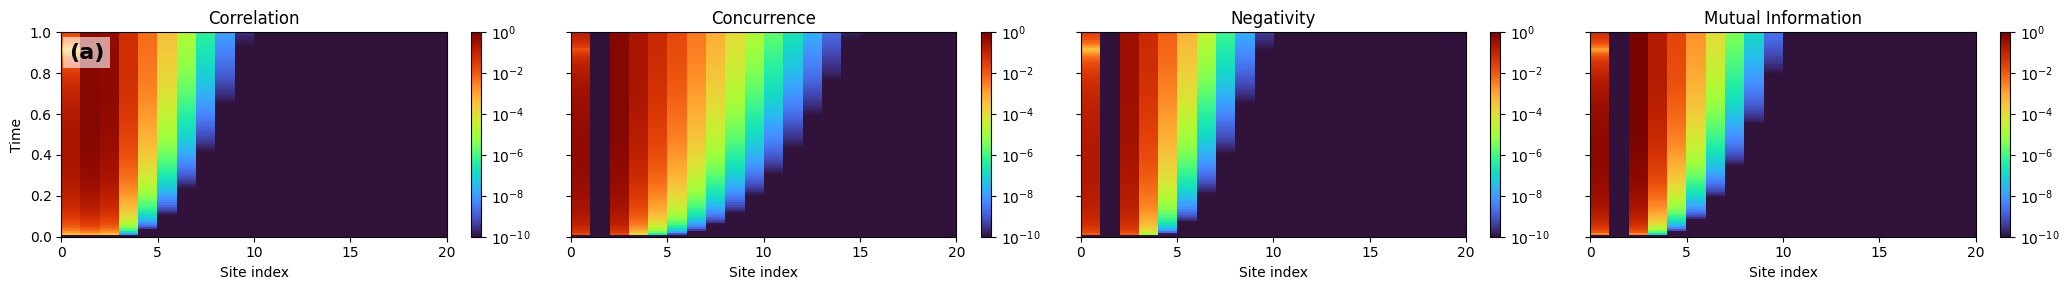

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    return max(0, evals[0] - evals[1] - evals[2] - evals[3])

# --------------------------------------------------
# Negativity computation
# --------------------------------------------------
def negativity(rho):
    # original indices: (iA, iB, jA, jB)
    #(0,1,2,3)
    rho_pt = rho.reshape(2,2,2,2).transpose(0,3,2,1).reshape(4,4)
    # indices: (iA, jB, jA, iB)
    #(0,3,2,1)
    # evals = np.linalg.eigvals(rho_pt)
    # return np.sum(np.abs(evals[evals < 0]))
    evals = np.linalg.eigvalsh(rho_pt)  # Hermitian solver
    return -np.sum(evals[evals < 0])


# --------------------------------------------------
# Von Neumann entropy
# --------------------------------------------------
def von_neumann_entropy(rho, eps=1e-12):
    evals = np.linalg.eigvalsh(rho)
    evals = np.clip(evals, eps, None)
    return -np.sum(evals * np.log2(evals))

# --------------------------------------------------
# Mutual information
# --------------------------------------------------
def mutual_information(rho):
    rho = rho / np.trace(rho)
    rhoA = np.trace(rho.reshape(2,2,2,2), axis1=1, axis2=3)
    rhoB = np.trace(rho.reshape(2,2,2,2), axis1=0, axis2=2)
    return (
        von_neumann_entropy(rhoA)
        + von_neumann_entropy(rhoB)
        - von_neumann_entropy(rho)
    )

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
configsArray = [51]#,31

t_max_plot = 1.0

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"

# panel letters: (a), (b), (c), ...
panel_letters = [f"({chr(97+i)})" for i in range(len(configsArray))]

for idx, config in enumerate(configsArray):

    ns = 20
    p_target = 1
    # if config == 30:
    #     p_target = 7
    # else:
    #     p_target = 1
    fnameC    = f"{base}{config}Concurrence.txt"
    fnameCorr = f"{base}{config}CorrelationFunction.txt"

    dataC    = np.loadtxt(fnameC)
    dataCorr = np.loadtxt(fnameCorr)

    # --------------------------------------------------
    # Correlation data
    # --------------------------------------------------
    times_corr = dataCorr[:,0]
    CorrMat = np.abs(dataCorr[:,1:ns+1])

    # --------------------------------------------------
    # Time axis (MASTER)
    # --------------------------------------------------
    uniq_times = np.unique(dataC[:,0])
    time_mask  = uniq_times <= t_max_plot
    plot_times = uniq_times[time_mask]
    t_min, t_max = plot_times.min(), plot_times.max()

    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    # --------------------------------------------------
    # Allocate matrices
    # --------------------------------------------------
    Cmat  = np.zeros((len(uniq_times), ns))
    Nmat  = np.zeros((len(uniq_times), ns))
    MImat = np.zeros((len(uniq_times), ns))

    # --------------------------------------------------
    # Fill matrices
    # --------------------------------------------------
    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)

        Cmat[k, j]  = concurrence(rho)
        Nmat[k, j]  = negativity(rho)
        MImat[k, j] = mutual_information(rho)

    # --------------------------------------------------
    # Apply SAME time cut to ALL matrices
    # --------------------------------------------------
    Cmat  = Cmat[time_mask, :]
    Nmat  = Nmat[time_mask, :]
    MImat = MImat[time_mask, :]

    corr_mask = times_corr <= t_max_plot
    CorrMat   = CorrMat[corr_mask, :]

    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------
    fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)
    extent = [0, ns, t_min, t_max]

    im1 = ax[0].imshow(np.clip(CorrMat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo", interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im2 = ax[1].imshow(np.clip(Cmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im3 = ax[2].imshow(np.clip(Nmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im4 = ax[3].imshow(np.clip(MImat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    x_ticks = np.arange(0, ns + 1, 5)

    for a in ax:
        a.set_xticks(x_ticks)
        a.set_xticklabels([f"{int(x)}" for x in x_ticks])

    ax[0].set_title("Correlation")
    ax[1].set_title("Concurrence")
    ax[2].set_title("Negativity")
    ax[3].set_title("Mutual Information")

    ax[0].set_ylabel("Time")
    for a in ax:
        a.set_xlabel("Site index")

    # --------------------------------------------------
    # SINGLE panel letter for the entire row
    # --------------------------------------------------
    ax[0].text(
        0.02, 0.95, panel_letters[idx],   # 👈 INSIDE the plot
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )


    for im, a in zip([im1, im2, im3, im4], ax):
        plt.colorbar(im, ax=a)

    # --------------------------------------------------
    # Suptitles (unchanged)
    # --------------------------------------------------
    if config == 50:
        plt.suptitle(r"Product state (2) (band 2) - $J_{long}=20$, $J_z=1$, $\alpha=0.5$", y=0.92)

    plt.tight_layout()
    plt.savefig(f"plt/Concurrence_Corr_Config2{config}.pdf", dpi=600)
    plt.show()


In [1]:
print("done")

done


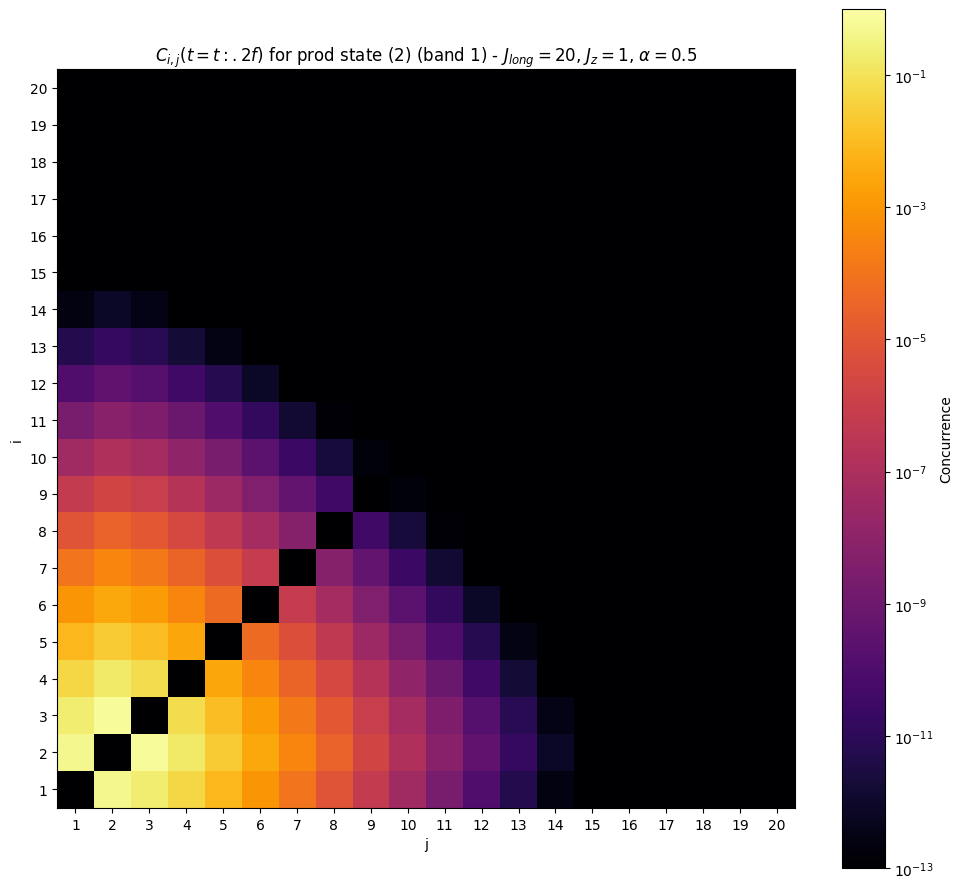

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def load_concurrence_file(fname):
    data = np.loadtxt(fname)

    out = []
    for row in data:
        t = row[0]
        p = int(row[1])
        j = int(row[2])

        rho_vals = row[4:]
        rho = rho_vals.reshape(4,4,2)
        rho = rho[:,:,0] + 1j*rho[:,:,1]

        out.append((t, p, j, rho))

    return out

def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    Y = np.kron(sy, sy)

    R = rho @ (Y @ rho.conj() @ Y)
    evals = np.real(np.linalg.eigvals(R))
    evals = np.maximum(evals, 0.0)
    evals = np.sort(np.sqrt(evals))[::-1]

    return max(0.0, evals[0] - evals[1] - evals[2] - evals[3])

def concurrence_matrix(data, t_target, ns, tol=1e-12):
    C = np.zeros((ns, ns))

    for t, p, j, rho in data:
        if abs(t - t_target) > tol:
            continue

        c = concurrence(rho)
        C[p, j] = c
        # C[j, p] = c   # symmetry

    return C

ns = 20
t0 = 0.5
base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"
fname = f"{base}51Concurrence.txt"
data = load_concurrence_file(fname)

C = concurrence_matrix(data, t0, ns)

# --------------------------------------------------
# PLOT
# --------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# --- threshold ---
vmin = 1e-13

# Copy & mask
C_plot = C.copy()
C_plot[C_plot < vmin] = vmin  # everything below threshold → underflow

# Colormap
cmap = plt.cm.inferno.copy()
cmap.set_under("black")          # 👈 hard black below vmin

plt.figure(figsize=(10,9))

im = plt.imshow(
    C_plot,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=1),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

plt.colorbar(im, label="Concurrence")

# Ticks at lattice sites
ticks = np.arange(1, ns+1, 1)
plt.xticks(ticks)
plt.yticks(ticks)

plt.xlabel("j")
plt.ylabel("i")
plt.title(r"$C_{{i,j}}(t={t:.2f})$ for prod state (2) (band 1) - $J_{{long}}=20$, $J_z=1$, $\alpha=0.5$")

plt.tight_layout()
plt.savefig(f"plt/ConcurrenceMatrix_{config}.pdf", dpi=600)
plt.show()



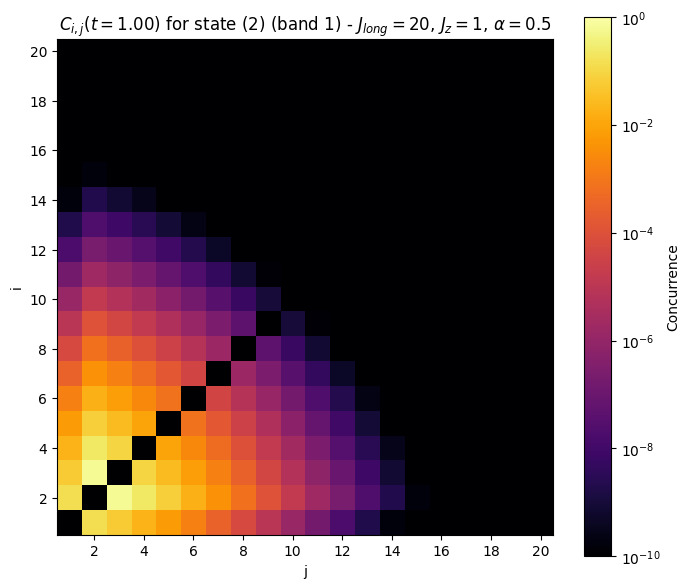

In [5]:
from collections import defaultdict

def group_by_time(data, tol=1e-12):
    times = sorted(set(t for t, _, _, _ in data))
    grouped = defaultdict(list)
    for t, p, j, rho in data:
        grouped[t].append((p, j, rho))
    return times, grouped

times, data_by_time = group_by_time(data)

times = [t for t in times if 0.0 <= t <= 1.0]

import matplotlib.animation as animation

vmin = 1e-10
vmax = 1.0   # keep fixed for ALL frames

fig, ax = plt.subplots(figsize=(8,7))

# initialize empty matrix
C0 = np.full((ns, ns), np.nan)

cmap = plt.cm.inferno.copy()
cmap.set_under("black")

im = ax.imshow(
    C0,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Concurrence")

ticks = np.arange(2, ns+1, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel("j")
ax.set_ylabel("i")

title = ax.set_title("")

# --------------------------------------------------
# Frame update function
# --------------------------------------------------
def update(frame):
    t = times[frame]
    C = np.zeros((ns, ns))

    for p, j, rho in data_by_time[t]:
        C[p, j] = concurrence(rho)

    C[C < vmin] = vmin   # force underflow → black
    im.set_data(C)
    title.set_text(rf"$C_{{i,j}}(t={t:.2f})$ for state (2) (band 1) - $J_{{long}}=20$, $J_z=1$, $\alpha=0.5$")
    return im,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=60,   # ms between frames
    blit=True
)

from matplotlib.animation import PillowWriter
ani.save("concurrence_matrix2.gif", writer=PillowWriter(fps=15))



Short range

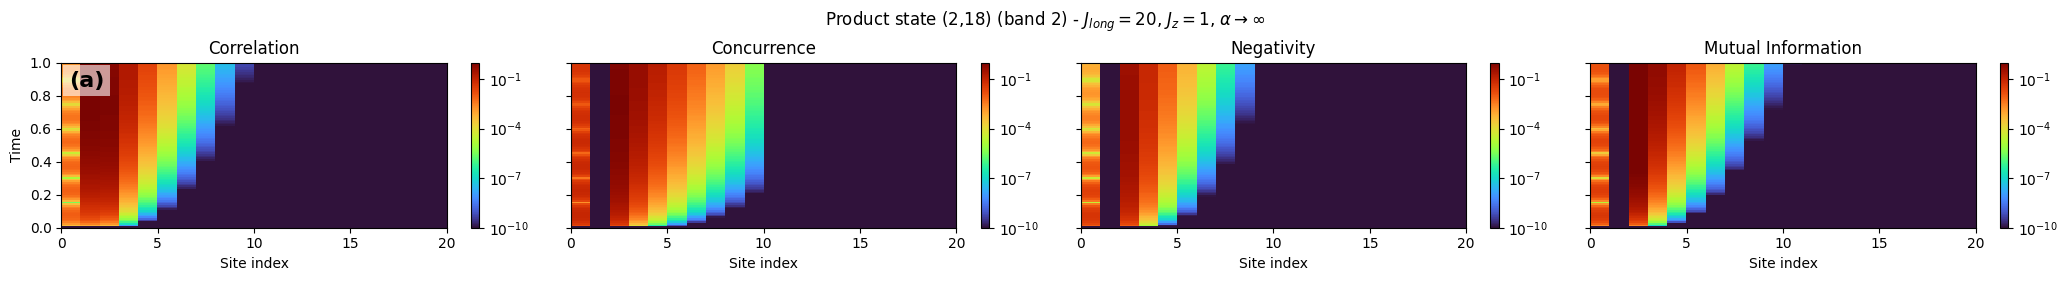

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    return max(0, evals[0] - evals[1] - evals[2] - evals[3])

# --------------------------------------------------
# Negativity computation
# --------------------------------------------------
def negativity(rho):
    # original indices: (iA, iB, jA, jB)
    #(0,1,2,3)
    rho_pt = rho.reshape(2,2,2,2).transpose(0,3,2,1).reshape(4,4)
    # indices: (iA, jB, jA, iB)
    #(0,3,2,1)
    # evals = np.linalg.eigvals(rho_pt)
    # return np.sum(np.abs(evals[evals < 0]))
    evals = np.linalg.eigvalsh(rho_pt)  # Hermitian solver
    return -np.sum(evals[evals < 0])


# --------------------------------------------------
# Von Neumann entropy
# --------------------------------------------------
def von_neumann_entropy(rho, eps=1e-12):
    evals = np.linalg.eigvalsh(rho)
    evals = np.clip(evals, eps, None)
    return -np.sum(evals * np.log2(evals))

# --------------------------------------------------
# Mutual information
# --------------------------------------------------
def mutual_information(rho):
    rho = rho / np.trace(rho)
    rhoA = np.trace(rho.reshape(2,2,2,2), axis1=1, axis2=3)
    rhoB = np.trace(rho.reshape(2,2,2,2), axis1=0, axis2=2)
    return (
        von_neumann_entropy(rhoA)
        + von_neumann_entropy(rhoB)
        - von_neumann_entropy(rho)
    )

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
configsArray = [52]#,31

t_max_plot = 1.0

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"

# panel letters: (a), (b), (c), ...
panel_letters = [f"({chr(97+i)})" for i in range(len(configsArray))]

for idx, config in enumerate(configsArray):

    ns = 20
    p_target = 1
    # if config == 30:
    #     p_target = 7
    # else:
    #     p_target = 1
    fnameC    = f"{base}{config}Concurrence.txt"
    fnameCorr = f"{base}{config}CorrelationFunction.txt"

    dataC    = np.loadtxt(fnameC)
    dataCorr = np.loadtxt(fnameCorr)

    # --------------------------------------------------
    # Correlation data
    # --------------------------------------------------
    times_corr = dataCorr[:,0]
    CorrMat = np.abs(dataCorr[:,1:ns+1])

    # --------------------------------------------------
    # Time axis (MASTER)
    # --------------------------------------------------
    uniq_times = np.unique(dataC[:,0])
    time_mask  = uniq_times <= t_max_plot
    plot_times = uniq_times[time_mask]
    t_min, t_max = plot_times.min(), plot_times.max()

    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    # --------------------------------------------------
    # Allocate matrices
    # --------------------------------------------------
    Cmat  = np.zeros((len(uniq_times), ns))
    Nmat  = np.zeros((len(uniq_times), ns))
    MImat = np.zeros((len(uniq_times), ns))

    # --------------------------------------------------
    # Fill matrices
    # --------------------------------------------------
    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)

        Cmat[k, j]  = concurrence(rho)
        Nmat[k, j]  = negativity(rho)
        MImat[k, j] = mutual_information(rho)

    # --------------------------------------------------
    # Apply SAME time cut to ALL matrices
    # --------------------------------------------------
    Cmat  = Cmat[time_mask, :]
    Nmat  = Nmat[time_mask, :]
    MImat = MImat[time_mask, :]

    corr_mask = times_corr <= t_max_plot
    CorrMat   = CorrMat[corr_mask, :]

    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------
    fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)
    extent = [0, ns, t_min, t_max]

    im1 = ax[0].imshow(np.clip(CorrMat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo", interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im2 = ax[1].imshow(np.clip(Cmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im3 = ax[2].imshow(np.clip(Nmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im4 = ax[3].imshow(np.clip(MImat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    x_ticks = np.arange(0, ns + 1, 5)

    for a in ax:
        a.set_xticks(x_ticks)
        a.set_xticklabels([f"{int(x)}" for x in x_ticks])

    ax[0].set_title("Correlation")
    ax[1].set_title("Concurrence")
    ax[2].set_title("Negativity")
    ax[3].set_title("Mutual Information")

    ax[0].set_ylabel("Time")
    for a in ax:
        a.set_xlabel("Site index")

    # --------------------------------------------------
    # SINGLE panel letter for the entire row
    # --------------------------------------------------
    ax[0].text(
        0.02, 0.95, panel_letters[idx],   # 👈 INSIDE the plot
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )


    for im, a in zip([im1, im2, im3, im4], ax):
        plt.colorbar(im, ax=a)

    # --------------------------------------------------
    # Suptitles (unchanged)
    # --------------------------------------------------
    if config == 52:
        plt.suptitle(r"Product state (2,18) (band 2) - $J_{long}=20$, $J_z=1$, $\alpha\to\infty$", y=0.92)

    plt.tight_layout()
    plt.savefig(f"plt/Concurrence_Corr_Config{config}.pdf", dpi=600)
    plt.show()


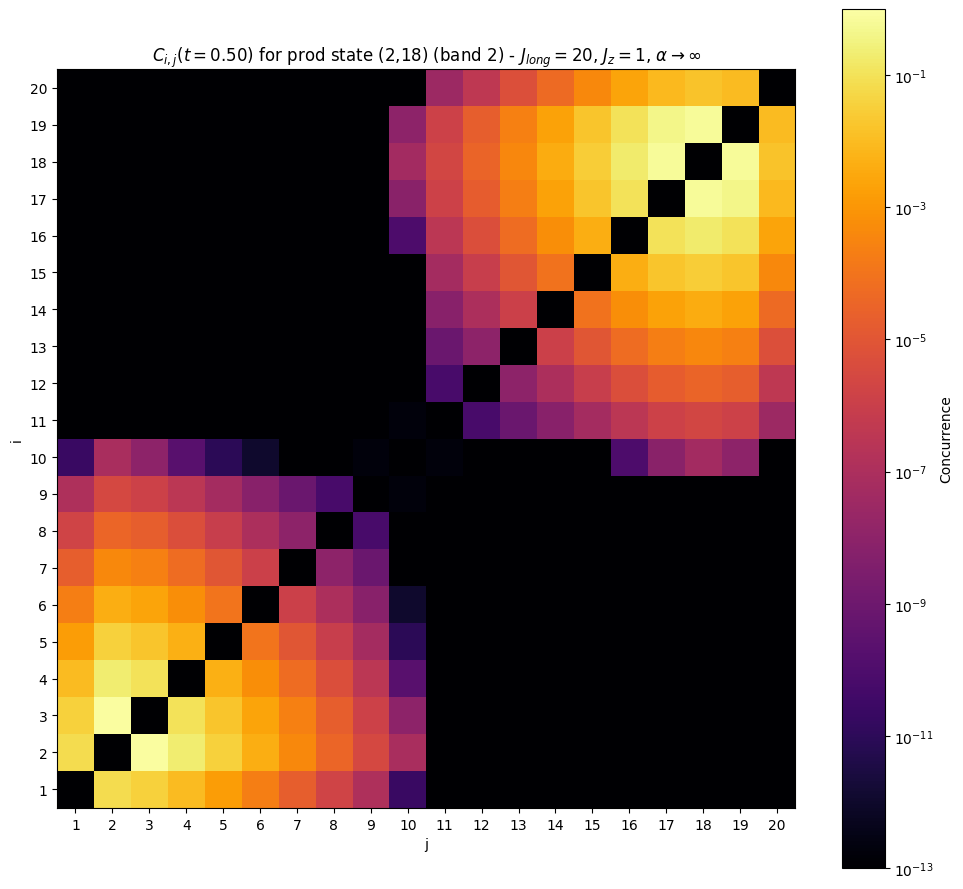

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def load_concurrence_file(fname):
    data = np.loadtxt(fname)

    out = []
    for row in data:
        t = row[0]
        p = int(row[1])
        j = int(row[2])

        rho_vals = row[4:]
        rho = rho_vals.reshape(4,4,2)
        rho = rho[:,:,0] + 1j*rho[:,:,1]

        out.append((t, p, j, rho))

    return out

def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    Y = np.kron(sy, sy)

    R = rho @ (Y @ rho.conj() @ Y)
    evals = np.real(np.linalg.eigvals(R))
    evals = np.maximum(evals, 0.0)
    evals = np.sort(np.sqrt(evals))[::-1]

    return max(0.0, evals[0] - evals[1] - evals[2] - evals[3])

def concurrence_matrix(data, t_target, ns, tol=1e-12):
    C = np.zeros((ns, ns))

    for t, p, j, rho in data:
        if abs(t - t_target) > tol:
            continue

        c = concurrence(rho)
        C[p, j] = c
        # C[j, p] = c   # symmetry

    return C

ns = 20
t0 = 0.5
base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"
fname = f"{base}52Concurrence.txt"
data = load_concurrence_file(fname)

C = concurrence_matrix(data, t0, ns)

# --------------------------------------------------
# PLOT
# --------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# --- threshold ---
vmin = 1e-13

# Copy & mask
C_plot = C.copy()
C_plot[C_plot < vmin] = vmin  # everything below threshold → underflow

# Colormap
cmap = plt.cm.inferno.copy()
cmap.set_under("black")          # 👈 hard black below vmin

plt.figure(figsize=(10,9))

im = plt.imshow(
    C_plot,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=1),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

plt.colorbar(im, label="Concurrence")

# Ticks at lattice sites
ticks = np.arange(1, ns+1, 1)
plt.xticks(ticks)
plt.yticks(ticks)

plt.xlabel("j")
plt.ylabel("i")
plt.title(rf"$C_{{i,j}}(t={t0:.2f})$ for prod state (2,18) (band 2) - $J_{{long}}=20$, $J_z=1$, $\alpha\to\infty$")

plt.tight_layout()
plt.savefig(f"plt/ConcurrenceMatrix_{config}.pdf", dpi=600)
plt.show()



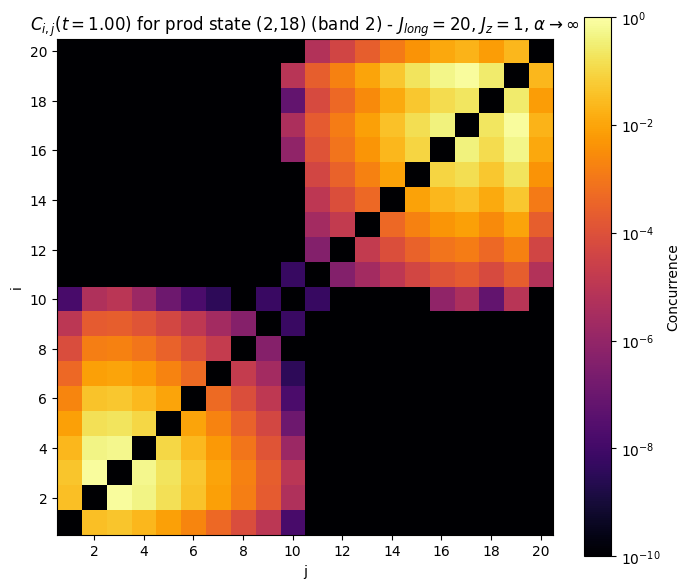

In [10]:
from collections import defaultdict

def group_by_time(data, tol=1e-12):
    times = sorted(set(t for t, _, _, _ in data))
    grouped = defaultdict(list)
    for t, p, j, rho in data:
        grouped[t].append((p, j, rho))
    return times, grouped

times, data_by_time = group_by_time(data)

times = [t for t in times if 0.0 <= t <= 1.0]

import matplotlib.animation as animation

vmin = 1e-10
vmax = 1.0   # keep fixed for ALL frames

fig, ax = plt.subplots(figsize=(8,7))

# initialize empty matrix
C0 = np.full((ns, ns), np.nan)

cmap = plt.cm.inferno.copy()
cmap.set_under("black")

im = ax.imshow(
    C0,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Concurrence")

ticks = np.arange(2, ns+1, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel("j")
ax.set_ylabel("i")

title = ax.set_title("")

# --------------------------------------------------
# Frame update function
# --------------------------------------------------
def update(frame):
    t = times[frame]
    C = np.zeros((ns, ns))

    for p, j, rho in data_by_time[t]:
        C[p, j] = concurrence(rho)

    C[C < vmin] = vmin   # force underflow → black
    im.set_data(C)
    title.set_text(rf"$C_{{i,j}}(t={t:.2f})$ for prod state (2,18) (band 2) - $J_{{long}}=20$, $J_z=1$, $\alpha\to\infty$")
    return im,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=60,   # ms between frames
    blit=True
)

from matplotlib.animation import PillowWriter
ani.save("concurrence_matrix3.gif", writer=PillowWriter(fps=15))



Short range 2,8, Full Hamiltonian

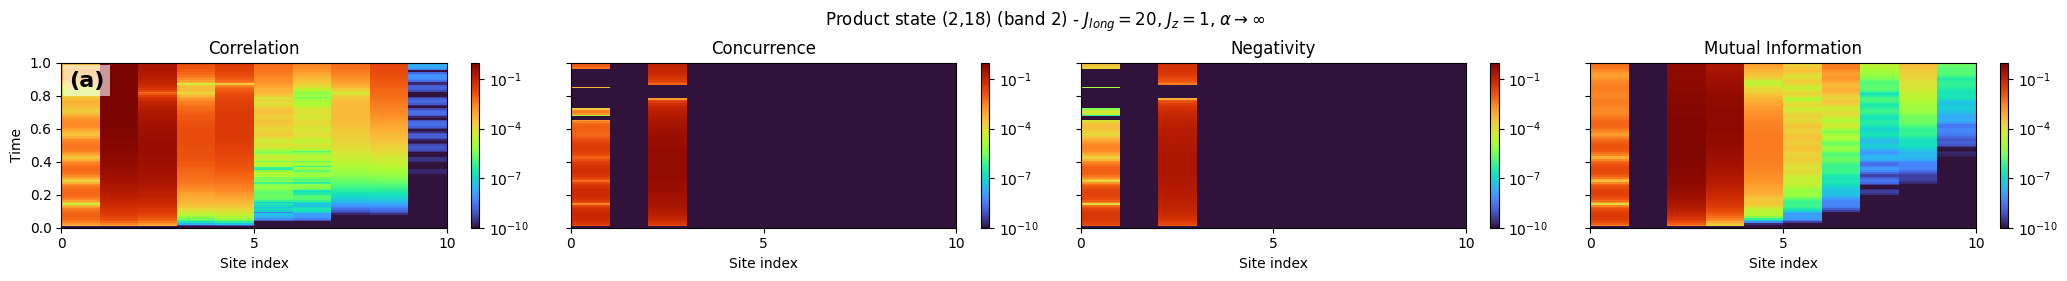

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    return max(0, evals[0] - evals[1] - evals[2] - evals[3])

# --------------------------------------------------
# Negativity computation
# --------------------------------------------------
def negativity(rho):
    # original indices: (iA, iB, jA, jB)
    #(0,1,2,3)
    rho_pt = rho.reshape(2,2,2,2).transpose(0,3,2,1).reshape(4,4)
    # indices: (iA, jB, jA, iB)
    #(0,3,2,1)
    # evals = np.linalg.eigvals(rho_pt)
    # return np.sum(np.abs(evals[evals < 0]))
    evals = np.linalg.eigvalsh(rho_pt)  # Hermitian solver
    return -np.sum(evals[evals < 0])


# --------------------------------------------------
# Von Neumann entropy
# --------------------------------------------------
def von_neumann_entropy(rho, eps=1e-12):
    evals = np.linalg.eigvalsh(rho)
    evals = np.clip(evals, eps, None)
    return -np.sum(evals * np.log2(evals))

# --------------------------------------------------
# Mutual information
# --------------------------------------------------
def mutual_information(rho):
    rho = rho / np.trace(rho)
    rhoA = np.trace(rho.reshape(2,2,2,2), axis1=1, axis2=3)
    rhoB = np.trace(rho.reshape(2,2,2,2), axis1=0, axis2=2)
    return (
        von_neumann_entropy(rhoA)
        + von_neumann_entropy(rhoB)
        - von_neumann_entropy(rho)
    )

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
configsArray = [60]#,31

t_max_plot = 1.0

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"

# panel letters: (a), (b), (c), ...
panel_letters = [f"({chr(97+i)})" for i in range(len(configsArray))]

for idx, config in enumerate(configsArray):

    ns = 10
    p_target = 1
    # if config == 30:
    #     p_target = 7
    # else:
    #     p_target = 1
    fnameC    = f"{base}{config}Concurrence.txt"
    fnameCorr = f"{base}{config}CorrelationFunction.txt"

    dataC    = np.loadtxt(fnameC)
    dataCorr = np.loadtxt(fnameCorr)

    # --------------------------------------------------
    # Correlation data
    # --------------------------------------------------
    times_corr = dataCorr[:,0]
    CorrMat = np.abs(dataCorr[:,1:ns+1])

    # --------------------------------------------------
    # Time axis (MASTER)
    # --------------------------------------------------
    uniq_times = np.unique(dataC[:,0])
    time_mask  = uniq_times <= t_max_plot
    plot_times = uniq_times[time_mask]
    t_min, t_max = plot_times.min(), plot_times.max()

    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    # --------------------------------------------------
    # Allocate matrices
    # --------------------------------------------------
    Cmat  = np.zeros((len(uniq_times), ns))
    Nmat  = np.zeros((len(uniq_times), ns))
    MImat = np.zeros((len(uniq_times), ns))

    # --------------------------------------------------
    # Fill matrices
    # --------------------------------------------------
    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)

        Cmat[k, j]  = concurrence(rho)
        Nmat[k, j]  = negativity(rho)
        MImat[k, j] = mutual_information(rho)

    # --------------------------------------------------
    # Apply SAME time cut to ALL matrices
    # --------------------------------------------------
    Cmat  = Cmat[time_mask, :]
    Nmat  = Nmat[time_mask, :]
    MImat = MImat[time_mask, :]

    corr_mask = times_corr <= t_max_plot
    CorrMat   = CorrMat[corr_mask, :]

    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------
    fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)
    extent = [0, ns, t_min, t_max]

    im1 = ax[0].imshow(np.clip(CorrMat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo", interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im2 = ax[1].imshow(np.clip(Cmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im3 = ax[2].imshow(np.clip(Nmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im4 = ax[3].imshow(np.clip(MImat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    x_ticks = np.arange(0, ns + 1, 5)

    for a in ax:
        a.set_xticks(x_ticks)
        a.set_xticklabels([f"{int(x)}" for x in x_ticks])

    ax[0].set_title("Correlation")
    ax[1].set_title("Concurrence")
    ax[2].set_title("Negativity")
    ax[3].set_title("Mutual Information")

    ax[0].set_ylabel("Time")
    for a in ax:
        a.set_xlabel("Site index")

    # --------------------------------------------------
    # SINGLE panel letter for the entire row
    # --------------------------------------------------
    ax[0].text(
        0.02, 0.95, panel_letters[idx],   # 👈 INSIDE the plot
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )


    for im, a in zip([im1, im2, im3, im4], ax):
        plt.colorbar(im, ax=a)

    # --------------------------------------------------
    # Suptitles (unchanged)
    # --------------------------------------------------
    if config == 60:
        plt.suptitle(r"Product state (2,18) (band 2) - $J_{long}=20$, $J_z=1$, $\alpha\to\infty$", y=0.92)

    plt.tight_layout()
    plt.savefig(f"plt/Concurrence_Corr_Config{config}.pdf", dpi=600)
    plt.show()


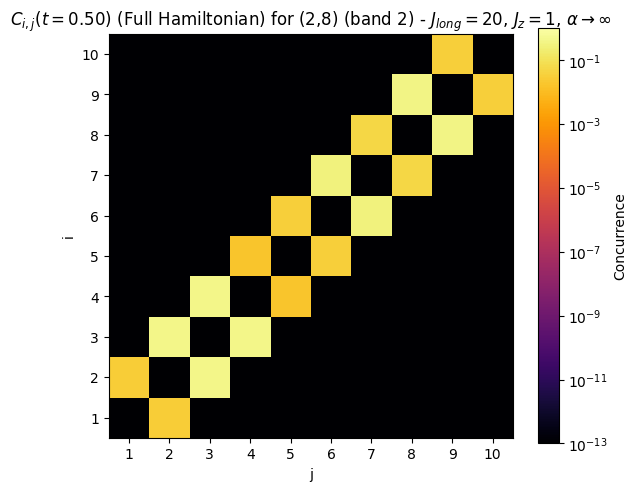

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def load_concurrence_file(fname):
    data = np.loadtxt(fname)

    out = []
    for row in data:
        t = row[0]
        p = int(row[1])
        j = int(row[2])

        rho_vals = row[4:]
        rho = rho_vals.reshape(4,4,2)
        rho = rho[:,:,0] + 1j*rho[:,:,1]

        out.append((t, p, j, rho))

    return out

def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    Y = np.kron(sy, sy)

    R = rho @ (Y @ rho.conj() @ Y)
    evals = np.real(np.linalg.eigvals(R))
    evals = np.maximum(evals, 0.0)
    evals = np.sort(np.sqrt(evals))[::-1]

    return max(0.0, evals[0] - evals[1] - evals[2] - evals[3])

def concurrence_matrix(data, t_target, ns, tol=1e-12):
    C = np.zeros((ns, ns))

    for t, p, j, rho in data:
        if abs(t - t_target) > tol:
            continue

        c = concurrence(rho)
        C[p, j] = c
        # C[j, p] = c   # symmetry

    return C

ns = 10
t0 = 0.5
base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"
fname = f"{base}60Concurrence.txt"
data = load_concurrence_file(fname)

C = concurrence_matrix(data, t0, ns)

# --------------------------------------------------
# PLOT
# --------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# --- threshold ---
vmin = 1e-13

# Copy & mask
C_plot = C.copy()
C_plot[C_plot < vmin] = vmin  # everything below threshold → underflow

# Colormap
cmap = plt.cm.inferno.copy()
cmap.set_under("black")          # 👈 hard black below vmin

plt.figure(figsize=(6,5))

im = plt.imshow(
    C_plot,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=1),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

plt.colorbar(im, label="Concurrence")

# Ticks at lattice sites
ticks = np.arange(1, ns+1, 1)
plt.xticks(ticks)
plt.yticks(ticks)

plt.xlabel("j")
plt.ylabel("i")
plt.title(rf"$C_{{i,j}}(t={t0:.2f})$ (Full Hamiltonian) for (2,8) (band 2) - $J_{{long}}=20$, $J_z=1$, $\alpha\to\infty$")
plt.savefig(f"plt/ConcurrenceMatrix_FullH_{config}.pdf", dpi=600)
plt.tight_layout()
plt.show()



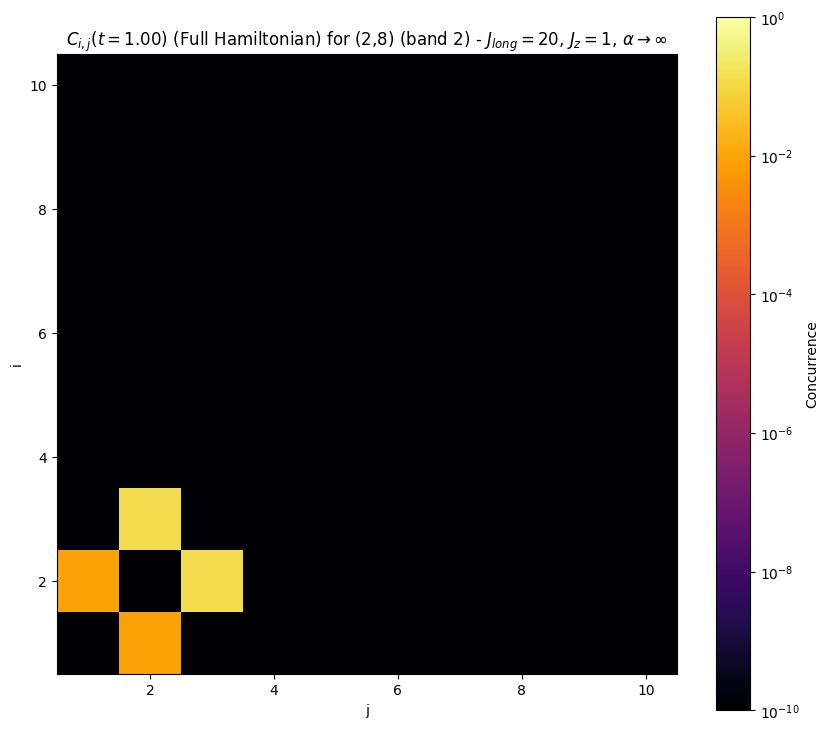

In [13]:
from collections import defaultdict

def group_by_time(data, tol=1e-12):
    times = sorted(set(t for t, _, _, _ in data))
    grouped = defaultdict(list)
    for t, p, j, rho in data:
        grouped[t].append((p, j, rho))
    return times, grouped

times, data_by_time = group_by_time(data)

times = [t for t in times if 0.0 <= t <= 1.0]

import matplotlib.animation as animation

vmin = 1e-10
vmax = 1.0   # keep fixed for ALL frames

fig, ax = plt.subplots(figsize=(10,9))

# initialize empty matrix
C0 = np.full((ns, ns), np.nan)

cmap = plt.cm.inferno.copy()
cmap.set_under("black")

im = ax.imshow(
    C0,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Concurrence")

ticks = np.arange(2, ns+1, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel("j")
ax.set_ylabel("i")

title = ax.set_title("")

# --------------------------------------------------
# Frame update function
# --------------------------------------------------
def update(frame):
    t = times[frame]
    C = np.zeros((ns, ns))

    for p, j, rho in data_by_time[t]:
        C[p, j] = concurrence(rho)

    C[C < vmin] = vmin   # force underflow → black
    im.set_data(C)
    title.set_text(rf"$C_{{i,j}}(t={t:.2f})$ (Full Hamiltonian) for (2,8) (band 2) - $J_{{long}}=20$, $J_z=1$, $\alpha\to\infty$")
    return im,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=60,   # ms between frames
    blit=True
)

from matplotlib.animation import PillowWriter
ani.save("concurrence_matrix4.gif", writer=PillowWriter(fps=15))



Long range 2,8, Full Hamiltonian

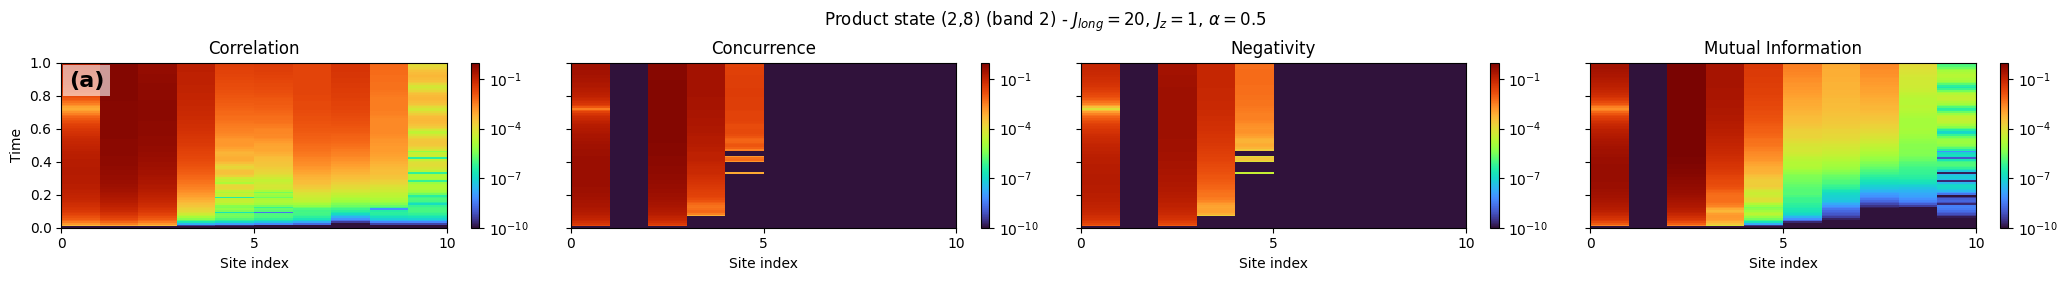

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    return max(0, evals[0] - evals[1] - evals[2] - evals[3])

# --------------------------------------------------
# Negativity computation
# --------------------------------------------------
def negativity(rho):
    # original indices: (iA, iB, jA, jB)
    #(0,1,2,3)
    rho_pt = rho.reshape(2,2,2,2).transpose(0,3,2,1).reshape(4,4)
    # indices: (iA, jB, jA, iB)
    #(0,3,2,1)
    # evals = np.linalg.eigvals(rho_pt)
    # return np.sum(np.abs(evals[evals < 0]))
    evals = np.linalg.eigvalsh(rho_pt)  # Hermitian solver
    return -np.sum(evals[evals < 0])


# --------------------------------------------------
# Von Neumann entropy
# --------------------------------------------------
def von_neumann_entropy(rho, eps=1e-12):
    evals = np.linalg.eigvalsh(rho)
    evals = np.clip(evals, eps, None)
    return -np.sum(evals * np.log2(evals))

# --------------------------------------------------
# Mutual information
# --------------------------------------------------
def mutual_information(rho):
    rho = rho / np.trace(rho)
    rhoA = np.trace(rho.reshape(2,2,2,2), axis1=1, axis2=3)
    rhoB = np.trace(rho.reshape(2,2,2,2), axis1=0, axis2=2)
    return (
        von_neumann_entropy(rhoA)
        + von_neumann_entropy(rhoB)
        - von_neumann_entropy(rho)
    )

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
configsArray = [61]#,31

t_max_plot = 1.0

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"

# panel letters: (a), (b), (c), ...
panel_letters = [f"({chr(97+i)})" for i in range(len(configsArray))]

for idx, config in enumerate(configsArray):

    ns = 10
    p_target = 1
    # if config == 30:
    #     p_target = 7
    # else:
    #     p_target = 1
    fnameC    = f"{base}{config}Concurrence.txt"
    fnameCorr = f"{base}{config}CorrelationFunction.txt"

    dataC    = np.loadtxt(fnameC)
    dataCorr = np.loadtxt(fnameCorr)

    # --------------------------------------------------
    # Correlation data
    # --------------------------------------------------
    times_corr = dataCorr[:,0]
    CorrMat = np.abs(dataCorr[:,1:ns+1])

    # --------------------------------------------------
    # Time axis (MASTER)
    # --------------------------------------------------
    uniq_times = np.unique(dataC[:,0])
    time_mask  = uniq_times <= t_max_plot
    plot_times = uniq_times[time_mask]
    t_min, t_max = plot_times.min(), plot_times.max()

    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    # --------------------------------------------------
    # Allocate matrices
    # --------------------------------------------------
    Cmat  = np.zeros((len(uniq_times), ns))
    Nmat  = np.zeros((len(uniq_times), ns))
    MImat = np.zeros((len(uniq_times), ns))

    # --------------------------------------------------
    # Fill matrices
    # --------------------------------------------------
    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)

        Cmat[k, j]  = concurrence(rho)
        Nmat[k, j]  = negativity(rho)
        MImat[k, j] = mutual_information(rho)

    # --------------------------------------------------
    # Apply SAME time cut to ALL matrices
    # --------------------------------------------------
    Cmat  = Cmat[time_mask, :]
    Nmat  = Nmat[time_mask, :]
    MImat = MImat[time_mask, :]

    corr_mask = times_corr <= t_max_plot
    CorrMat   = CorrMat[corr_mask, :]

    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------
    fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)
    extent = [0, ns, t_min, t_max]

    im1 = ax[0].imshow(np.clip(CorrMat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo", interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im2 = ax[1].imshow(np.clip(Cmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im3 = ax[2].imshow(np.clip(Nmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im4 = ax[3].imshow(np.clip(MImat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    x_ticks = np.arange(0, ns + 1, 5)

    for a in ax:
        a.set_xticks(x_ticks)
        a.set_xticklabels([f"{int(x)}" for x in x_ticks])

    ax[0].set_title("Correlation")
    ax[1].set_title("Concurrence")
    ax[2].set_title("Negativity")
    ax[3].set_title("Mutual Information")

    ax[0].set_ylabel("Time")
    for a in ax:
        a.set_xlabel("Site index")

    # --------------------------------------------------
    # SINGLE panel letter for the entire row
    # --------------------------------------------------
    ax[0].text(
        0.02, 0.95, panel_letters[idx],   # 👈 INSIDE the plot
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )


    for im, a in zip([im1, im2, im3, im4], ax):
        plt.colorbar(im, ax=a)

    # --------------------------------------------------
    # Suptitles (unchanged)
    # --------------------------------------------------
    if config == 61:
        plt.suptitle(r"Product state (2,8) (band 2) - $J_{long}=20$, $J_z=1$, $\alpha=0.5$", y=0.92)

    plt.tight_layout()
    plt.savefig(f"plt/Concurrence_Corr_Config{config}.pdf", dpi=600)
    plt.show()


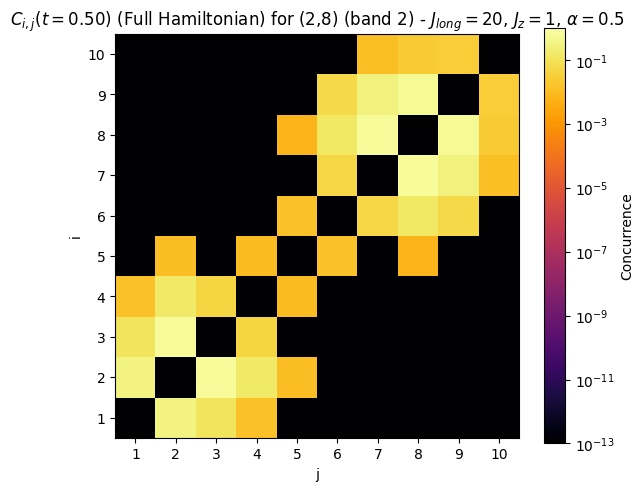

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def load_concurrence_file(fname):
    data = np.loadtxt(fname)

    out = []
    for row in data:
        t = row[0]
        p = int(row[1])
        j = int(row[2])

        rho_vals = row[4:]
        rho = rho_vals.reshape(4,4,2)
        rho = rho[:,:,0] + 1j*rho[:,:,1]

        out.append((t, p, j, rho))

    return out

def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    Y = np.kron(sy, sy)

    R = rho @ (Y @ rho.conj() @ Y)
    evals = np.real(np.linalg.eigvals(R))
    evals = np.maximum(evals, 0.0)
    evals = np.sort(np.sqrt(evals))[::-1]

    return max(0.0, evals[0] - evals[1] - evals[2] - evals[3])

def concurrence_matrix(data, t_target, ns, tol=1e-12):
    C = np.zeros((ns, ns))

    for t, p, j, rho in data:
        if abs(t - t_target) > tol:
            continue

        c = concurrence(rho)
        C[p, j] = c
        # C[j, p] = c   # symmetry

    return C

ns = 10
t0 = 0.5
base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"
fname = f"{base}61Concurrence.txt"
data = load_concurrence_file(fname)

C = concurrence_matrix(data, t0, ns)

# --------------------------------------------------
# PLOT
# --------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# --- threshold ---
vmin = 1e-13

# Copy & mask
C_plot = C.copy()
C_plot[C_plot < vmin] = vmin  # everything below threshold → underflow

# Colormap
cmap = plt.cm.inferno.copy()
cmap.set_under("black")          # 👈 hard black below vmin

plt.figure(figsize=(6,5))

im = plt.imshow(
    C_plot,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=1),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

plt.colorbar(im, label="Concurrence")

# Ticks at lattice sites
ticks = np.arange(1, ns+1, 1)
plt.xticks(ticks)
plt.yticks(ticks)

plt.xlabel("j")
plt.ylabel("i")
plt.title(rf"$C_{{i,j}}(t={t0:.2f})$ (Full Hamiltonian) for (2,8) (band 2) - $J_{{long}}=20$, $J_z=1$, $\alpha=0.5$")
plt.savefig(f"plt/ConcurrenceMatrix_FullH_{config}.pdf", dpi=600)
plt.tight_layout()
plt.show()



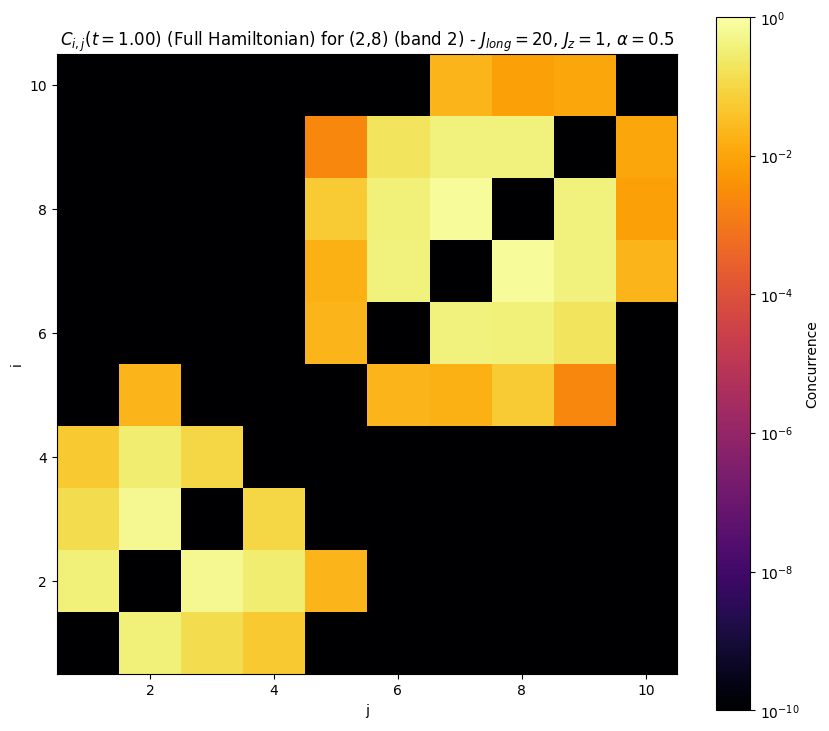

In [16]:
from collections import defaultdict

def group_by_time(data, tol=1e-12):
    times = sorted(set(t for t, _, _, _ in data))
    grouped = defaultdict(list)
    for t, p, j, rho in data:
        grouped[t].append((p, j, rho))
    return times, grouped

times, data_by_time = group_by_time(data)

times = [t for t in times if 0.0 <= t <= 1.0]

import matplotlib.animation as animation

vmin = 1e-10
vmax = 1.0   # keep fixed for ALL frames

fig, ax = plt.subplots(figsize=(10,9))

# initialize empty matrix
C0 = np.full((ns, ns), np.nan)

cmap = plt.cm.inferno.copy()
cmap.set_under("black")

im = ax.imshow(
    C0,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Concurrence")

ticks = np.arange(2, ns+1, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel("j")
ax.set_ylabel("i")

title = ax.set_title("")

# --------------------------------------------------
# Frame update function
# --------------------------------------------------
def update(frame):
    t = times[frame]
    C = np.zeros((ns, ns))

    for p, j, rho in data_by_time[t]:
        C[p, j] = concurrence(rho)

    C[C < vmin] = vmin   # force underflow → black
    im.set_data(C)
    title.set_text(rf"$C_{{i,j}}(t={t:.2f})$ (Full Hamiltonian) for (2,8) (band 2) - $J_{{long}}=20$, $J_z=1$, $\alpha=0.5$")
    return im,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=60,   # ms between frames
    blit=True
)

from matplotlib.animation import PillowWriter
ani.save("concurrence_matrix5.gif", writer=PillowWriter(fps=15))



long range band 1 (2)

C:\Users\shrey\AppData\Local\Temp\ipykernel_13440\737934450.py:87: ConversionWarning: Some errors were detected !
    Line #994 (got 10 columns instead of 11)
  dataCorr = np.genfromtxt(fnameCorr, filling_values=np.nan, invalid_raise=False)


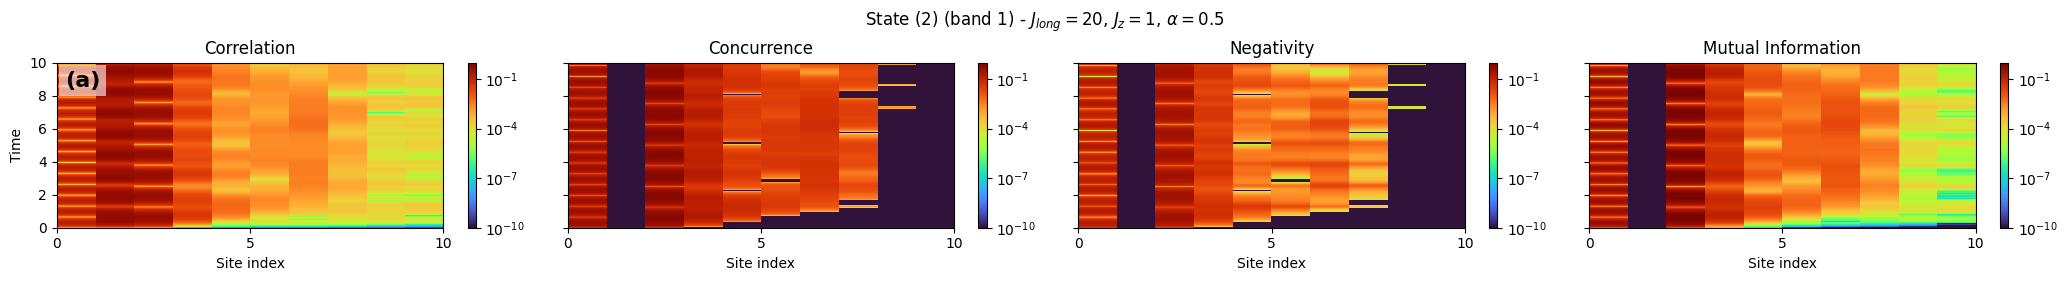

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    return max(0, evals[0] - evals[1] - evals[2] - evals[3])

# --------------------------------------------------
# Negativity computation
# --------------------------------------------------
def negativity(rho):
    # original indices: (iA, iB, jA, jB)
    #(0,1,2,3)
    rho_pt = rho.reshape(2,2,2,2).transpose(0,3,2,1).reshape(4,4)
    # indices: (iA, jB, jA, iB)
    #(0,3,2,1)
    # evals = np.linalg.eigvals(rho_pt)
    # return np.sum(np.abs(evals[evals < 0]))
    evals = np.linalg.eigvalsh(rho_pt)  # Hermitian solver
    return -np.sum(evals[evals < 0])


# --------------------------------------------------
# Von Neumann entropy
# --------------------------------------------------
def von_neumann_entropy(rho, eps=1e-12):
    evals = np.linalg.eigvalsh(rho)
    evals = np.clip(evals, eps, None)
    return -np.sum(evals * np.log2(evals))

# --------------------------------------------------
# Mutual information
# --------------------------------------------------
def mutual_information(rho):
    rho = rho / np.trace(rho)
    rhoA = np.trace(rho.reshape(2,2,2,2), axis1=1, axis2=3)
    rhoB = np.trace(rho.reshape(2,2,2,2), axis1=0, axis2=2)
    return (
        von_neumann_entropy(rhoA)
        + von_neumann_entropy(rhoB)
        - von_neumann_entropy(rho)
    )

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
configsArray = [62]#,31

t_max_plot = 99

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"

# panel letters: (a), (b), (c), ...
panel_letters = [f"({chr(97+i)})" for i in range(len(configsArray))]

for idx, config in enumerate(configsArray):

    ns = 10
    p_target = 1
    # if config == 30:
    #     p_target = 7
    # else:
    #     p_target = 1
    fnameC    = f"{base}{config}Concurrence.txt"
    fnameCorr = f"{base}{config}CorrelationFunction.txt"

    dataC    = np.loadtxt(fnameC)

    # --- load correlation file safely ---
    dataCorr = np.genfromtxt(fnameCorr, filling_values=np.nan, invalid_raise=False)
    dataCorr = dataCorr[~np.isnan(dataCorr).any(axis=1)]


    # --------------------------------------------------
    # Correlation data
    # --------------------------------------------------
    times_corr = dataCorr[:,0]
    CorrMat = np.abs(dataCorr[:,1:ns+1])

    # --------------------------------------------------
    # Time axis (MASTER)
    # --------------------------------------------------
    uniq_times = np.unique(dataC[:,0])
    time_mask  = uniq_times <= t_max_plot
    plot_times = uniq_times[time_mask]
    t_min, t_max = plot_times.min(), plot_times.max()

    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    # --------------------------------------------------
    # Allocate matrices
    # --------------------------------------------------
    Cmat  = np.zeros((len(uniq_times), ns))
    Nmat  = np.zeros((len(uniq_times), ns))
    MImat = np.zeros((len(uniq_times), ns))

    # --------------------------------------------------
    # Fill matrices
    # --------------------------------------------------
    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)

        Cmat[k, j]  = concurrence(rho)
        Nmat[k, j]  = negativity(rho)
        MImat[k, j] = mutual_information(rho)

    # --------------------------------------------------
    # Apply SAME time cut to ALL matrices
    # --------------------------------------------------
    Cmat  = Cmat[time_mask, :]
    Nmat  = Nmat[time_mask, :]
    MImat = MImat[time_mask, :]

    corr_mask = times_corr <= t_max_plot
    CorrMat   = CorrMat[corr_mask, :]

    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------
    fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)
    extent = [0, ns, t_min, t_max]

    im1 = ax[0].imshow(np.clip(CorrMat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo", interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im2 = ax[1].imshow(np.clip(Cmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im3 = ax[2].imshow(np.clip(Nmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im4 = ax[3].imshow(np.clip(MImat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    x_ticks = np.arange(0, ns + 1, 5)

    for a in ax:
        a.set_xticks(x_ticks)
        a.set_xticklabels([f"{int(x)}" for x in x_ticks])

    ax[0].set_title("Correlation")
    ax[1].set_title("Concurrence")
    ax[2].set_title("Negativity")
    ax[3].set_title("Mutual Information")

    ax[0].set_ylabel("Time")
    for a in ax:
        a.set_xlabel("Site index")

    # --------------------------------------------------
    # SINGLE panel letter for the entire row
    # --------------------------------------------------
    ax[0].text(
        0.02, 0.95, panel_letters[idx],   # 👈 INSIDE the plot
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )


    for im, a in zip([im1, im2, im3, im4], ax):
        plt.colorbar(im, ax=a)

    # --------------------------------------------------
    # Suptitles (unchanged)
    # --------------------------------------------------
    if config == 62:
        plt.suptitle(r"State (2) (band 1) - $J_{long}=20$, $J_z=1$, $\alpha=0.5$", y=0.92)

    plt.tight_layout()
    plt.savefig(f"plt/Concurrence_Corr_Config{config}.pdf", dpi=600)
    plt.show()


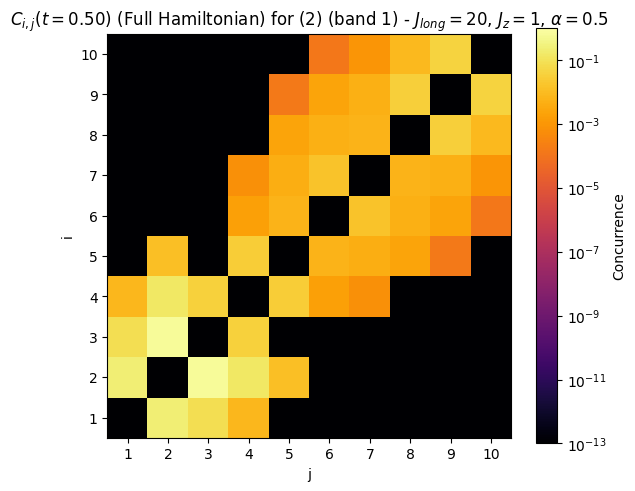

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def load_concurrence_file(fname):
    data = np.loadtxt(fname)

    out = []
    for row in data:
        t = row[0]
        p = int(row[1])
        j = int(row[2])

        rho_vals = row[4:]
        rho = rho_vals.reshape(4,4,2)
        rho = rho[:,:,0] + 1j*rho[:,:,1]

        out.append((t, p, j, rho))

    return out

def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    Y = np.kron(sy, sy)

    R = rho @ (Y @ rho.conj() @ Y)
    evals = np.real(np.linalg.eigvals(R))
    evals = np.maximum(evals, 0.0)
    evals = np.sort(np.sqrt(evals))[::-1]

    return max(0.0, evals[0] - evals[1] - evals[2] - evals[3])

def concurrence_matrix(data, t_target, ns, tol=1e-12):
    C = np.zeros((ns, ns))

    for t, p, j, rho in data:
        if abs(t - t_target) > tol:
            continue

        c = concurrence(rho)
        C[p, j] = c
        # C[j, p] = c   # symmetry

    return C

ns = 10
t0 = 0.5
base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"
fname = f"{base}62Concurrence.txt"
data = load_concurrence_file(fname)

C = concurrence_matrix(data, t0, ns)

# --------------------------------------------------
# PLOT
# --------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# --- threshold ---
vmin = 1e-13

# Copy & mask
C_plot = C.copy()
C_plot[C_plot < vmin] = vmin  # everything below threshold → underflow

# Colormap
cmap = plt.cm.inferno.copy()
cmap.set_under("black")          # 👈 hard black below vmin

plt.figure(figsize=(6,5))

im = plt.imshow(
    C_plot,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=1),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

plt.colorbar(im, label="Concurrence")

# Ticks at lattice sites
ticks = np.arange(1, ns+1, 1)
plt.xticks(ticks)
plt.yticks(ticks)

plt.xlabel("j")
plt.ylabel("i")
plt.title(rf"$C_{{i,j}}(t={t0:.2f})$ (Full Hamiltonian) for (2) (band 1) - $J_{{long}}=20$, $J_z=1$, $\alpha=0.5$")
plt.savefig(f"plt/ConcurrenceMatrix_FullH_{config}.pdf", dpi=600)
plt.tight_layout()
plt.show()



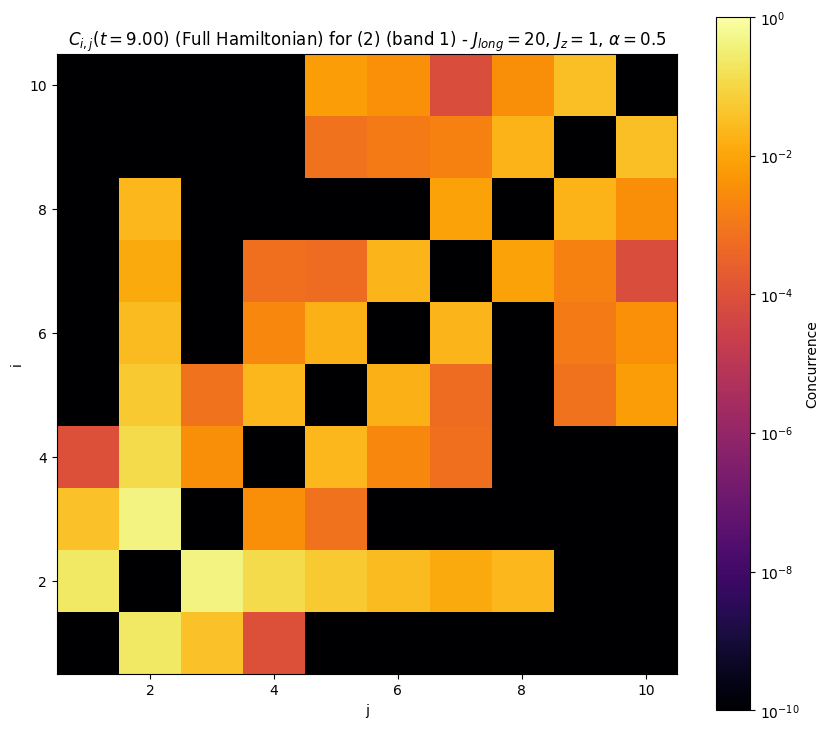

In [11]:
from collections import defaultdict

def group_by_time(data, tol=1e-12):
    times = sorted(set(t for t, _, _, _ in data))
    grouped = defaultdict(list)
    for t, p, j, rho in data:
        grouped[t].append((p, j, rho))
    return times, grouped

times, data_by_time = group_by_time(data)

times = [t for t in times if 0.0 <= t <= 9.0]

import matplotlib.animation as animation

vmin = 1e-10
vmax = 1.0   # keep fixed for ALL frames

fig, ax = plt.subplots(figsize=(10,9))

# initialize empty matrix
C0 = np.full((ns, ns), np.nan)

cmap = plt.cm.inferno.copy()
cmap.set_under("black")

im = ax.imshow(
    C0,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Concurrence")

ticks = np.arange(2, ns+1, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel("j")
ax.set_ylabel("i")

title = ax.set_title("")

# --------------------------------------------------
# Frame update function
# --------------------------------------------------
def update(frame):
    t = times[frame]
    C = np.zeros((ns, ns))

    for p, j, rho in data_by_time[t]:
        C[p, j] = concurrence(rho)

    C[C < vmin] = vmin   # force underflow → black
    im.set_data(C)
    title.set_text(rf"$C_{{i,j}}(t={t:.2f})$ (Full Hamiltonian) for (2) (band 1) - $J_{{long}}=20$, $J_z=1$, $\alpha=0.5$")
    return im,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=60,   # ms between frames
    blit=True
)

from matplotlib.animation import PillowWriter
ani.save("concurrence_matrix6.gif", writer=PillowWriter(fps=15))



Entangled full band 1 long range (70)


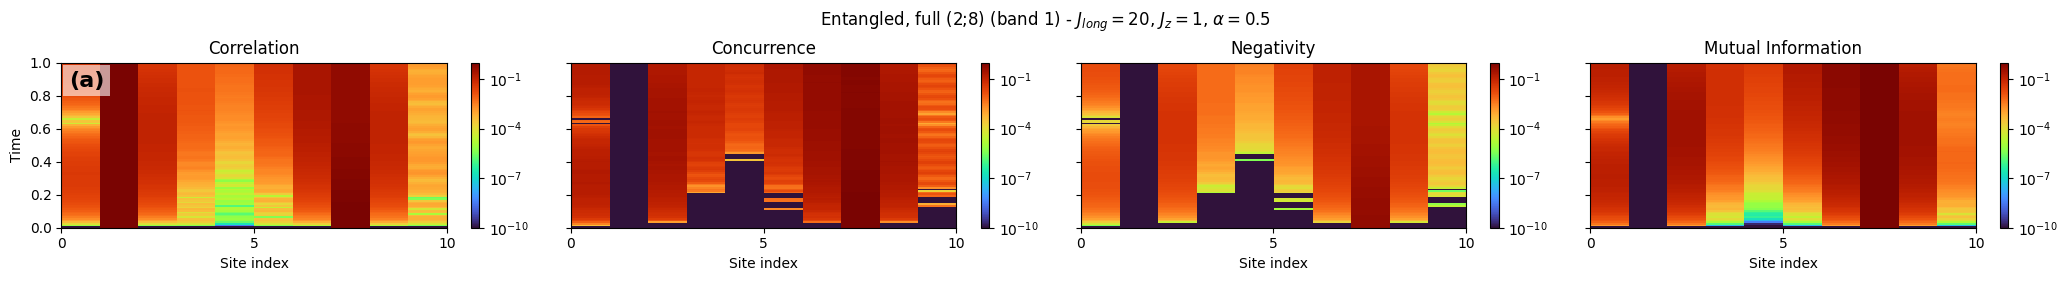

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    return max(0, evals[0] - evals[1] - evals[2] - evals[3])

# --------------------------------------------------
# Negativity computation
# --------------------------------------------------
def negativity(rho):
    # original indices: (iA, iB, jA, jB)
    #(0,1,2,3)
    rho_pt = rho.reshape(2,2,2,2).transpose(0,3,2,1).reshape(4,4)
    # indices: (iA, jB, jA, iB)
    #(0,3,2,1)
    # evals = np.linalg.eigvals(rho_pt)
    # return np.sum(np.abs(evals[evals < 0]))
    evals = np.linalg.eigvalsh(rho_pt)  # Hermitian solver
    return -np.sum(evals[evals < 0])


# --------------------------------------------------
# Von Neumann entropy
# --------------------------------------------------
def von_neumann_entropy(rho, eps=1e-12):
    evals = np.linalg.eigvalsh(rho)
    evals = np.clip(evals, eps, None)
    return -np.sum(evals * np.log2(evals))

# --------------------------------------------------
# Mutual information
# --------------------------------------------------
def mutual_information(rho):
    rho = rho / np.trace(rho)
    rhoA = np.trace(rho.reshape(2,2,2,2), axis1=1, axis2=3)
    rhoB = np.trace(rho.reshape(2,2,2,2), axis1=0, axis2=2)
    return (
        von_neumann_entropy(rhoA)
        + von_neumann_entropy(rhoB)
        - von_neumann_entropy(rho)
    )

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
configsArray = [70]#,31

t_max_plot = 1

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\CYPRESS\Concurrence\Ran\ConcurrenceTest"

# panel letters: (a), (b), (c), ...
panel_letters = [f"({chr(97+i)})" for i in range(len(configsArray))]

for idx, config in enumerate(configsArray):

    ns = 10
    p_target = 1
    # if config == 30:
    #     p_target = 7
    # else:
    #     p_target = 1
    fnameC    = f"{base}{config}Concurrence.txt"
    fnameCorr = f"{base}{config}CorrelationFunction.txt"

    dataC    = np.loadtxt(fnameC)

    # --- load correlation file safely ---
    dataCorr = np.genfromtxt(fnameCorr, filling_values=np.nan, invalid_raise=False)
    dataCorr = dataCorr[~np.isnan(dataCorr).any(axis=1)]


    # --------------------------------------------------
    # Correlation data
    # --------------------------------------------------
    times_corr = dataCorr[:,0]
    CorrMat = np.abs(dataCorr[:,1:ns+1])

    # --------------------------------------------------
    # Time axis (MASTER)
    # --------------------------------------------------
    uniq_times = np.unique(dataC[:,0])
    time_mask  = uniq_times <= t_max_plot
    plot_times = uniq_times[time_mask]
    t_min, t_max = plot_times.min(), plot_times.max()

    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    # --------------------------------------------------
    # Allocate matrices
    # --------------------------------------------------
    Cmat  = np.zeros((len(uniq_times), ns))
    Nmat  = np.zeros((len(uniq_times), ns))
    MImat = np.zeros((len(uniq_times), ns))

    # --------------------------------------------------
    # Fill matrices
    # --------------------------------------------------
    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)

        Cmat[k, j]  = concurrence(rho)
        Nmat[k, j]  = negativity(rho)
        MImat[k, j] = mutual_information(rho)

    # --------------------------------------------------
    # Apply SAME time cut to ALL matrices
    # --------------------------------------------------
    Cmat  = Cmat[time_mask, :]
    Nmat  = Nmat[time_mask, :]
    MImat = MImat[time_mask, :]

    corr_mask = times_corr <= t_max_plot
    CorrMat   = CorrMat[corr_mask, :]

    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------
    fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)
    extent = [0, ns, t_min, t_max]

    im1 = ax[0].imshow(np.clip(CorrMat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo", interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im2 = ax[1].imshow(np.clip(Cmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im3 = ax[2].imshow(np.clip(Nmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im4 = ax[3].imshow(np.clip(MImat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    x_ticks = np.arange(0, ns + 1, 5)

    for a in ax:
        a.set_xticks(x_ticks)
        a.set_xticklabels([f"{int(x)}" for x in x_ticks])

    ax[0].set_title("Correlation")
    ax[1].set_title("Concurrence")
    ax[2].set_title("Negativity")
    ax[3].set_title("Mutual Information")

    ax[0].set_ylabel("Time")
    for a in ax:
        a.set_xlabel("Site index")

    # --------------------------------------------------
    # SINGLE panel letter for the entire row
    # --------------------------------------------------
    ax[0].text(
        0.02, 0.95, panel_letters[idx],   # 👈 INSIDE the plot
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )


    for im, a in zip([im1, im2, im3, im4], ax):
        plt.colorbar(im, ax=a)

    # --------------------------------------------------
    # Suptitles (unchanged)
    # --------------------------------------------------
    plt.suptitle(r"Entangled, full (2;8) (band 1) - $J_{long}=20$, $J_z=1$, $\alpha=0.5$", y=0.92)

    plt.tight_layout()
    plt.savefig(f"plt/Concurrence_Corr_Config{config}.pdf", dpi=600)
    plt.show()


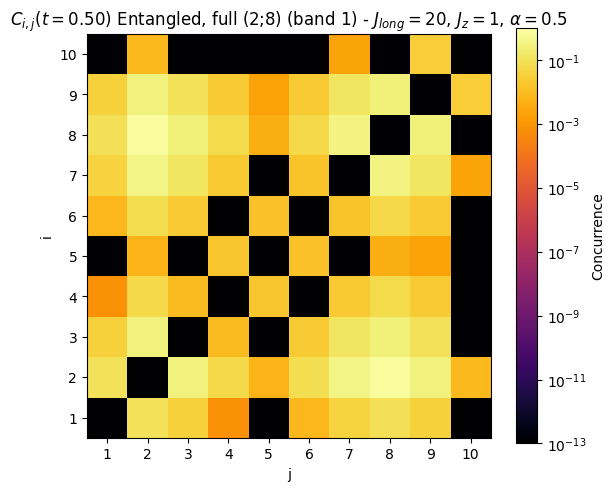

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def load_concurrence_file(fname):
    data = np.loadtxt(fname)

    out = []
    for row in data:
        t = row[0]
        p = int(row[1])
        j = int(row[2])

        rho_vals = row[4:]
        rho = rho_vals.reshape(4,4,2)
        rho = rho[:,:,0] + 1j*rho[:,:,1]

        out.append((t, p, j, rho))

    return out

def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    Y = np.kron(sy, sy)

    R = rho @ (Y @ rho.conj() @ Y)
    evals = np.real(np.linalg.eigvals(R))
    evals = np.maximum(evals, 0.0)
    evals = np.sort(np.sqrt(evals))[::-1]

    return max(0.0, evals[0] - evals[1] - evals[2] - evals[3])

def concurrence_matrix(data, t_target, ns, tol=1e-12):
    C = np.zeros((ns, ns))

    for t, p, j, rho in data:
        if abs(t - t_target) > tol:
            continue

        c = concurrence(rho)
        C[p, j] = c
        # C[j, p] = c   # symmetry

    return C

ns = 10
t0 = 0.5
base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\CYPRESS\Concurrence\Ran\ConcurrenceTest"
fname = f"{base}70Concurrence.txt"
data = load_concurrence_file(fname)

C = concurrence_matrix(data, t0, ns)

# --------------------------------------------------
# PLOT
# --------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# --- threshold ---
vmin = 1e-13

# Copy & mask
C_plot = C.copy()
C_plot[C_plot < vmin] = vmin  # everything below threshold → underflow

# Colormap
cmap = plt.cm.inferno.copy()
cmap.set_under("black")          # 👈 hard black below vmin

plt.figure(figsize=(6,5))

im = plt.imshow(
    C_plot,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=1),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

plt.colorbar(im, label="Concurrence")

# Ticks at lattice sites
ticks = np.arange(1, ns+1, 1)
plt.xticks(ticks)
plt.yticks(ticks)

plt.xlabel("j")
plt.ylabel("i")
plt.title(rf"$C_{{i,j}}(t={t0:.2f})$ Entangled, full (2;8) (band 1) - $J_{{long}}=20$, $J_z=1$, $\alpha=0.5$")
plt.savefig(f"plt/ConcurrenceMatrix_FullH_{config}.pdf", dpi=600)
plt.tight_layout()
plt.show()



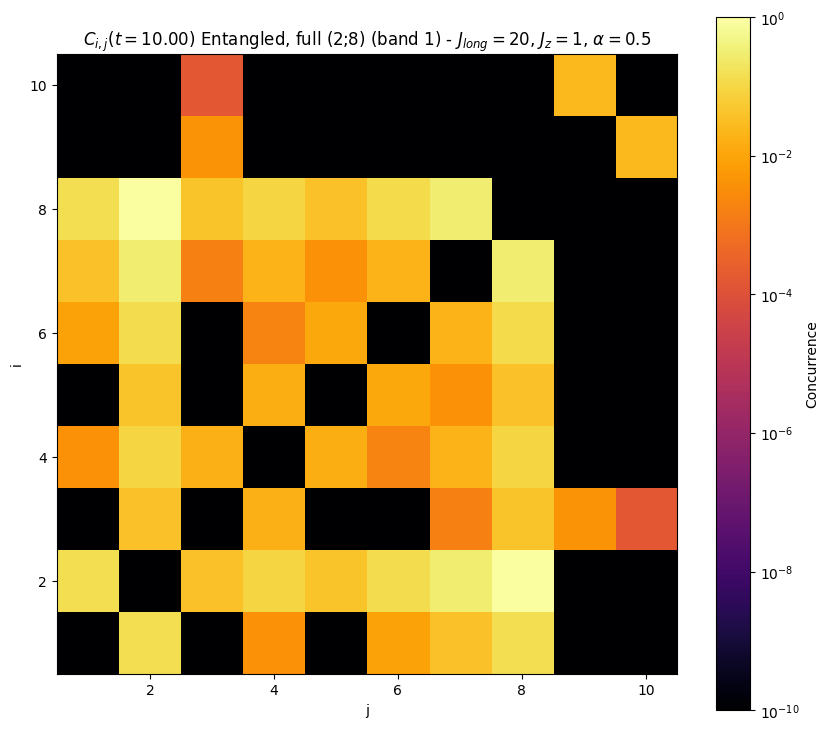

In [24]:
from collections import defaultdict

def group_by_time(data, tol=1e-12):
    times = sorted(set(t for t, _, _, _ in data))
    grouped = defaultdict(list)
    for t, p, j, rho in data:
        grouped[t].append((p, j, rho))
    return times, grouped

times, data_by_time = group_by_time(data)

times = [t for t in times if 0.0 <= t <= 10.0]

import matplotlib.animation as animation

vmin = 1e-10
vmax = 1.0   # keep fixed for ALL frames

fig, ax = plt.subplots(figsize=(10,9))

# initialize empty matrix
C0 = np.full((ns, ns), np.nan)

cmap = plt.cm.inferno.copy()
cmap.set_under("black")

im = ax.imshow(
    C0,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Concurrence")

ticks = np.arange(2, ns+1, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel("j")
ax.set_ylabel("i")

title = ax.set_title("")

# --------------------------------------------------
# Frame update function
# --------------------------------------------------
def update(frame):
    t = times[frame]
    C = np.zeros((ns, ns))

    for p, j, rho in data_by_time[t]:
        C[p, j] = concurrence(rho)

    C[C < vmin] = vmin   # force underflow → black
    im.set_data(C)
    title.set_text(rf"$C_{{i,j}}(t={t:.2f})$ Entangled, full (2;8) (band 1) - $J_{{long}}=20$, $J_z=1$, $\alpha=0.5$")
    return im,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=60,   # ms between frames
    blit=True
)

from matplotlib.animation import PillowWriter
ani.save("concurrence_matrix10.gif", writer=PillowWriter(fps=15))


Entangled full band 1 short range (71)

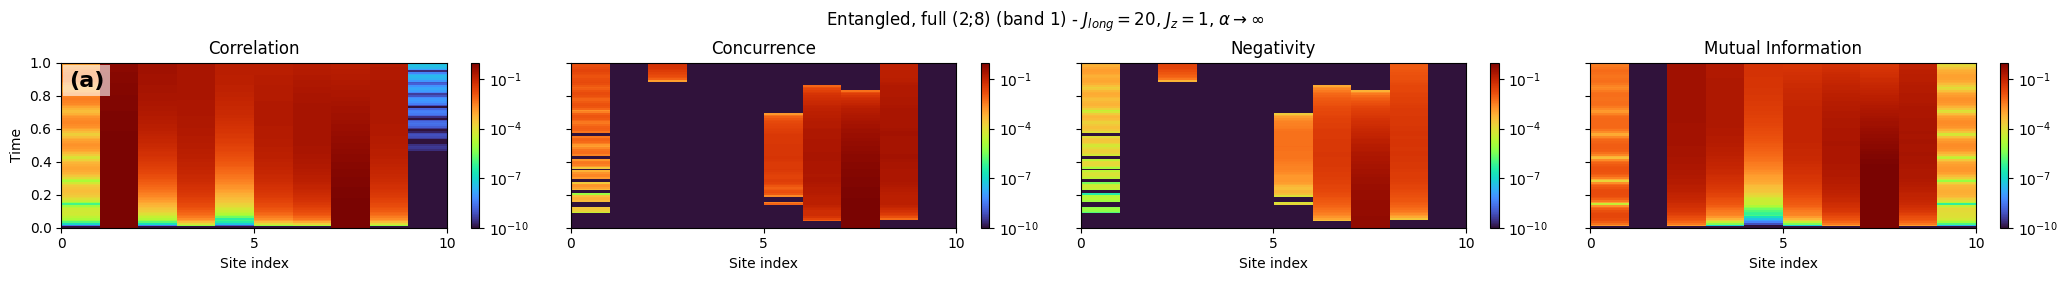

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    return max(0, evals[0] - evals[1] - evals[2] - evals[3])

# --------------------------------------------------
# Negativity computation
# --------------------------------------------------
def negativity(rho):
    # original indices: (iA, iB, jA, jB)
    #(0,1,2,3)
    rho_pt = rho.reshape(2,2,2,2).transpose(0,3,2,1).reshape(4,4)
    # indices: (iA, jB, jA, iB)
    #(0,3,2,1)
    # evals = np.linalg.eigvals(rho_pt)
    # return np.sum(np.abs(evals[evals < 0]))
    evals = np.linalg.eigvalsh(rho_pt)  # Hermitian solver
    return -np.sum(evals[evals < 0])


# --------------------------------------------------
# Von Neumann entropy
# --------------------------------------------------
def von_neumann_entropy(rho, eps=1e-12):
    evals = np.linalg.eigvalsh(rho)
    evals = np.clip(evals, eps, None)
    return -np.sum(evals * np.log2(evals))

# --------------------------------------------------
# Mutual information
# --------------------------------------------------
def mutual_information(rho):
    rho = rho / np.trace(rho)
    rhoA = np.trace(rho.reshape(2,2,2,2), axis1=1, axis2=3)
    rhoB = np.trace(rho.reshape(2,2,2,2), axis1=0, axis2=2)
    return (
        von_neumann_entropy(rhoA)
        + von_neumann_entropy(rhoB)
        - von_neumann_entropy(rho)
    )

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
configsArray = [71]#,31

t_max_plot = 1

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\CYPRESS\Concurrence\Ran\ConcurrenceTest"

# panel letters: (a), (b), (c), ...
panel_letters = [f"({chr(97+i)})" for i in range(len(configsArray))]

for idx, config in enumerate(configsArray):

    ns = 10
    p_target = 1
    # if config == 30:
    #     p_target = 7
    # else:
    #     p_target = 1
    fnameC    = f"{base}{config}Concurrence.txt"
    fnameCorr = f"{base}{config}CorrelationFunction.txt"

    dataC    = np.loadtxt(fnameC)

    # --- load correlation file safely ---
    dataCorr = np.genfromtxt(fnameCorr, filling_values=np.nan, invalid_raise=False)
    dataCorr = dataCorr[~np.isnan(dataCorr).any(axis=1)]


    # --------------------------------------------------
    # Correlation data
    # --------------------------------------------------
    times_corr = dataCorr[:,0]
    CorrMat = np.abs(dataCorr[:,1:ns+1])

    # --------------------------------------------------
    # Time axis (MASTER)
    # --------------------------------------------------
    uniq_times = np.unique(dataC[:,0])
    time_mask  = uniq_times <= t_max_plot
    plot_times = uniq_times[time_mask]
    t_min, t_max = plot_times.min(), plot_times.max()

    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    # --------------------------------------------------
    # Allocate matrices
    # --------------------------------------------------
    Cmat  = np.zeros((len(uniq_times), ns))
    Nmat  = np.zeros((len(uniq_times), ns))
    MImat = np.zeros((len(uniq_times), ns))

    # --------------------------------------------------
    # Fill matrices
    # --------------------------------------------------
    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)

        Cmat[k, j]  = concurrence(rho)
        Nmat[k, j]  = negativity(rho)
        MImat[k, j] = mutual_information(rho)

    # --------------------------------------------------
    # Apply SAME time cut to ALL matrices
    # --------------------------------------------------
    Cmat  = Cmat[time_mask, :]
    Nmat  = Nmat[time_mask, :]
    MImat = MImat[time_mask, :]

    corr_mask = times_corr <= t_max_plot
    CorrMat   = CorrMat[corr_mask, :]

    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------
    fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)
    extent = [0, ns, t_min, t_max]

    im1 = ax[0].imshow(np.clip(CorrMat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo", interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im2 = ax[1].imshow(np.clip(Cmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im3 = ax[2].imshow(np.clip(Nmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im4 = ax[3].imshow(np.clip(MImat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    x_ticks = np.arange(0, ns + 1, 5)

    for a in ax:
        a.set_xticks(x_ticks)
        a.set_xticklabels([f"{int(x)}" for x in x_ticks])

    ax[0].set_title("Correlation")
    ax[1].set_title("Concurrence")
    ax[2].set_title("Negativity")
    ax[3].set_title("Mutual Information")

    ax[0].set_ylabel("Time")
    for a in ax:
        a.set_xlabel("Site index")

    # --------------------------------------------------
    # SINGLE panel letter for the entire row
    # --------------------------------------------------
    ax[0].text(
        0.02, 0.95, panel_letters[idx],   # 👈 INSIDE the plot
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )


    for im, a in zip([im1, im2, im3, im4], ax):
        plt.colorbar(im, ax=a)

    # --------------------------------------------------
    # Suptitles (unchanged)
    # --------------------------------------------------
    plt.suptitle(r"Entangled, full (2;8) (band 1) - $J_{long}=20$, $J_z=1$, $\alpha\to\infty$", y=0.92)

    plt.tight_layout()
    plt.savefig(f"plt/Concurrence_Corr_Config{config}.pdf", dpi=600)
    plt.show()


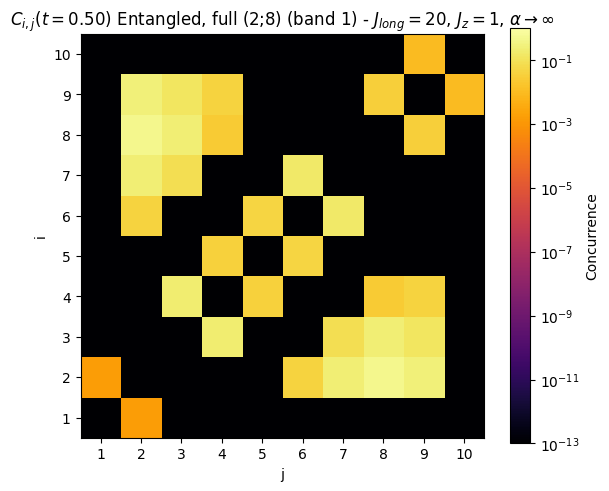

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def load_concurrence_file(fname):
    data = np.loadtxt(fname)

    out = []
    for row in data:
        t = row[0]
        p = int(row[1])
        j = int(row[2])

        rho_vals = row[4:]
        rho = rho_vals.reshape(4,4,2)
        rho = rho[:,:,0] + 1j*rho[:,:,1]

        out.append((t, p, j, rho))

    return out

def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    Y = np.kron(sy, sy)

    R = rho @ (Y @ rho.conj() @ Y)
    evals = np.real(np.linalg.eigvals(R))
    evals = np.maximum(evals, 0.0)
    evals = np.sort(np.sqrt(evals))[::-1]

    return max(0.0, evals[0] - evals[1] - evals[2] - evals[3])

def concurrence_matrix(data, t_target, ns, tol=1e-12):
    C = np.zeros((ns, ns))

    for t, p, j, rho in data:
        if abs(t - t_target) > tol:
            continue

        c = concurrence(rho)
        C[p, j] = c
        # C[j, p] = c   # symmetry

    return C

ns = 10
t0 = 0.5
base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\CYPRESS\Concurrence\Ran\ConcurrenceTest"
fname = f"{base}71Concurrence.txt"
data = load_concurrence_file(fname)

C = concurrence_matrix(data, t0, ns)

# --------------------------------------------------
# PLOT
# --------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# --- threshold ---
vmin = 1e-13

# Copy & mask
C_plot = C.copy()
C_plot[C_plot < vmin] = vmin  # everything below threshold → underflow

# Colormap
cmap = plt.cm.inferno.copy()
cmap.set_under("black")          # 👈 hard black below vmin

plt.figure(figsize=(6,5))

im = plt.imshow(
    C_plot,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=1),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

plt.colorbar(im, label="Concurrence")

# Ticks at lattice sites
ticks = np.arange(1, ns+1, 1)
plt.xticks(ticks)
plt.yticks(ticks)

plt.xlabel("j")
plt.ylabel("i")
plt.title(rf"$C_{{i,j}}(t={t0:.2f})$ Entangled, full (2;8) (band 1) - $J_{{long}}=20$, $J_z=1$, $\alpha\to\infty$")
plt.savefig(f"plt/ConcurrenceMatrix_FullH_{config}.pdf", dpi=600)
plt.tight_layout()
plt.show()

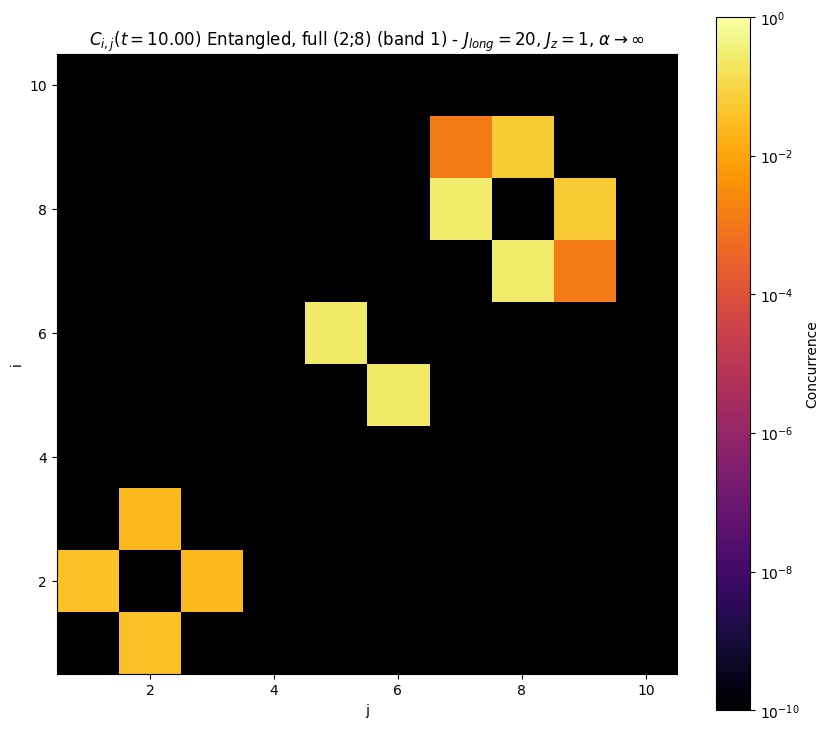

In [27]:
from collections import defaultdict

def group_by_time(data, tol=1e-12):
    times = sorted(set(t for t, _, _, _ in data))
    grouped = defaultdict(list)
    for t, p, j, rho in data:
        grouped[t].append((p, j, rho))
    return times, grouped

times, data_by_time = group_by_time(data)

times = [t for t in times if 0.0 <= t <= 10.0]

import matplotlib.animation as animation

vmin = 1e-10
vmax = 1.0   # keep fixed for ALL frames

fig, ax = plt.subplots(figsize=(10,9))

# initialize empty matrix
C0 = np.full((ns, ns), np.nan)

cmap = plt.cm.inferno.copy()
cmap.set_under("black")

im = ax.imshow(
    C0,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Concurrence")

ticks = np.arange(2, ns+1, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel("j")
ax.set_ylabel("i")

title = ax.set_title("")

# --------------------------------------------------
# Frame update function
# --------------------------------------------------
def update(frame):
    t = times[frame]
    C = np.zeros((ns, ns))

    for p, j, rho in data_by_time[t]:
        C[p, j] = concurrence(rho)

    C[C < vmin] = vmin   # force underflow → black
    im.set_data(C)
    title.set_text(rf"$C_{{i,j}}(t={t:.2f})$ Entangled, full (2;8) (band 1) - $J_{{long}}=20$, $J_z=1$, $\alpha\to\infty$")
    return im,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=60,   # ms between frames
    blit=True
)

from matplotlib.animation import PillowWriter
ani.save("concurrence_matrix11.gif", writer=PillowWriter(fps=15))

Product full band 2 long range (72) 

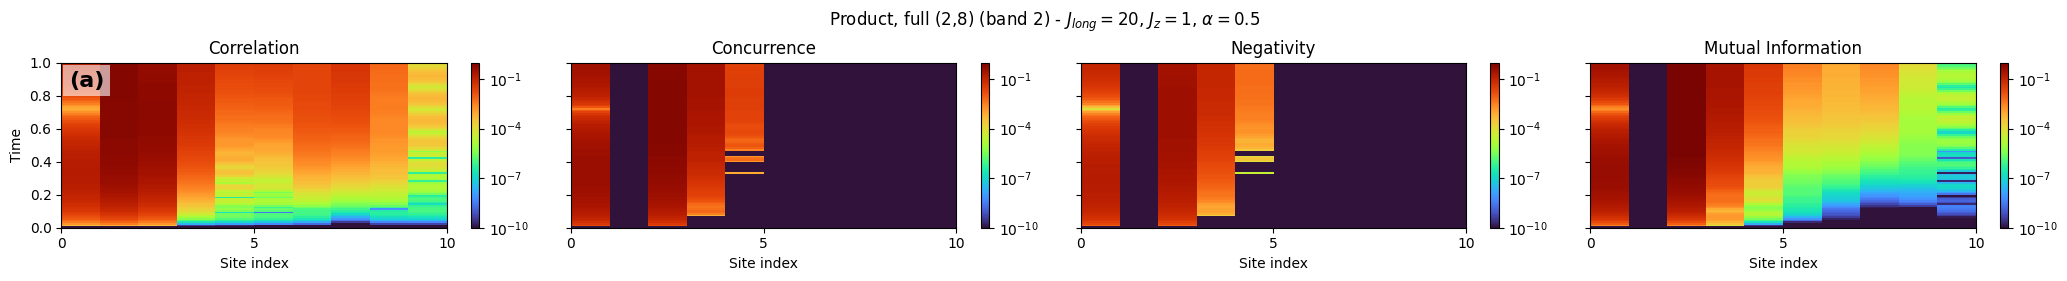

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    return max(0, evals[0] - evals[1] - evals[2] - evals[3])

# --------------------------------------------------
# Negativity computation
# --------------------------------------------------
def negativity(rho):
    # original indices: (iA, iB, jA, jB)
    #(0,1,2,3)
    rho_pt = rho.reshape(2,2,2,2).transpose(0,3,2,1).reshape(4,4)
    # indices: (iA, jB, jA, iB)
    #(0,3,2,1)
    # evals = np.linalg.eigvals(rho_pt)
    # return np.sum(np.abs(evals[evals < 0]))
    evals = np.linalg.eigvalsh(rho_pt)  # Hermitian solver
    return -np.sum(evals[evals < 0])


# --------------------------------------------------
# Von Neumann entropy
# --------------------------------------------------
def von_neumann_entropy(rho, eps=1e-12):
    evals = np.linalg.eigvalsh(rho)
    evals = np.clip(evals, eps, None)
    return -np.sum(evals * np.log2(evals))

# --------------------------------------------------
# Mutual information
# --------------------------------------------------
def mutual_information(rho):
    rho = rho / np.trace(rho)
    rhoA = np.trace(rho.reshape(2,2,2,2), axis1=1, axis2=3)
    rhoB = np.trace(rho.reshape(2,2,2,2), axis1=0, axis2=2)
    return (
        von_neumann_entropy(rhoA)
        + von_neumann_entropy(rhoB)
        - von_neumann_entropy(rho)
    )

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
configsArray = [72]#,31

t_max_plot = 1

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\CYPRESS\Concurrence\Ran\ConcurrenceTest"

# panel letters: (a), (b), (c), ...
panel_letters = [f"({chr(97+i)})" for i in range(len(configsArray))]

for idx, config in enumerate(configsArray):

    ns = 10
    p_target = 1
    # if config == 30:
    #     p_target = 7
    # else:
    #     p_target = 1
    fnameC    = f"{base}{config}Concurrence.txt"
    fnameCorr = f"{base}{config}CorrelationFunction.txt"

    dataC    = np.loadtxt(fnameC)

    # --- load correlation file safely ---
    dataCorr = np.genfromtxt(fnameCorr, filling_values=np.nan, invalid_raise=False)
    dataCorr = dataCorr[~np.isnan(dataCorr).any(axis=1)]


    # --------------------------------------------------
    # Correlation data
    # --------------------------------------------------
    times_corr = dataCorr[:,0]
    CorrMat = np.abs(dataCorr[:,1:ns+1])

    # --------------------------------------------------
    # Time axis (MASTER)
    # --------------------------------------------------
    uniq_times = np.unique(dataC[:,0])
    time_mask  = uniq_times <= t_max_plot
    plot_times = uniq_times[time_mask]
    t_min, t_max = plot_times.min(), plot_times.max()

    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    # --------------------------------------------------
    # Allocate matrices
    # --------------------------------------------------
    Cmat  = np.zeros((len(uniq_times), ns))
    Nmat  = np.zeros((len(uniq_times), ns))
    MImat = np.zeros((len(uniq_times), ns))

    # --------------------------------------------------
    # Fill matrices
    # --------------------------------------------------
    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)

        Cmat[k, j]  = concurrence(rho)
        Nmat[k, j]  = negativity(rho)
        MImat[k, j] = mutual_information(rho)

    # --------------------------------------------------
    # Apply SAME time cut to ALL matrices
    # --------------------------------------------------
    Cmat  = Cmat[time_mask, :]
    Nmat  = Nmat[time_mask, :]
    MImat = MImat[time_mask, :]

    corr_mask = times_corr <= t_max_plot
    CorrMat   = CorrMat[corr_mask, :]

    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------
    fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)
    extent = [0, ns, t_min, t_max]

    im1 = ax[0].imshow(np.clip(CorrMat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo", interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im2 = ax[1].imshow(np.clip(Cmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im3 = ax[2].imshow(np.clip(Nmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im4 = ax[3].imshow(np.clip(MImat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    x_ticks = np.arange(0, ns + 1, 5)

    for a in ax:
        a.set_xticks(x_ticks)
        a.set_xticklabels([f"{int(x)}" for x in x_ticks])

    ax[0].set_title("Correlation")
    ax[1].set_title("Concurrence")
    ax[2].set_title("Negativity")
    ax[3].set_title("Mutual Information")

    ax[0].set_ylabel("Time")
    for a in ax:
        a.set_xlabel("Site index")

    # --------------------------------------------------
    # SINGLE panel letter for the entire row
    # --------------------------------------------------
    ax[0].text(
        0.02, 0.95, panel_letters[idx],   # 👈 INSIDE the plot
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )


    for im, a in zip([im1, im2, im3, im4], ax):
        plt.colorbar(im, ax=a)

    # --------------------------------------------------
    # Suptitles (unchanged)
    # --------------------------------------------------
    plt.suptitle(r"Product, full (2,8) (band 2) - $J_{long}=20$, $J_z=1$, $\alpha=0.5$", y=0.92)

    plt.tight_layout()
    plt.savefig(f"plt/Concurrence_Corr_Config{config}.pdf", dpi=600)
    plt.show()


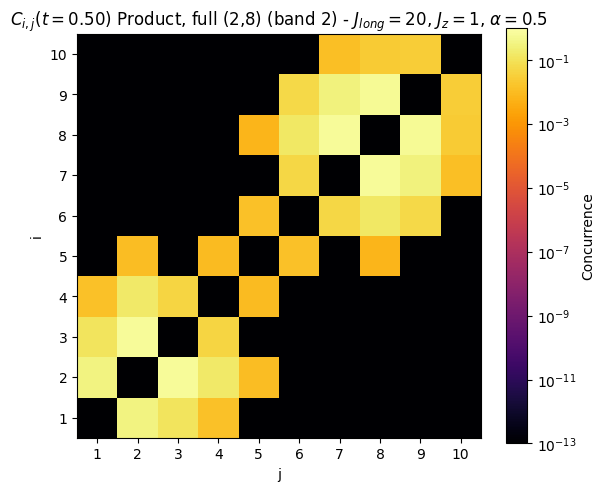

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def load_concurrence_file(fname):
    data = np.loadtxt(fname)

    out = []
    for row in data:
        t = row[0]
        p = int(row[1])
        j = int(row[2])

        rho_vals = row[4:]
        rho = rho_vals.reshape(4,4,2)
        rho = rho[:,:,0] + 1j*rho[:,:,1]

        out.append((t, p, j, rho))

    return out

def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    Y = np.kron(sy, sy)

    R = rho @ (Y @ rho.conj() @ Y)
    evals = np.real(np.linalg.eigvals(R))
    evals = np.maximum(evals, 0.0)
    evals = np.sort(np.sqrt(evals))[::-1]

    return max(0.0, evals[0] - evals[1] - evals[2] - evals[3])

def concurrence_matrix(data, t_target, ns, tol=1e-12):
    C = np.zeros((ns, ns))

    for t, p, j, rho in data:
        if abs(t - t_target) > tol:
            continue

        c = concurrence(rho)
        C[p, j] = c
        # C[j, p] = c   # symmetry

    return C

ns = 10
t0 = 0.5
base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\CYPRESS\Concurrence\Ran\ConcurrenceTest"
fname = f"{base}72Concurrence.txt"
data = load_concurrence_file(fname)

C = concurrence_matrix(data, t0, ns)

# --------------------------------------------------
# PLOT
# --------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# --- threshold ---
vmin = 1e-13

# Copy & mask
C_plot = C.copy()
C_plot[C_plot < vmin] = vmin  # everything below threshold → underflow

# Colormap
cmap = plt.cm.inferno.copy()
cmap.set_under("black")          # 👈 hard black below vmin

plt.figure(figsize=(6,5))

im = plt.imshow(
    C_plot,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=1),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

plt.colorbar(im, label="Concurrence")

# Ticks at lattice sites
ticks = np.arange(1, ns+1, 1)
plt.xticks(ticks)
plt.yticks(ticks)

plt.xlabel("j")
plt.ylabel("i")
plt.title(rf"$C_{{i,j}}(t={t0:.2f})$ Product, full (2,8) (band 2) - $J_{{long}}=20$, $J_z=1$, $\alpha=0.5$")
plt.savefig(f"plt/ConcurrenceMatrix_FullH_{config}.pdf", dpi=600)
plt.tight_layout()
plt.show()

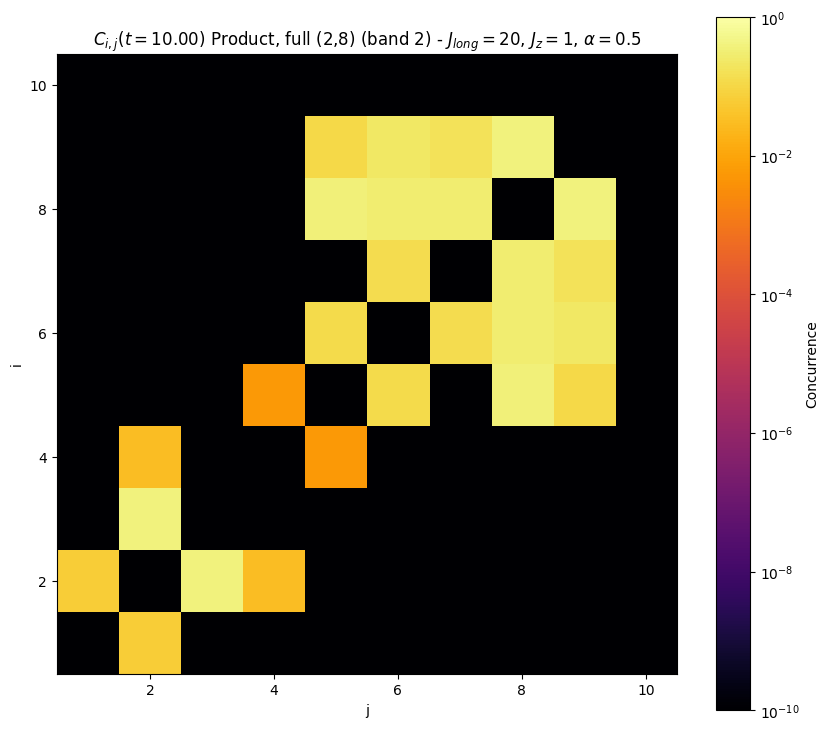

In [30]:
from collections import defaultdict

def group_by_time(data, tol=1e-12):
    times = sorted(set(t for t, _, _, _ in data))
    grouped = defaultdict(list)
    for t, p, j, rho in data:
        grouped[t].append((p, j, rho))
    return times, grouped

times, data_by_time = group_by_time(data)

times = [t for t in times if 0.0 <= t <= 10.0]

import matplotlib.animation as animation

vmin = 1e-10
vmax = 1.0   # keep fixed for ALL frames

fig, ax = plt.subplots(figsize=(10,9))

# initialize empty matrix
C0 = np.full((ns, ns), np.nan)

cmap = plt.cm.inferno.copy()
cmap.set_under("black")

im = ax.imshow(
    C0,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Concurrence")

ticks = np.arange(2, ns+1, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel("j")
ax.set_ylabel("i")

title = ax.set_title("")

# --------------------------------------------------
# Frame update function
# --------------------------------------------------
def update(frame):
    t = times[frame]
    C = np.zeros((ns, ns))

    for p, j, rho in data_by_time[t]:
        C[p, j] = concurrence(rho)

    C[C < vmin] = vmin   # force underflow → black
    im.set_data(C)
    title.set_text(rf"$C_{{i,j}}(t={t:.2f})$ Product, full (2,8) (band 2) - $J_{{long}}=20$, $J_z=1$, $\alpha=0.5$")
    return im,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=60,   # ms between frames
    blit=True
)

from matplotlib.animation import PillowWriter
ani.save("concurrence_matrix12.gif", writer=PillowWriter(fps=15))

Product full band 2 short range (73)

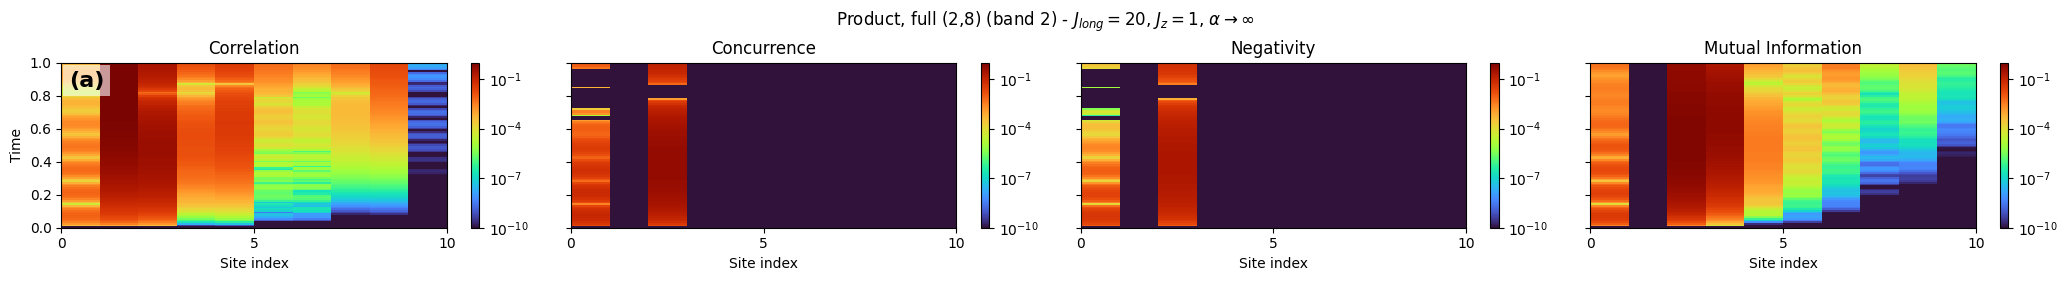

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    return max(0, evals[0] - evals[1] - evals[2] - evals[3])

# --------------------------------------------------
# Negativity computation
# --------------------------------------------------
def negativity(rho):
    # original indices: (iA, iB, jA, jB)
    #(0,1,2,3)
    rho_pt = rho.reshape(2,2,2,2).transpose(0,3,2,1).reshape(4,4)
    # indices: (iA, jB, jA, iB)
    #(0,3,2,1)
    # evals = np.linalg.eigvals(rho_pt)
    # return np.sum(np.abs(evals[evals < 0]))
    evals = np.linalg.eigvalsh(rho_pt)  # Hermitian solver
    return -np.sum(evals[evals < 0])


# --------------------------------------------------
# Von Neumann entropy
# --------------------------------------------------
def von_neumann_entropy(rho, eps=1e-12):
    evals = np.linalg.eigvalsh(rho)
    evals = np.clip(evals, eps, None)
    return -np.sum(evals * np.log2(evals))

# --------------------------------------------------
# Mutual information
# --------------------------------------------------
def mutual_information(rho):
    rho = rho / np.trace(rho)
    rhoA = np.trace(rho.reshape(2,2,2,2), axis1=1, axis2=3)
    rhoB = np.trace(rho.reshape(2,2,2,2), axis1=0, axis2=2)
    return (
        von_neumann_entropy(rhoA)
        + von_neumann_entropy(rhoB)
        - von_neumann_entropy(rho)
    )

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
configsArray = [73]#,31

t_max_plot = 1

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\CYPRESS\Concurrence\Ran\ConcurrenceTest"

# panel letters: (a), (b), (c), ...
panel_letters = [f"({chr(97+i)})" for i in range(len(configsArray))]

for idx, config in enumerate(configsArray):

    ns = 10
    p_target = 1
    # if config == 30:
    #     p_target = 7
    # else:
    #     p_target = 1
    fnameC    = f"{base}{config}Concurrence.txt"
    fnameCorr = f"{base}{config}CorrelationFunction.txt"

    dataC    = np.loadtxt(fnameC)

    # --- load correlation file safely ---
    dataCorr = np.genfromtxt(fnameCorr, filling_values=np.nan, invalid_raise=False)
    dataCorr = dataCorr[~np.isnan(dataCorr).any(axis=1)]


    # --------------------------------------------------
    # Correlation data
    # --------------------------------------------------
    times_corr = dataCorr[:,0]
    CorrMat = np.abs(dataCorr[:,1:ns+1])

    # --------------------------------------------------
    # Time axis (MASTER)
    # --------------------------------------------------
    uniq_times = np.unique(dataC[:,0])
    time_mask  = uniq_times <= t_max_plot
    plot_times = uniq_times[time_mask]
    t_min, t_max = plot_times.min(), plot_times.max()

    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    # --------------------------------------------------
    # Allocate matrices
    # --------------------------------------------------
    Cmat  = np.zeros((len(uniq_times), ns))
    Nmat  = np.zeros((len(uniq_times), ns))
    MImat = np.zeros((len(uniq_times), ns))

    # --------------------------------------------------
    # Fill matrices
    # --------------------------------------------------
    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)

        Cmat[k, j]  = concurrence(rho)
        Nmat[k, j]  = negativity(rho)
        MImat[k, j] = mutual_information(rho)

    # --------------------------------------------------
    # Apply SAME time cut to ALL matrices
    # --------------------------------------------------
    Cmat  = Cmat[time_mask, :]
    Nmat  = Nmat[time_mask, :]
    MImat = MImat[time_mask, :]

    corr_mask = times_corr <= t_max_plot
    CorrMat   = CorrMat[corr_mask, :]

    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------
    fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)
    extent = [0, ns, t_min, t_max]

    im1 = ax[0].imshow(np.clip(CorrMat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo", interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im2 = ax[1].imshow(np.clip(Cmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im3 = ax[2].imshow(np.clip(Nmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im4 = ax[3].imshow(np.clip(MImat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    x_ticks = np.arange(0, ns + 1, 5)

    for a in ax:
        a.set_xticks(x_ticks)
        a.set_xticklabels([f"{int(x)}" for x in x_ticks])

    ax[0].set_title("Correlation")
    ax[1].set_title("Concurrence")
    ax[2].set_title("Negativity")
    ax[3].set_title("Mutual Information")

    ax[0].set_ylabel("Time")
    for a in ax:
        a.set_xlabel("Site index")

    # --------------------------------------------------
    # SINGLE panel letter for the entire row
    # --------------------------------------------------
    ax[0].text(
        0.02, 0.95, panel_letters[idx],   # 👈 INSIDE the plot
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )


    for im, a in zip([im1, im2, im3, im4], ax):
        plt.colorbar(im, ax=a)

    # --------------------------------------------------
    # Suptitles (unchanged)
    # --------------------------------------------------
    plt.suptitle(r"Product, full (2,8) (band 2) - $J_{long}=20$, $J_z=1$, $\alpha\to\infty$", y=0.92)

    plt.tight_layout()
    plt.savefig(f"plt/Concurrence_Corr_Config{config}.pdf", dpi=600)
    plt.show()


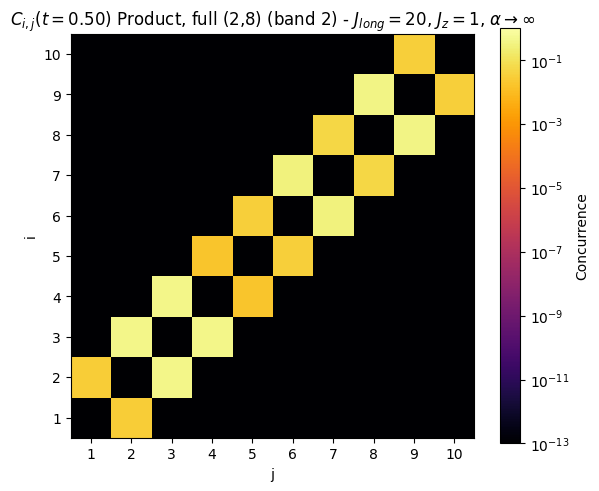

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def load_concurrence_file(fname):
    data = np.loadtxt(fname)

    out = []
    for row in data:
        t = row[0]
        p = int(row[1])
        j = int(row[2])

        rho_vals = row[4:]
        rho = rho_vals.reshape(4,4,2)
        rho = rho[:,:,0] + 1j*rho[:,:,1]

        out.append((t, p, j, rho))

    return out

def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    Y = np.kron(sy, sy)

    R = rho @ (Y @ rho.conj() @ Y)
    evals = np.real(np.linalg.eigvals(R))
    evals = np.maximum(evals, 0.0)
    evals = np.sort(np.sqrt(evals))[::-1]

    return max(0.0, evals[0] - evals[1] - evals[2] - evals[3])

def concurrence_matrix(data, t_target, ns, tol=1e-12):
    C = np.zeros((ns, ns))

    for t, p, j, rho in data:
        if abs(t - t_target) > tol:
            continue

        c = concurrence(rho)
        C[p, j] = c
        # C[j, p] = c   # symmetry

    return C

ns = 10
t0 = 0.5
base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\CYPRESS\Concurrence\Ran\ConcurrenceTest"
fname = f"{base}73Concurrence.txt"
data = load_concurrence_file(fname)

C = concurrence_matrix(data, t0, ns)

# --------------------------------------------------
# PLOT
# --------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# --- threshold ---
vmin = 1e-13

# Copy & mask
C_plot = C.copy()
C_plot[C_plot < vmin] = vmin  # everything below threshold → underflow

# Colormap
cmap = plt.cm.inferno.copy()
cmap.set_under("black")          # 👈 hard black below vmin

plt.figure(figsize=(6,5))

im = plt.imshow(
    C_plot,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=1),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

plt.colorbar(im, label="Concurrence")

# Ticks at lattice sites
ticks = np.arange(1, ns+1, 1)
plt.xticks(ticks)
plt.yticks(ticks)

plt.xlabel("j")
plt.ylabel("i")
plt.title(rf"$C_{{i,j}}(t={t0:.2f})$ Product, full (2,8) (band 2) - $J_{{long}}=20$, $J_z=1$, $\alpha\to\infty$")
plt.savefig(f"plt/ConcurrenceMatrix_FullH_{config}.pdf", dpi=600)
plt.tight_layout()
plt.show()

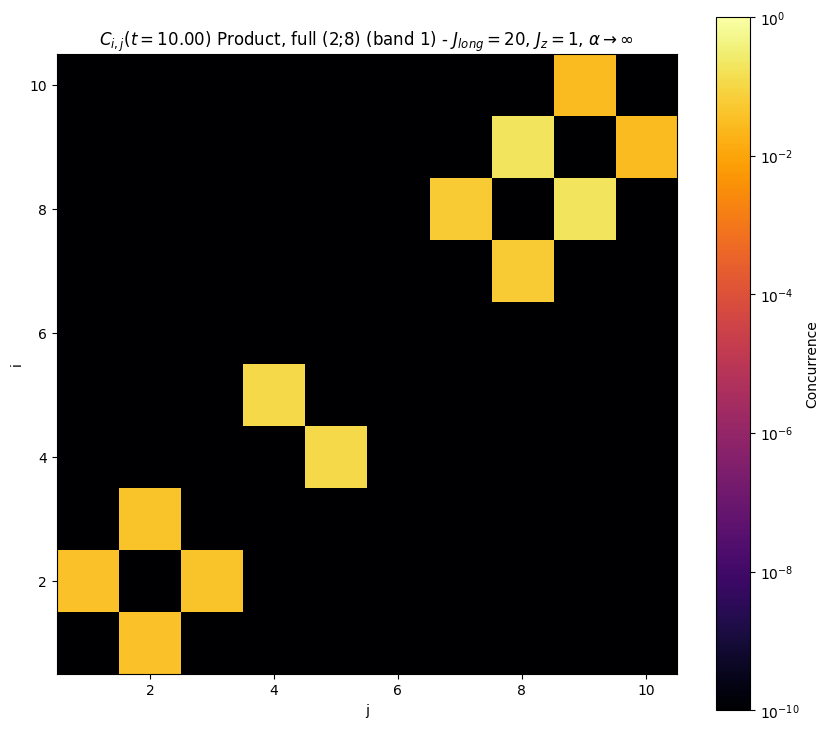

In [33]:
from collections import defaultdict

def group_by_time(data, tol=1e-12):
    times = sorted(set(t for t, _, _, _ in data))
    grouped = defaultdict(list)
    for t, p, j, rho in data:
        grouped[t].append((p, j, rho))
    return times, grouped

times, data_by_time = group_by_time(data)

times = [t for t in times if 0.0 <= t <= 10.0]

import matplotlib.animation as animation

vmin = 1e-10
vmax = 1.0   # keep fixed for ALL frames

fig, ax = plt.subplots(figsize=(10,9))

# initialize empty matrix
C0 = np.full((ns, ns), np.nan)

cmap = plt.cm.inferno.copy()
cmap.set_under("black")

im = ax.imshow(
    C0,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Concurrence")

ticks = np.arange(2, ns+1, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel("j")
ax.set_ylabel("i")

title = ax.set_title("")

# --------------------------------------------------
# Frame update function
# --------------------------------------------------
def update(frame):
    t = times[frame]
    C = np.zeros((ns, ns))

    for p, j, rho in data_by_time[t]:
        C[p, j] = concurrence(rho)

    C[C < vmin] = vmin   # force underflow → black
    im.set_data(C)
    title.set_text(rf"$C_{{i,j}}(t={t:.2f})$ Product, full (2;8) (band 1) - $J_{{long}}=20$, $J_z=1$, $\alpha\to\infty$")
    return im,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=60,   # ms between frames
    blit=True
)

from matplotlib.animation import PillowWriter
ani.save("concurrence_matrix13.gif", writer=PillowWriter(fps=15))

Single full band 1 long range (74)

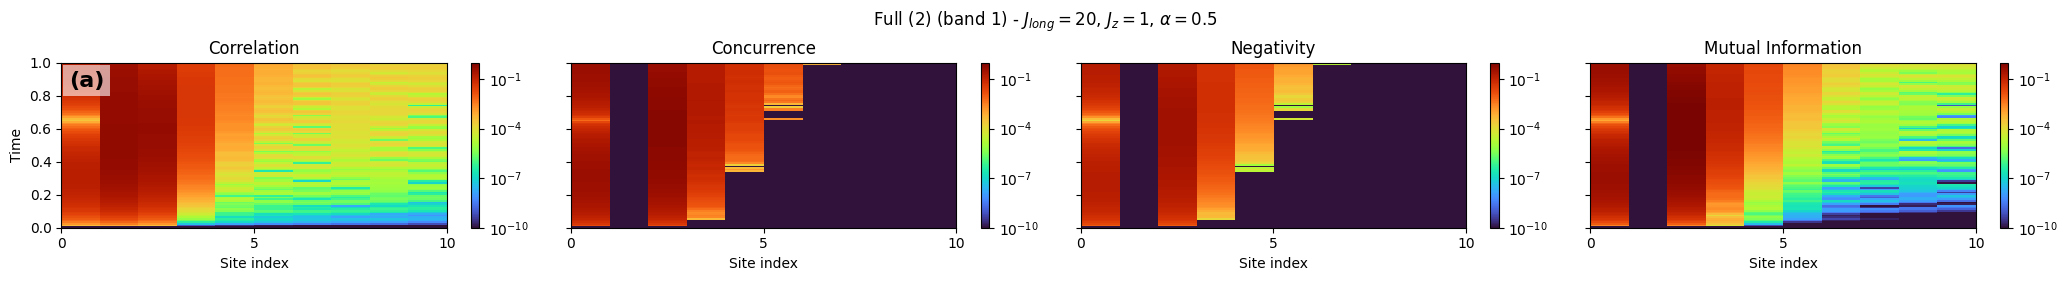

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    return max(0, evals[0] - evals[1] - evals[2] - evals[3])

# --------------------------------------------------
# Negativity computation
# --------------------------------------------------
def negativity(rho):
    # original indices: (iA, iB, jA, jB)
    #(0,1,2,3)
    rho_pt = rho.reshape(2,2,2,2).transpose(0,3,2,1).reshape(4,4)
    # indices: (iA, jB, jA, iB)
    #(0,3,2,1)
    # evals = np.linalg.eigvals(rho_pt)
    # return np.sum(np.abs(evals[evals < 0]))
    evals = np.linalg.eigvalsh(rho_pt)  # Hermitian solver
    return -np.sum(evals[evals < 0])


# --------------------------------------------------
# Von Neumann entropy
# --------------------------------------------------
def von_neumann_entropy(rho, eps=1e-12):
    evals = np.linalg.eigvalsh(rho)
    evals = np.clip(evals, eps, None)
    return -np.sum(evals * np.log2(evals))

# --------------------------------------------------
# Mutual information
# --------------------------------------------------
def mutual_information(rho):
    rho = rho / np.trace(rho)
    rhoA = np.trace(rho.reshape(2,2,2,2), axis1=1, axis2=3)
    rhoB = np.trace(rho.reshape(2,2,2,2), axis1=0, axis2=2)
    return (
        von_neumann_entropy(rhoA)
        + von_neumann_entropy(rhoB)
        - von_neumann_entropy(rho)
    )

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
configsArray = [74]#,31

t_max_plot = 1

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\CYPRESS\Concurrence\Ran\ConcurrenceTest"

# panel letters: (a), (b), (c), ...
panel_letters = [f"({chr(97+i)})" for i in range(len(configsArray))]

for idx, config in enumerate(configsArray):

    ns = 10
    p_target = 1
    # if config == 30:
    #     p_target = 7
    # else:
    #     p_target = 1
    fnameC    = f"{base}{config}Concurrence.txt"
    fnameCorr = f"{base}{config}CorrelationFunction.txt"

    dataC    = np.loadtxt(fnameC)

    # --- load correlation file safely ---
    dataCorr = np.genfromtxt(fnameCorr, filling_values=np.nan, invalid_raise=False)
    dataCorr = dataCorr[~np.isnan(dataCorr).any(axis=1)]


    # --------------------------------------------------
    # Correlation data
    # --------------------------------------------------
    times_corr = dataCorr[:,0]
    CorrMat = np.abs(dataCorr[:,1:ns+1])

    # --------------------------------------------------
    # Time axis (MASTER)
    # --------------------------------------------------
    uniq_times = np.unique(dataC[:,0])
    time_mask  = uniq_times <= t_max_plot
    plot_times = uniq_times[time_mask]
    t_min, t_max = plot_times.min(), plot_times.max()

    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    # --------------------------------------------------
    # Allocate matrices
    # --------------------------------------------------
    Cmat  = np.zeros((len(uniq_times), ns))
    Nmat  = np.zeros((len(uniq_times), ns))
    MImat = np.zeros((len(uniq_times), ns))

    # --------------------------------------------------
    # Fill matrices
    # --------------------------------------------------
    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)

        Cmat[k, j]  = concurrence(rho)
        Nmat[k, j]  = negativity(rho)
        MImat[k, j] = mutual_information(rho)

    # --------------------------------------------------
    # Apply SAME time cut to ALL matrices
    # --------------------------------------------------
    Cmat  = Cmat[time_mask, :]
    Nmat  = Nmat[time_mask, :]
    MImat = MImat[time_mask, :]

    corr_mask = times_corr <= t_max_plot
    CorrMat   = CorrMat[corr_mask, :]

    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------
    fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)
    extent = [0, ns, t_min, t_max]

    im1 = ax[0].imshow(np.clip(CorrMat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo", interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im2 = ax[1].imshow(np.clip(Cmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im3 = ax[2].imshow(np.clip(Nmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im4 = ax[3].imshow(np.clip(MImat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    x_ticks = np.arange(0, ns + 1, 5)

    for a in ax:
        a.set_xticks(x_ticks)
        a.set_xticklabels([f"{int(x)}" for x in x_ticks])

    ax[0].set_title("Correlation")
    ax[1].set_title("Concurrence")
    ax[2].set_title("Negativity")
    ax[3].set_title("Mutual Information")

    ax[0].set_ylabel("Time")
    for a in ax:
        a.set_xlabel("Site index")

    # --------------------------------------------------
    # SINGLE panel letter for the entire row
    # --------------------------------------------------
    ax[0].text(
        0.02, 0.95, panel_letters[idx],   # 👈 INSIDE the plot
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )


    for im, a in zip([im1, im2, im3, im4], ax):
        plt.colorbar(im, ax=a)

    # --------------------------------------------------
    # Suptitles (unchanged)
    # --------------------------------------------------
    plt.suptitle(r"Full (2) (band 1) - $J_{long}=20$, $J_z=1$, $\alpha=0.5$", y=0.92)

    plt.tight_layout()
    plt.savefig(f"plt/Concurrence_Corr_Config{config}.pdf", dpi=600)
    plt.show()


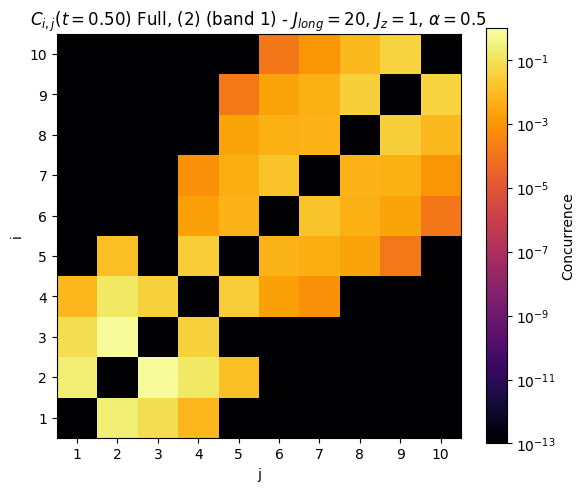

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def load_concurrence_file(fname):
    data = np.loadtxt(fname)

    out = []
    for row in data:
        t = row[0]
        p = int(row[1])
        j = int(row[2])

        rho_vals = row[4:]
        rho = rho_vals.reshape(4,4,2)
        rho = rho[:,:,0] + 1j*rho[:,:,1]

        out.append((t, p, j, rho))

    return out

def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    Y = np.kron(sy, sy)

    R = rho @ (Y @ rho.conj() @ Y)
    evals = np.real(np.linalg.eigvals(R))
    evals = np.maximum(evals, 0.0)
    evals = np.sort(np.sqrt(evals))[::-1]

    return max(0.0, evals[0] - evals[1] - evals[2] - evals[3])

def concurrence_matrix(data, t_target, ns, tol=1e-12):
    C = np.zeros((ns, ns))

    for t, p, j, rho in data:
        if abs(t - t_target) > tol:
            continue

        c = concurrence(rho)
        C[p, j] = c
        # C[j, p] = c   # symmetry

    return C

ns = 10
t0 = 0.5
base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\CYPRESS\Concurrence\Ran\ConcurrenceTest"
fname = f"{base}74Concurrence.txt"
data = load_concurrence_file(fname)

C = concurrence_matrix(data, t0, ns)

# --------------------------------------------------
# PLOT
# --------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# --- threshold ---
vmin = 1e-13

# Copy & mask
C_plot = C.copy()
C_plot[C_plot < vmin] = vmin  # everything below threshold → underflow

# Colormap
cmap = plt.cm.inferno.copy()
cmap.set_under("black")          # 👈 hard black below vmin

plt.figure(figsize=(6,5))

im = plt.imshow(
    C_plot,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=1),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

plt.colorbar(im, label="Concurrence")

# Ticks at lattice sites
ticks = np.arange(1, ns+1, 1)
plt.xticks(ticks)
plt.yticks(ticks)

plt.xlabel("j")
plt.ylabel("i")
plt.title(rf"$C_{{i,j}}(t={t0:.2f})$ Full, (2) (band 1) - $J_{{long}}=20$, $J_z=1$, $\alpha=0.5$")
plt.savefig(f"plt/ConcurrenceMatrix_FullH_{config}.pdf", dpi=600)
plt.tight_layout()
plt.show()

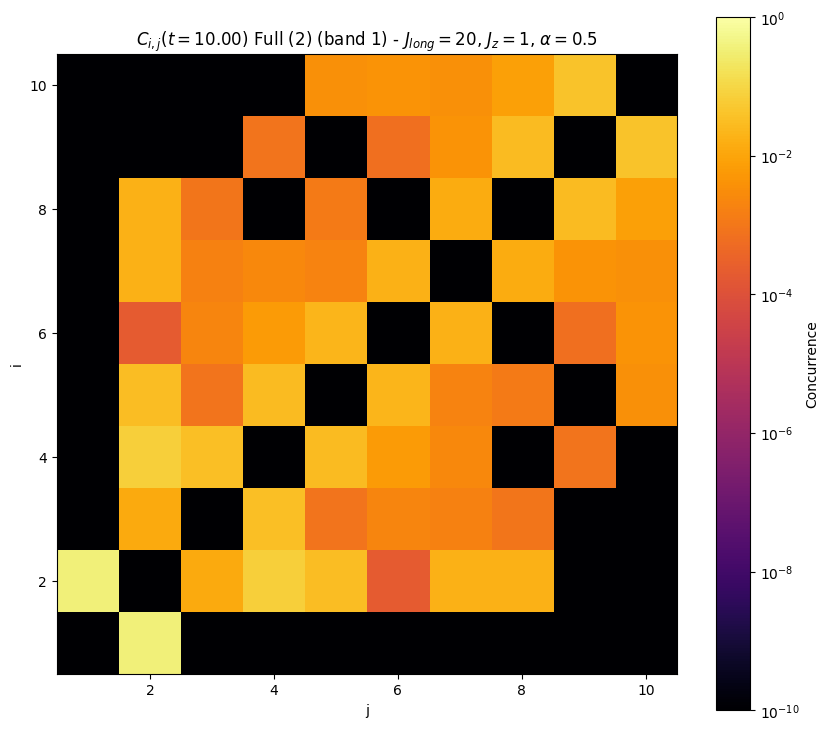

In [36]:
from collections import defaultdict

def group_by_time(data, tol=1e-12):
    times = sorted(set(t for t, _, _, _ in data))
    grouped = defaultdict(list)
    for t, p, j, rho in data:
        grouped[t].append((p, j, rho))
    return times, grouped

times, data_by_time = group_by_time(data)

times = [t for t in times if 0.0 <= t <= 10.0]

import matplotlib.animation as animation

vmin = 1e-10
vmax = 1.0   # keep fixed for ALL frames

fig, ax = plt.subplots(figsize=(10,9))

# initialize empty matrix
C0 = np.full((ns, ns), np.nan)

cmap = plt.cm.inferno.copy()
cmap.set_under("black")

im = ax.imshow(
    C0,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Concurrence")

ticks = np.arange(2, ns+1, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel("j")
ax.set_ylabel("i")

title = ax.set_title("")

# --------------------------------------------------
# Frame update function
# --------------------------------------------------
def update(frame):
    t = times[frame]
    C = np.zeros((ns, ns))

    for p, j, rho in data_by_time[t]:
        C[p, j] = concurrence(rho)

    C[C < vmin] = vmin   # force underflow → black
    im.set_data(C)
    title.set_text(rf"$C_{{i,j}}(t={t:.2f})$ Full (2) (band 1) - $J_{{long}}=20$, $J_z=1$, $\alpha=0.5$")
    return im,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=60,   # ms between frames
    blit=True
)

from matplotlib.animation import PillowWriter
ani.save("concurrence_matrix14.gif", writer=PillowWriter(fps=15))

Single full band 1 short range (75)

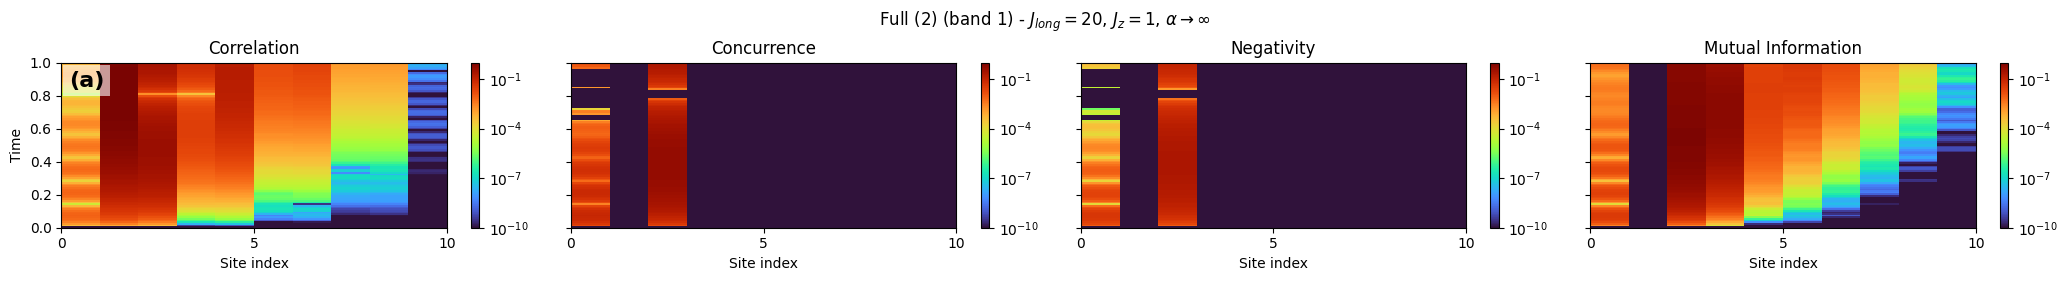

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    return max(0, evals[0] - evals[1] - evals[2] - evals[3])

# --------------------------------------------------
# Negativity computation
# --------------------------------------------------
def negativity(rho):
    # original indices: (iA, iB, jA, jB)
    #(0,1,2,3)
    rho_pt = rho.reshape(2,2,2,2).transpose(0,3,2,1).reshape(4,4)
    # indices: (iA, jB, jA, iB)
    #(0,3,2,1)
    # evals = np.linalg.eigvals(rho_pt)
    # return np.sum(np.abs(evals[evals < 0]))
    evals = np.linalg.eigvalsh(rho_pt)  # Hermitian solver
    return -np.sum(evals[evals < 0])


# --------------------------------------------------
# Von Neumann entropy
# --------------------------------------------------
def von_neumann_entropy(rho, eps=1e-12):
    evals = np.linalg.eigvalsh(rho)
    evals = np.clip(evals, eps, None)
    return -np.sum(evals * np.log2(evals))

# --------------------------------------------------
# Mutual information
# --------------------------------------------------
def mutual_information(rho):
    rho = rho / np.trace(rho)
    rhoA = np.trace(rho.reshape(2,2,2,2), axis1=1, axis2=3)
    rhoB = np.trace(rho.reshape(2,2,2,2), axis1=0, axis2=2)
    return (
        von_neumann_entropy(rhoA)
        + von_neumann_entropy(rhoB)
        - von_neumann_entropy(rho)
    )

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
configsArray = [75]#,31

t_max_plot = 1

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\CYPRESS\Concurrence\Ran\ConcurrenceTest"

# panel letters: (a), (b), (c), ...
panel_letters = [f"({chr(97+i)})" for i in range(len(configsArray))]

for idx, config in enumerate(configsArray):

    ns = 10
    p_target = 1
    # if config == 30:
    #     p_target = 7
    # else:
    #     p_target = 1
    fnameC    = f"{base}{config}Concurrence.txt"
    fnameCorr = f"{base}{config}CorrelationFunction.txt"

    dataC    = np.loadtxt(fnameC)

    # --- load correlation file safely ---
    dataCorr = np.genfromtxt(fnameCorr, filling_values=np.nan, invalid_raise=False)
    dataCorr = dataCorr[~np.isnan(dataCorr).any(axis=1)]


    # --------------------------------------------------
    # Correlation data
    # --------------------------------------------------
    times_corr = dataCorr[:,0]
    CorrMat = np.abs(dataCorr[:,1:ns+1])

    # --------------------------------------------------
    # Time axis (MASTER)
    # --------------------------------------------------
    uniq_times = np.unique(dataC[:,0])
    time_mask  = uniq_times <= t_max_plot
    plot_times = uniq_times[time_mask]
    t_min, t_max = plot_times.min(), plot_times.max()

    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    # --------------------------------------------------
    # Allocate matrices
    # --------------------------------------------------
    Cmat  = np.zeros((len(uniq_times), ns))
    Nmat  = np.zeros((len(uniq_times), ns))
    MImat = np.zeros((len(uniq_times), ns))

    # --------------------------------------------------
    # Fill matrices
    # --------------------------------------------------
    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)

        Cmat[k, j]  = concurrence(rho)
        Nmat[k, j]  = negativity(rho)
        MImat[k, j] = mutual_information(rho)

    # --------------------------------------------------
    # Apply SAME time cut to ALL matrices
    # --------------------------------------------------
    Cmat  = Cmat[time_mask, :]
    Nmat  = Nmat[time_mask, :]
    MImat = MImat[time_mask, :]

    corr_mask = times_corr <= t_max_plot
    CorrMat   = CorrMat[corr_mask, :]

    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------
    fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)
    extent = [0, ns, t_min, t_max]

    im1 = ax[0].imshow(np.clip(CorrMat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo", interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im2 = ax[1].imshow(np.clip(Cmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im3 = ax[2].imshow(np.clip(Nmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im4 = ax[3].imshow(np.clip(MImat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    x_ticks = np.arange(0, ns + 1, 5)

    for a in ax:
        a.set_xticks(x_ticks)
        a.set_xticklabels([f"{int(x)}" for x in x_ticks])

    ax[0].set_title("Correlation")
    ax[1].set_title("Concurrence")
    ax[2].set_title("Negativity")
    ax[3].set_title("Mutual Information")

    ax[0].set_ylabel("Time")
    for a in ax:
        a.set_xlabel("Site index")

    # --------------------------------------------------
    # SINGLE panel letter for the entire row
    # --------------------------------------------------
    ax[0].text(
        0.02, 0.95, panel_letters[idx],   # 👈 INSIDE the plot
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )


    for im, a in zip([im1, im2, im3, im4], ax):
        plt.colorbar(im, ax=a)

    # --------------------------------------------------
    # Suptitles (unchanged)
    # --------------------------------------------------
    plt.suptitle(r"Full (2) (band 1) - $J_{long}=20$, $J_z=1$, $\alpha\to\infty$", y=0.92)

    plt.tight_layout()
    plt.savefig(f"plt/Concurrence_Corr_Config{config}.pdf", dpi=600)
    plt.show()


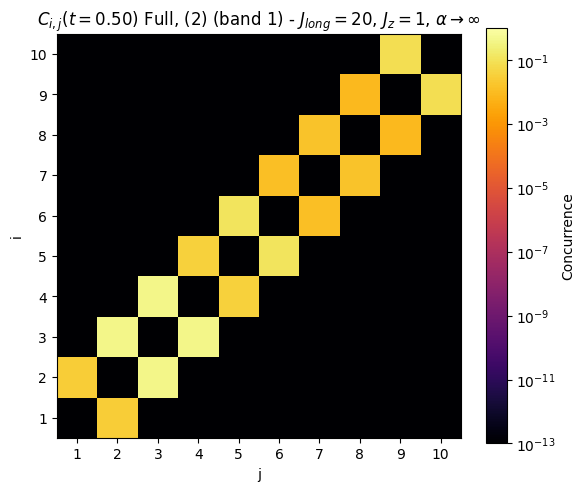

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def load_concurrence_file(fname):
    data = np.loadtxt(fname)

    out = []
    for row in data:
        t = row[0]
        p = int(row[1])
        j = int(row[2])

        rho_vals = row[4:]
        rho = rho_vals.reshape(4,4,2)
        rho = rho[:,:,0] + 1j*rho[:,:,1]

        out.append((t, p, j, rho))

    return out

def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    Y = np.kron(sy, sy)

    R = rho @ (Y @ rho.conj() @ Y)
    evals = np.real(np.linalg.eigvals(R))
    evals = np.maximum(evals, 0.0)
    evals = np.sort(np.sqrt(evals))[::-1]

    return max(0.0, evals[0] - evals[1] - evals[2] - evals[3])

def concurrence_matrix(data, t_target, ns, tol=1e-12):
    C = np.zeros((ns, ns))

    for t, p, j, rho in data:
        if abs(t - t_target) > tol:
            continue

        c = concurrence(rho)
        C[p, j] = c
        # C[j, p] = c   # symmetry

    return C

ns = 10
t0 = 0.5
base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\CYPRESS\Concurrence\Ran\ConcurrenceTest"
fname = f"{base}75Concurrence.txt"
data = load_concurrence_file(fname)

C = concurrence_matrix(data, t0, ns)

# --------------------------------------------------
# PLOT
# --------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# --- threshold ---
vmin = 1e-13

# Copy & mask
C_plot = C.copy()
C_plot[C_plot < vmin] = vmin  # everything below threshold → underflow

# Colormap
cmap = plt.cm.inferno.copy()
cmap.set_under("black")          # 👈 hard black below vmin

plt.figure(figsize=(6,5))

im = plt.imshow(
    C_plot,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=1),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

plt.colorbar(im, label="Concurrence")

# Ticks at lattice sites
ticks = np.arange(1, ns+1, 1)
plt.xticks(ticks)
plt.yticks(ticks)

plt.xlabel("j")
plt.ylabel("i")
plt.title(rf"$C_{{i,j}}(t={t0:.2f})$ Full, (2) (band 1) - $J_{{long}}=20$, $J_z=1$, $\alpha\to\infty$")
plt.savefig(f"plt/ConcurrenceMatrix_FullH_{config}.pdf", dpi=600)
plt.tight_layout()
plt.show()

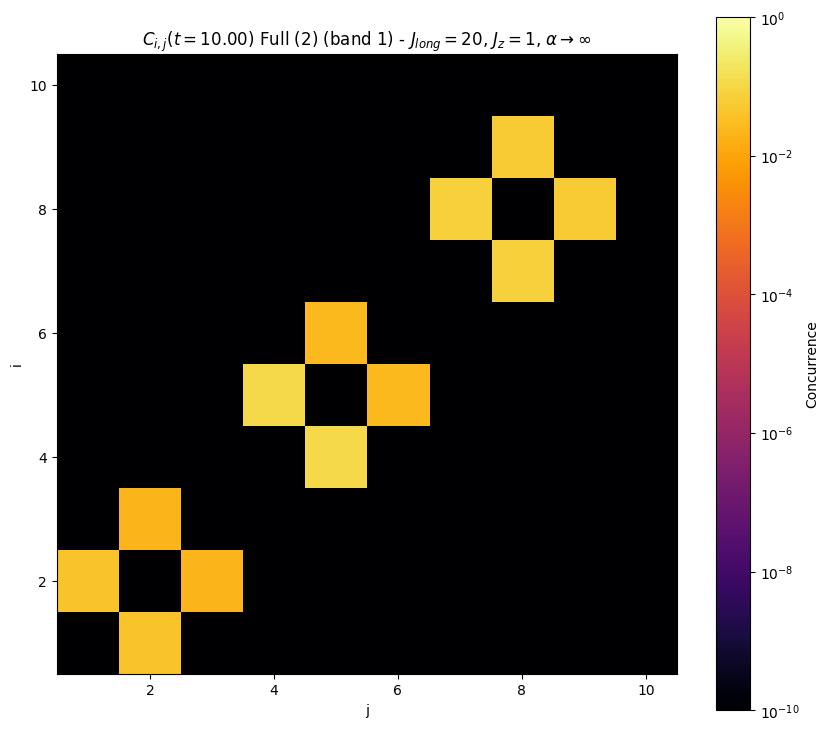

In [5]:
from collections import defaultdict

def group_by_time(data, tol=1e-12):
    times = sorted(set(t for t, _, _, _ in data))
    grouped = defaultdict(list)
    for t, p, j, rho in data:
        grouped[t].append((p, j, rho))
    return times, grouped

times, data_by_time = group_by_time(data)

times = [t for t in times if 0.0 <= t <= 10.0]

import matplotlib.animation as animation

vmin = 1e-10
vmax = 1.0   # keep fixed for ALL frames

fig, ax = plt.subplots(figsize=(10,9))

# initialize empty matrix
C0 = np.full((ns, ns), np.nan)

cmap = plt.cm.inferno.copy()
cmap.set_under("black")

im = ax.imshow(
    C0,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Concurrence")

ticks = np.arange(2, ns+1, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel("j")
ax.set_ylabel("i")

title = ax.set_title("")

# --------------------------------------------------
# Frame update function
# --------------------------------------------------
def update(frame):
    t = times[frame]
    C = np.zeros((ns, ns))

    for p, j, rho in data_by_time[t]:
        C[p, j] = concurrence(rho)

    C[C < vmin] = vmin   # force underflow → black
    im.set_data(C)
    title.set_text(rf"$C_{{i,j}}(t={t:.2f})$ Full (2) (band 1) - $J_{{long}}=20$, $J_z=1$, $\alpha\to\infty$")
    return im,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=60,   # ms between frames
    blit=True
)

from matplotlib.animation import PillowWriter
ani.save("concurrence_matrix15.gif", writer=PillowWriter(fps=15))

# Full Ham, N=15, Concurrence

In [1]:
print("Done")

Done


C:\Users\shrey\AppData\Local\Temp\ipykernel_22932\2491843658.py:87: ConversionWarning: Some errors were detected !
    Line #107 (got 15 columns instead of 17)
  dataCorr = np.genfromtxt(fnameCorr, filling_values=np.nan, invalid_raise=False)


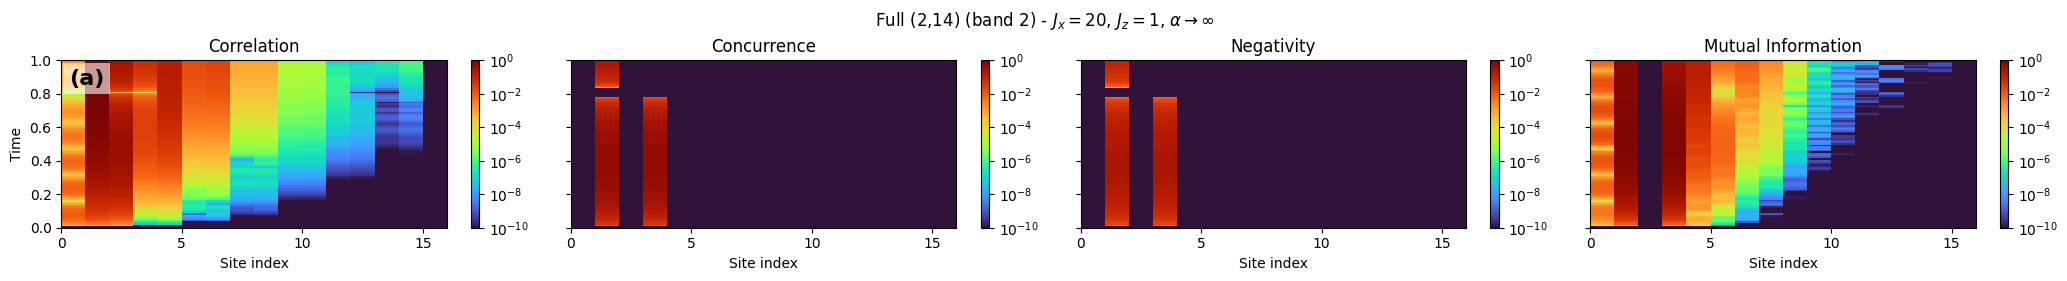

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    return max(0, evals[0] - evals[1] - evals[2] - evals[3])

# --------------------------------------------------
# Negativity computation
# --------------------------------------------------
def negativity(rho):
    # original indices: (iA, iB, jA, jB)
    #(0,1,2,3)
    rho_pt = rho.reshape(2,2,2,2).transpose(0,3,2,1).reshape(4,4)
    # indices: (iA, jB, jA, iB)
    #(0,3,2,1)
    # evals = np.linalg.eigvals(rho_pt)
    # return np.sum(np.abs(evals[evals < 0]))
    evals = np.linalg.eigvalsh(rho_pt)  # Hermitian solver
    return -np.sum(evals[evals < 0])


# --------------------------------------------------
# Von Neumann entropy
# --------------------------------------------------
def von_neumann_entropy(rho, eps=1e-12):
    evals = np.linalg.eigvalsh(rho)
    evals = np.clip(evals, eps, None)
    return -np.sum(evals * np.log2(evals))

# --------------------------------------------------
# Mutual information
# --------------------------------------------------
def mutual_information(rho):
    rho = rho / np.trace(rho)
    rhoA = np.trace(rho.reshape(2,2,2,2), axis1=1, axis2=3)
    rhoB = np.trace(rho.reshape(2,2,2,2), axis1=0, axis2=2)
    return (
        von_neumann_entropy(rhoA)
        + von_neumann_entropy(rhoB)
        - von_neumann_entropy(rho)
    )

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
configsArray = [21000]#,31

t_max_plot = 1

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\CYPRESS\Concurrence\Ran\Concurrence"

# panel letters: (a), (b), (c), ...
panel_letters = [f"({chr(97+i)})" for i in range(len(configsArray))]

for idx, config in enumerate(configsArray):

    ns = 16
    p_target = 2
    # if config == 30:
    #     p_target = 7
    # else:
    #     p_target = 1
    fnameC    = f"{base}{config}Concurrence.txt"
    fnameCorr = f"{base}{config}CorrelationFunction.txt"

    dataC    = np.loadtxt(fnameC)

    # --- load correlation file safely ---
    dataCorr = np.genfromtxt(fnameCorr, filling_values=np.nan, invalid_raise=False)
    dataCorr = dataCorr[~np.isnan(dataCorr).any(axis=1)]


    # --------------------------------------------------
    # Correlation data
    # --------------------------------------------------
    times_corr = dataCorr[:,0]
    CorrMat = np.abs(dataCorr[:,1:ns+1])

    # --------------------------------------------------
    # Time axis (MASTER)
    # --------------------------------------------------
    uniq_times = np.unique(dataC[:,0])
    time_mask  = uniq_times <= t_max_plot
    plot_times = uniq_times[time_mask]
    t_min, t_max = plot_times.min(), plot_times.max()

    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    # --------------------------------------------------
    # Allocate matrices
    # --------------------------------------------------
    Cmat  = np.zeros((len(uniq_times), ns))
    Nmat  = np.zeros((len(uniq_times), ns))
    MImat = np.zeros((len(uniq_times), ns))

    # --------------------------------------------------
    # Fill matrices
    # --------------------------------------------------
    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)

        Cmat[k, j]  = concurrence(rho)
        Nmat[k, j]  = negativity(rho)
        MImat[k, j] = mutual_information(rho)

    # --------------------------------------------------
    # Apply SAME time cut to ALL matrices
    # --------------------------------------------------
    Cmat  = Cmat[time_mask, :]
    Nmat  = Nmat[time_mask, :]
    MImat = MImat[time_mask, :]

    corr_mask = times_corr <= t_max_plot
    CorrMat   = CorrMat[corr_mask, :]

    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------
    fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)
    extent = [0, ns, t_min, t_max]

    im1 = ax[0].imshow(np.clip(CorrMat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo", interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im2 = ax[1].imshow(np.clip(Cmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im3 = ax[2].imshow(np.clip(Nmat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    im4 = ax[3].imshow(np.clip(MImat,1e-10,None), origin="lower",
                       aspect="auto", cmap="turbo",interpolation="nearest",
                       norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
                       extent=extent)

    x_ticks = np.arange(0, ns + 1, 5)

    for a in ax:
        a.set_xticks(x_ticks)
        a.set_xticklabels([f"{int(x)}" for x in x_ticks])

    ax[0].set_title("Correlation")
    ax[1].set_title("Concurrence")
    ax[2].set_title("Negativity")
    ax[3].set_title("Mutual Information")

    ax[0].set_ylabel("Time")
    for a in ax:
        a.set_xlabel("Site index")

    # --------------------------------------------------
    # SINGLE panel letter for the entire row
    # --------------------------------------------------
    ax[0].text(
        0.02, 0.95, panel_letters[idx],   # 👈 INSIDE the plot
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )


    for im, a in zip([im1, im2, im3, im4], ax):
        plt.colorbar(im, ax=a)

    # --------------------------------------------------
    # Suptitles (unchanged)
    # --------------------------------------------------
    plt.suptitle(r"Full (2,14) (band 2) - $J_{x}=20$, $J_z=1$, $\alpha\to\infty$", y=0.92)

    plt.tight_layout()
    plt.savefig(f"plt/Concurrence_Config{config}.pdf", dpi=600)
    plt.show()


In [8]:
np.shape(Ci14)

(129, 16)

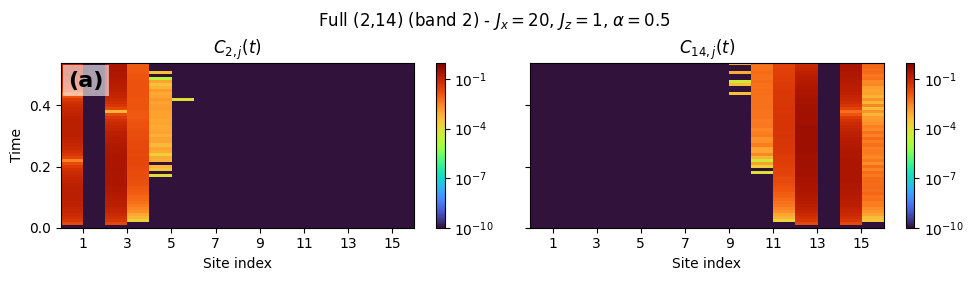

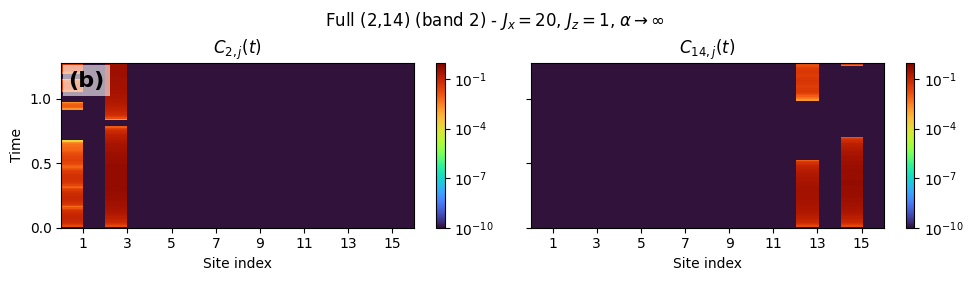

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4, 4, 2)
    return rho_vals[:, :, 0] + 1j * rho_vals[:, :, 1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    return max(0.0, evals[0] - evals[1] - evals[2] - evals[3])

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
configsArray = [5, 21000]
t_max_plot = 10

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\CYPRESS\Concurrence\Ran\Concurrence"

panel_letters = [f"({chr(97+i)})" for i in range(len(configsArray))]

for idx, config in enumerate(configsArray):

    ns = 16

    fnameC = f"{base}{config}Concurrence.txt"
    dataC = np.loadtxt(fnameC)

    # --------------------------------------------------
    # Time axis (MASTER)
    # --------------------------------------------------
    uniq_times = np.unique(dataC[:, 0])
    time_mask  = uniq_times <= t_max_plot
    plot_times = uniq_times[time_mask]
    t_min, t_max = plot_times.min(), plot_times.max()

    time_to_row = {t: i for i, t in enumerate(uniq_times)}

    # --------------------------------------------------
    # Allocate matrices
    # --------------------------------------------------
    C2j  = np.zeros((len(uniq_times), ns))  # p=2, j varies
    Ci14 = np.zeros((len(uniq_times), ns))  # p varies, j=14 (i,14)

    # --------------------------------------------------
    # Fill C_{2,j}(t): p_target = 2
    # --------------------------------------------------
    p_target = 1
    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue
        if not (0 <= j < ns):
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)
        C2j[k, j] = concurrence(rho)

    # --------------------------------------------------
    # Fill C_{i,14}(t): set p_target = 14, and let "site index" be p
    # (i.e., x-axis is i = p, and we fix the other site to 14 by selecting j=14)
    # --------------------------------------------------
    p_target = 13
    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue
        if not (0 <= j < ns):
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)
        Ci14[k, j] = concurrence(rho)

    # --------------------------------------------------
    # Apply SAME time cut
    # --------------------------------------------------
    C2j  = C2j[time_mask, :]
    Ci14 = Ci14[time_mask, :]

    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------
    fig, ax = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
    extent = [0, ns, t_min, t_max]

    im_left = ax[0].imshow(
        np.clip(C2j, 1e-10, None),
        origin="lower",
        aspect="auto",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
        extent=extent,
    )

    im_right = ax[1].imshow(
        np.clip(Ci14, 1e-10, None),
        origin="lower",
        aspect="auto",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
        extent=extent,
    )

    x_ticks = np.arange(1, ns + 1, 2)
    for a in ax:
        a.set_xticks(x_ticks)
        a.set_xticklabels([f"{int(x)}" for x in x_ticks])
        a.set_xlabel("Site index")

    ax[0].set_ylabel("Time")
    ax[0].set_title(r"$C_{2,j}(t)$")
    ax[1].set_title(r"$C_{14,j}(t)$")  # this matches what you're actually plotting now

    # panel letter
    ax[0].text(
        0.02, 0.95, panel_letters[idx],
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.colorbar(im_left, ax=ax[0])
    plt.colorbar(im_right, ax=ax[1])

    # --------------------------------------------------
    # Suptitle
    # --------------------------------------------------
    if config == 5:
        plt.suptitle(r"Full (2,14) (band 2) - $J_{x}=20$, $J_z=1$, $\alpha=0.5$", y=0.92)
    else:
        plt.suptitle(r"Full (2,14) (band 2) - $J_{x}=20$, $J_z=1$, $\alpha\to\infty$", y=0.92)

    plt.tight_layout()
    plt.savefig(f"plt/Concurrence_Config{config}.pdf", dpi=600)
    plt.show()


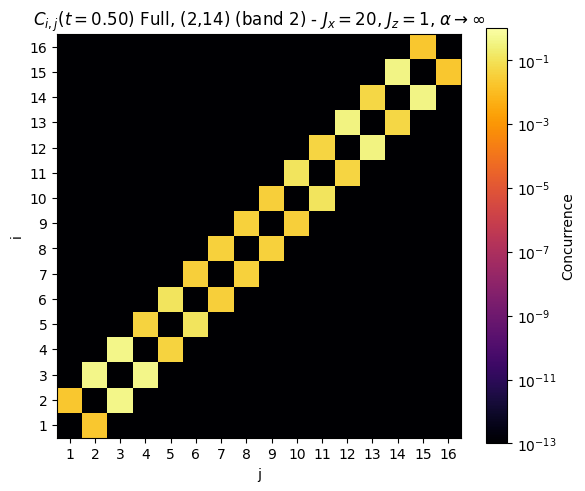

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def load_concurrence_file(fname):
    data = np.loadtxt(fname)

    out = []
    for row in data:
        t = row[0]
        p = int(row[1])
        j = int(row[2])

        rho_vals = row[4:]
        rho = rho_vals.reshape(4,4,2)
        rho = rho[:,:,0] + 1j*rho[:,:,1]

        out.append((t, p, j, rho))

    return out

def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    Y = np.kron(sy, sy)

    R = rho @ (Y @ rho.conj() @ Y)
    evals = np.real(np.linalg.eigvals(R))
    evals = np.maximum(evals, 0.0)
    evals = np.sort(np.sqrt(evals))[::-1]

    return max(0.0, evals[0] - evals[1] - evals[2] - evals[3])

def concurrence_matrix(data, t_target, ns, tol=1e-12):
    C = np.zeros((ns, ns))

    for t, p, j, rho in data:
        if abs(t - t_target) > tol:
            continue

        c = concurrence(rho)
        C[p, j] = c
        # C[j, p] = c   # symmetry

    return C

ns = 16
t0 = 0.5
base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\CYPRESS\Concurrence\Ran\Concurrence"
fname = f"{base}21000Concurrence.txt"
data = load_concurrence_file(fname)

C = concurrence_matrix(data, t0, ns)

# --------------------------------------------------
# PLOT
# --------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# --- threshold ---
vmin = 1e-13

# Copy & mask
C_plot = C.copy()
C_plot[C_plot < vmin] = vmin  # everything below threshold → underflow

# Colormap
cmap = plt.cm.inferno.copy()
cmap.set_under("black")          # 👈 hard black below vmin

plt.figure(figsize=(6,5))

im = plt.imshow(
    C_plot,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=1),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

plt.colorbar(im, label="Concurrence")

# Ticks at lattice sites
ticks = np.arange(1, ns+1, 1)
plt.xticks(ticks)
plt.yticks(ticks)

plt.xlabel("j")
plt.ylabel("i")
plt.title(rf"$C_{{i,j}}(t={t0:.2f})$ Full, (2,14) (band 2) - $J_{{x}}=20$, $J_z=1$, $\alpha\to\infty$")
plt.savefig(f"plt/ConcurrenceMatrix_FullH_{config}.pdf", dpi=600)
plt.tight_layout()
plt.show()

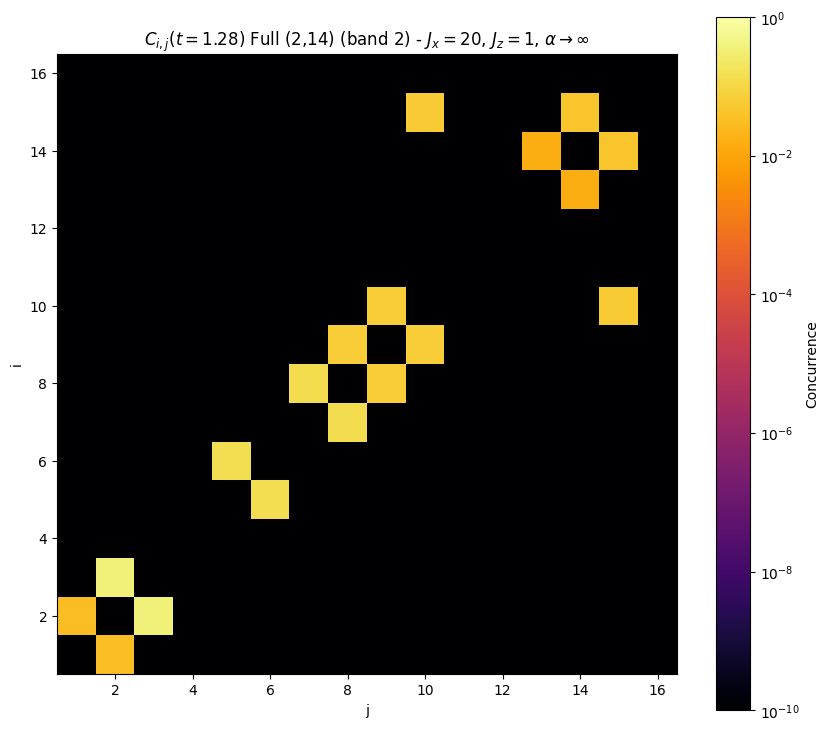

In [4]:
from collections import defaultdict

def group_by_time(data, tol=1e-12):
    times = sorted(set(t for t, _, _, _ in data))
    grouped = defaultdict(list)
    for t, p, j, rho in data:
        grouped[t].append((p, j, rho))
    return times, grouped

times, data_by_time = group_by_time(data)

times = [t for t in times if 0.0 <= t <= 10.0]

import matplotlib.animation as animation

vmin = 1e-10
vmax = 1.0   # keep fixed for ALL frames

fig, ax = plt.subplots(figsize=(10,9))

# initialize empty matrix
C0 = np.full((ns, ns), np.nan)

cmap = plt.cm.inferno.copy()
cmap.set_under("black")

im = ax.imshow(
    C0,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Concurrence")

ticks = np.arange(2, ns+1, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel("j")
ax.set_ylabel("i")

title = ax.set_title("")

# --------------------------------------------------
# Frame update function
# --------------------------------------------------
def update(frame):
    t = times[frame]
    C = np.zeros((ns, ns))

    for p, j, rho in data_by_time[t]:
        C[p, j] = concurrence(rho)

    C[C < vmin] = vmin   # force underflow → black
    im.set_data(C)
    title.set_text(rf"$C_{{i,j}}(t={t:.2f})$ Full (2,14) (band 2) - $J_{{x}}=20$, $J_z=1$, $\alpha\to\infty$")
    return im,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=60,   # ms between frames
    blit=True
)

from matplotlib.animation import PillowWriter
ani.save("concurrence_matrix16.gif", writer=PillowWriter(fps=15))

NameError: name 'config' is not defined

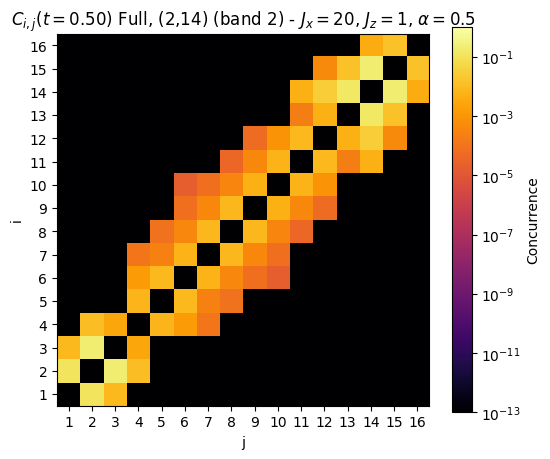

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def load_concurrence_file(fname):
    data = np.loadtxt(fname)

    out = []
    for row in data:
        t = row[0]
        p = int(row[1])
        j = int(row[2])

        rho_vals = row[4:]
        rho = rho_vals.reshape(4,4,2)
        rho = rho[:,:,0] + 1j*rho[:,:,1]

        out.append((t, p, j, rho))

    return out

def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    Y = np.kron(sy, sy)

    R = rho @ (Y @ rho.conj() @ Y)
    evals = np.real(np.linalg.eigvals(R))
    evals = np.maximum(evals, 0.0)
    evals = np.sort(np.sqrt(evals))[::-1]

    return max(0.0, evals[0] - evals[1] - evals[2] - evals[3])

def concurrence_matrix(data, t_target, ns, tol=1e-12):
    C = np.zeros((ns, ns))

    for t, p, j, rho in data:
        if abs(t - t_target) > tol:
            continue

        c = concurrence(rho)
        C[p, j] = c
        # C[j, p] = c   # symmetry

    return C

ns = 16
t0 = 0.5
base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\CYPRESS\Concurrence\Ran\Concurrence"
fname = f"{base}5Concurrence.txt"
data = load_concurrence_file(fname)

C = concurrence_matrix(data, t0, ns)

# --------------------------------------------------
# PLOT
# --------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# --- threshold ---
vmin = 1e-13

# Copy & mask
C_plot = C.copy()
C_plot[C_plot < vmin] = vmin  # everything below threshold → underflow

# Colormap
cmap = plt.cm.inferno.copy()
cmap.set_under("black")          # 👈 hard black below vmin

plt.figure(figsize=(6,5))

im = plt.imshow(
    C_plot,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=1),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

plt.colorbar(im, label="Concurrence")

# Ticks at lattice sites
ticks = np.arange(1, ns+1, 1)
plt.xticks(ticks)
plt.yticks(ticks)

plt.xlabel("j")
plt.ylabel("i")
plt.title(rf"$C_{{i,j}}(t={t0:.2f})$ Full, (2,14) (band 2) - $J_{{x}}=20$, $J_z=1$, $\alpha=0.5$")
plt.savefig(f"plt/ConcurrenceMatrix_FullH2_{config}.pdf", dpi=600)
plt.tight_layout()
plt.show()

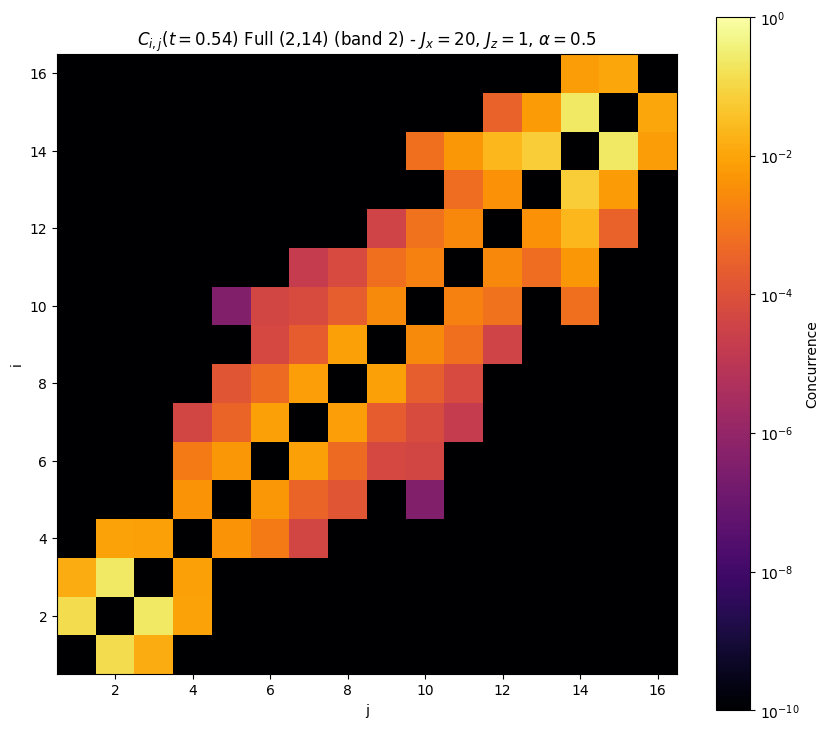

In [53]:
from collections import defaultdict

def group_by_time(data, tol=1e-12):
    times = sorted(set(t for t, _, _, _ in data))
    grouped = defaultdict(list)
    for t, p, j, rho in data:
        grouped[t].append((p, j, rho))
    return times, grouped

times, data_by_time = group_by_time(data)

times = [t for t in times if 0.0 <= t <= 10.0]

import matplotlib.animation as animation

vmin = 1e-10
vmax = 1.0   # keep fixed for ALL frames

fig, ax = plt.subplots(figsize=(10,9))

# initialize empty matrix
C0 = np.full((ns, ns), np.nan)

cmap = plt.cm.inferno.copy()
cmap.set_under("black")

im = ax.imshow(
    C0,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Concurrence")

ticks = np.arange(2, ns+1, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel("j")
ax.set_ylabel("i")

title = ax.set_title("")

# --------------------------------------------------
# Frame update function
# --------------------------------------------------
def update(frame):
    t = times[frame]
    C = np.zeros((ns, ns))

    for p, j, rho in data_by_time[t]:
        C[p, j] = concurrence(rho)

    C[C < vmin] = vmin   # force underflow → black
    im.set_data(C)
    title.set_text(rf"$C_{{i,j}}(t={t:.2f})$ Full (2,14) (band 2) - $J_{{x}}=20$, $J_z=1$, $\alpha=0.5$")
    return im,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=60,   # ms between frames
    blit=True
)

from matplotlib.animation import PillowWriter
ani.save("concurrence_matrix17.gif", writer=PillowWriter(fps=15))

## Concurrence of (2,12;3,12) vs (2;3)

In [1]:
print("Done")

Done


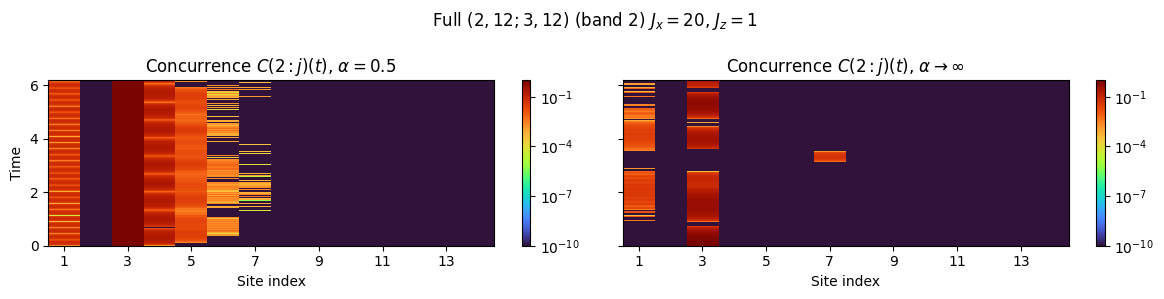

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4, 4, 2)
    return rho_vals[:, :, 0] + 1j * rho_vals[:, :, 1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    return max(0.0, evals[0] - evals[1] - evals[2] - evals[3])

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
ns = 14
t_max_plot = 10

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\CYPRESS\Concurrence\Ran\ConcurrenceN14b1"

configs = [5, 1000]  # 5 -> alpha=0.5, 1000 -> alpha -> infinity
titles  = [
    r"Concurrence $ C(2:j)(t)$, $\alpha=0.5$",
    r"Concurrence $ C(2:j)(t)$, $\alpha\to\infty$"
]

# If your file indices are 0-based, site 2 corresponds to p=1.
p_target = 1  # site 2

# --------------------------------------------------
# Load both datasets, build C2j for each
# --------------------------------------------------
C2j_list = []
plot_times = None
t_min = t_max = None

for config in configs:
    fnameC = f"{base}{config}Concurrence.txt"
    dataC = np.loadtxt(fnameC)

    uniq_times = np.unique(dataC[:, 0])
    time_mask  = uniq_times <= t_max_plot
    pt         = uniq_times[time_mask]

    # Use the first config to define the plotting time grid
    if plot_times is None:
        plot_times = pt
        t_min, t_max = plot_times.min(), plot_times.max()

    # map time -> row index in uniq_times
    time_to_row = {t: i for i, t in enumerate(uniq_times)}

    C2j = np.zeros((len(uniq_times), ns))

    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue
        if not (0 <= j < ns):
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)
        C2j[k, j] = concurrence(rho)

    # apply same time cut
    C2j = C2j[time_mask, :]

    # optional: also force same number of time points as first panel
    # (in case files differ slightly)
    C2j = C2j[:len(plot_times), :]

    C2j_list.append(C2j)

# --------------------------------------------------
# PLOT: left alpha=0.5, right alpha=infty, SAME observable C2,j
# --------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 3), sharey=True)

# nice x-axis that corresponds to site labels 1..ns
extent = [0.5, ns + 0.5, t_min, t_max]

for a, C2j, ttl in zip(ax, C2j_list, titles):
    im = a.imshow(
        np.clip(C2j, 1e-10, None),
        origin="lower",
        aspect="auto",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
        extent=extent,
    )
    a.set_title(ttl)
    a.set_xlabel("Site index")
    plt.colorbar(im, ax=a)

ax[0].set_ylabel("Time")

x_ticks = np.arange(1, ns + 1, 2)
for a in ax:
    a.set_xticks(x_ticks)

plt.suptitle(r"Full $(2,12;3,12)$ (band 2) $J_x=20$, $J_z=1$", y=0.98)
plt.savefig(f"plt/Concurrence_C2j_Comparison1.svg", dpi=600)
plt.tight_layout()
plt.show()


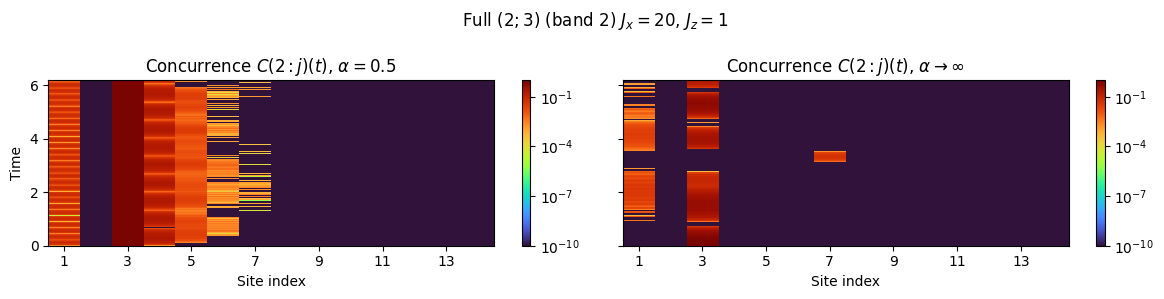

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4, 4, 2)
    return rho_vals[:, :, 0] + 1j * rho_vals[:, :, 1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    return max(0.0, evals[0] - evals[1] - evals[2] - evals[3])

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
ns = 14
t_max_plot = 10

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\CYPRESS\Concurrence\Ran\ConcurrenceN14b2"

configs = [5, 1000]  # 5 -> alpha=0.5, 1000 -> alpha -> infinity
titles  = [
    r"Concurrence $ C(2:j)(t)$, $\alpha=0.5$",
    r"Concurrence $ C(2:j)(t)$, $\alpha\to\infty$"
]

# If your file indices are 0-based, site 2 corresponds to p=1.
p_target = 1  # site 2

# --------------------------------------------------
# Load both datasets, build C2j for each
# --------------------------------------------------
C2j_list = []
plot_times = None
t_min = t_max = None

for config in configs:
    fnameC = f"{base}{config}Concurrence.txt"
    dataC = np.loadtxt(fnameC)

    uniq_times = np.unique(dataC[:, 0])
    time_mask  = uniq_times <= t_max_plot
    pt         = uniq_times[time_mask]

    # Use the first config to define the plotting time grid
    if plot_times is None:
        plot_times = pt
        t_min, t_max = plot_times.min(), plot_times.max()

    # map time -> row index in uniq_times
    time_to_row = {t: i for i, t in enumerate(uniq_times)}

    C2j = np.zeros((len(uniq_times), ns))

    for row in dataC:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue
        if not (0 <= j < ns):
            continue

        k = time_to_row[t]
        rho = row_to_rho(row)
        C2j[k, j] = concurrence(rho)

    # apply same time cut
    C2j = C2j[time_mask, :]

    # optional: also force same number of time points as first panel
    # (in case files differ slightly)
    C2j = C2j[:len(plot_times), :]

    C2j_list.append(C2j)

# --------------------------------------------------
# PLOT: left alpha=0.5, right alpha=infty, SAME observable C2,j
# --------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 3), sharey=True)

# nice x-axis that corresponds to site labels 1..ns
extent = [0.5, ns + 0.5, t_min, t_max]

for a, C2j, ttl in zip(ax, C2j_list, titles):
    im = a.imshow(
        np.clip(C2j, 1e-10, None),
        origin="lower",
        aspect="auto",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
        extent=extent,
    )
    a.set_title(ttl)
    a.set_xlabel("Site index")
    plt.colorbar(im, ax=a)

ax[0].set_ylabel("Time")

x_ticks = np.arange(1, ns + 1, 2)
for a in ax:
    a.set_xticks(x_ticks)

plt.suptitle(r"Full $(2;3)$ (band 2) $J_x=20$, $J_z=1$", y=0.98)
plt.savefig(f"plt/Concurrence_C2j_Comparison2.svg", dpi=600)
plt.tight_layout()
plt.show()
